# **NOTEBOOK GRUPO 3**
## **Proyecto: Análisis Avanzado de Datos para el sistema judicial de EE. UU.**

#### Dos archivos:

- a) «compas-scores.csv»  
    Archivo que contiene el conjunto completo de datos de los acusados en espera de juicio que ProPublica obtuvo de la Oficina del Sheriff del condado de Broward. Este archivo contiene 11 757 personas.


- b)  «compas-scores-two-years.csv»  
    Creado por ProPublica con el fin de estudiar la reincidencia general en un periodo de dos años. El término «reincidencia general» se utiliza para distinguirlo del subconjunto más reducido de reincidencia violenta. La reincidencia general incluye tanto los delitos violentos como los no violentos. Estos archivos contienen, en teoría, un subconjunto de personas que han sido observadas durante al menos dos años, y etiquetan a las personas que han reincidido en un plazo de dos años con un indicador two_year_recid activado. El archivo de reincidencia general en dos años contiene 7214 personas.



## **DEFINICIÓN DEL NOTEBOOK E IMPORTACIÓN DE FUNCIONES Y DOCUMENTOS**

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!pip install fairlearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 24.7 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import re
import missingno as msno
import os
import scipy.stats as stats
import sys
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from fairlearn.metrics import equalized_odds_difference


In [ ]:
import mis_funciones as funciones

In [ ]:
filepath_raw = "/content/drive/MyDrive/compas-scores-raw.csv"
filepath_twoyears = "/content/drive/MyDrive/raw_files/compas-scores-two-years.csv"

In [ ]:
compas_scores_raw = pd.read_csv(filepath_raw)
compas_scores_two_years = pd.read_csv(filepath_twoyears)

In [ ]:
display(compas_scores_raw.head(3))
display(compas_scores_two_years.head(3))

,Person_ID,AssessmentID,Case_ID,Agency_Text,LastName,FirstName,MiddleName,Sex_Code_Text,Ethnic_Code_Text,DateOfBirth,...,RecSupervisionLevel,RecSupervisionLevelText,Scale_ID,DisplayText,RawScore,DecileScore,ScoreText,AssessmentType,IsCompleted,IsDeleted
0,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,7,Risk of Violence,-2.08,4,Low,New,1,0
1,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,8,Risk of Recidivism,-1.06,2,Low,New,1,0
2,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,18,Risk of Failure to Appear,15.00,1,Low,New,1,0


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1


## **ANÁLISIS PREVIO**


¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 60,843 filas y 28 columnas.
##########################################################################################
¿Cuáles son las primeras cinco filas del conjunto de datos?


,Person_ID,AssessmentID,Case_ID,Agency_Text,LastName,FirstName,MiddleName,Sex_Code_Text,Ethnic_Code_Text,DateOfBirth,...,RecSupervisionLevel,RecSupervisionLevelText,Scale_ID,DisplayText,RawScore,DecileScore,ScoreText,AssessmentType,IsCompleted,IsDeleted
0,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,7,Risk of Violence,-2.08,4,Low,New,1,0
1,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,8,Risk of Recidivism,-1.06,2,Low,New,1,0
2,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,18,Risk of Failure to Appear,15.00,1,Low,New,1,0
3,50848,57174,51956,PRETRIAL,KENDALL,KEVIN,NaN,Male,Caucasian,09/16/84,...,1,Low,7,Risk of Violence,-2.84,2,Low,New,1,0
4,50848,57174,51956,PRETRIAL,KENDALL,KEVIN,NaN,Male,Caucasian,09/16/84,...,1,Low,8,Risk of Recidivism,-1.50,1,Low,New,1,0


----------------------------------------------------------------------------------------------------
¿Cuáles son las últimas cinco filas del conjunto de datos?


,Person_ID,AssessmentID,Case_ID,Agency_Text,LastName,FirstName,MiddleName,Sex_Code_Text,Ethnic_Code_Text,DateOfBirth,...,RecSupervisionLevel,RecSupervisionLevelText,Scale_ID,DisplayText,RawScore,DecileScore,ScoreText,AssessmentType,IsCompleted,IsDeleted
60838,65667,79665,72038,Probation,West,James,NaN,Male,African-American,06/21/64,...,3,Medium with Override Consideration,8,Risk of Recidivism,0.16,8,High,New,1,0
60839,65667,79665,72038,Probation,West,James,NaN,Male,African-American,06/21/64,...,3,Medium with Override Consideration,18,Risk of Failure to Appear,35.00,10,High,New,1,0
60840,68603,79669,72042,PRETRIAL,Ryan,Michael,NaN,Male,Caucasian,02/06/85,...,1,Low,7,Risk of Violence,-2.75,2,Low,New,1,0
60841,68603,79669,72042,PRETRIAL,Ryan,Michael,NaN,Male,Caucasian,02/06/85,...,1,Low,8,Risk of Recidivism,-0.34,5,Medium,New,1,0
60842,68603,79669,72042,PRETRIAL,Ryan,Michael,NaN,Male,Caucasian,02/06/85,...,1,Low,18,Risk of Failure to Appear,16.00,2,Low,New,1,0


----------------------------------------------------------------------------------------------------
¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


...

----------------------------------------------------------------------------------------------------
¿Cuántos valores nulos hay en cada columna del DataFrame?


,0
Person_ID,0
AssessmentID,0
Case_ID,0
Agency_Text,0
LastName,0
FirstName,0
MiddleName,45219
Sex_Code_Text,0
Ethnic_Code_Text,0
DateOfBirth,0


----------------------------------------------------------------------------------------------------
¿Cuál es el porcentaje de valores nulos por columna, ordenado de mayor a menor?


,Col,pct
0,MiddleName,74.32
1,ScoreText,0.07
2,Case_ID,0.00
3,Person_ID,0.00
4,Agency_Text,0.00
5,LastName,0.00
6,FirstName,0.00
7,Sex_Code_Text,0.00
8,Ethnic_Code_Text,0.00
9,DateOfBirth,0.00


----------------------------------------------------------------------------------------------------
## Valores nulos: Visualización


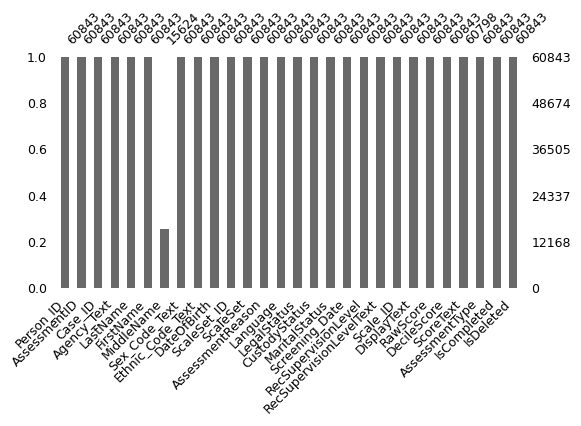

----------------------------------------------------------------------------------------------------
## Visualización de patrones en valores nulos


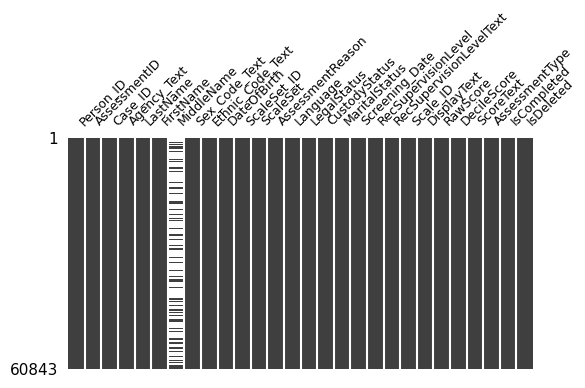

----------------------------------------------------------------------------------------------------


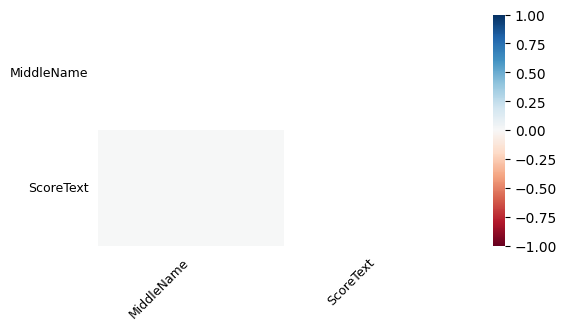

----------------------------------------------------------------------------------------------------
##########################################################################################


In [ ]:
funciones.exploracion_inicial(compas_scores_raw)

¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 7,214 filas y 53 columnas.
##########################################################################################
¿Cuáles son las primeras cinco filas del conjunto de datos?


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


----------------------------------------------------------------------------------------------------
¿Cuáles son las últimas cinco filas del conjunto de datos?


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
7209,10996,steven butler,steven,butler,2013-11-23,Male,1992-07-17,23,Less than 25,African-American,...,5,Medium,2013-11-23,2013-11-22,2013-11-24,0,1,860,0,0
7210,10997,malcolm simmons,malcolm,simmons,2014-02-01,Male,1993-03-25,23,Less than 25,African-American,...,5,Medium,2014-02-01,2014-01-31,2014-02-02,0,1,790,0,0
7211,10999,winston gregory,winston,gregory,2014-01-14,Male,1958-10-01,57,Greater than 45,Other,...,1,Low,2014-01-14,2014-01-13,2014-01-14,0,0,808,0,0
7212,11000,farrah jean,farrah,jean,2014-03-09,Female,1982-11-17,33,25 - 45,African-American,...,2,Low,2014-03-09,2014-03-08,2014-03-09,3,0,754,0,0
7213,11001,florencia sanmartin,florencia,sanmartin,2014-06-30,Female,1992-12-18,23,Less than 25,Hispanic,...,4,Low,2014-06-30,2015-03-15,2015-03-15,2,0,258,0,1


----------------------------------------------------------------------------------------------------
¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


...

----------------------------------------------------------------------------------------------------
¿Cuántos valores nulos hay en cada columna del DataFrame?


,0
id,0
name,0
first,0
last,0
compas_screening_date,0
sex,0
dob,0
age,0
age_cat,0
race,0


----------------------------------------------------------------------------------------------------
¿Cuál es el porcentaje de valores nulos por columna, ordenado de mayor a menor?


,Col,pct
0,violent_recid,100.00
1,vr_charge_degree,88.65
2,vr_offense_date,88.65
3,vr_case_number,88.65
4,vr_charge_desc,88.65
5,c_arrest_date,84.24
6,r_jail_in,67.90
7,r_days_from_arrest,67.90
8,r_jail_out,67.90
9,r_charge_desc,52.69


----------------------------------------------------------------------------------------------------
## Valores nulos: Visualización


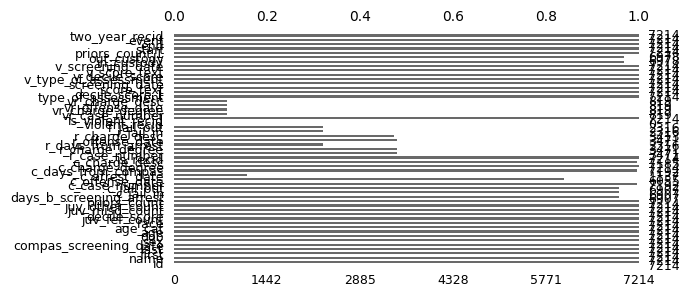

----------------------------------------------------------------------------------------------------
## Visualización de patrones en valores nulos


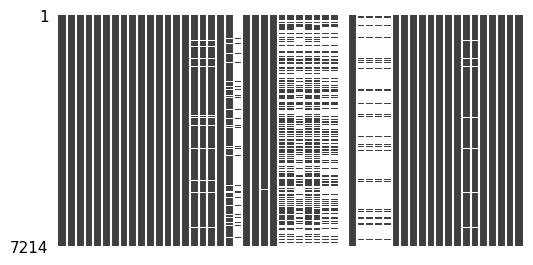

----------------------------------------------------------------------------------------------------


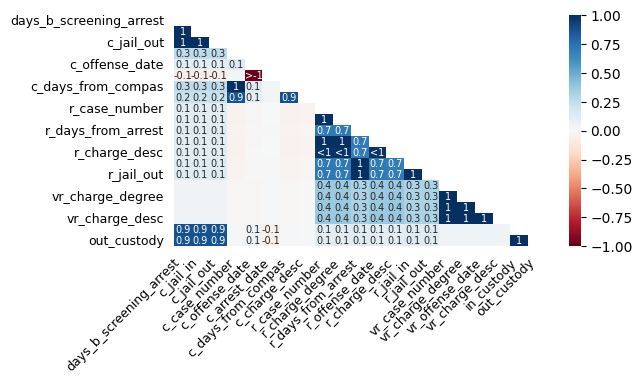

----------------------------------------------------------------------------------------------------
##########################################################################################


In [ ]:
funciones.exploracion_inicial(compas_scores_two_years)

## **LIMPIEZA DE DATOS**


1. Convertimos las columnas de fecha, que vimos en el análisis previo son todas "object".  
1.1. Primero de compas_scores_two_years

In [ ]:
dates = ['dob','compas_screening_date',
 'c_offense_date',
 'c_arrest_date',
 'r_offense_date',
 'r_jail_in',
 'r_jail_out',
 'vr_offense_date',
 'screening_date',
 'v_screening_date',
 'in_custody',
 'out_custody']

datetimes =  ['c_jail_in',
 'c_jail_out']

In [ ]:
display(compas_scores_two_years[dates])
display(compas_scores_two_years[datetimes])

,dob,compas_screening_date,c_offense_date,c_arrest_date,r_offense_date,r_jail_in,r_jail_out,vr_offense_date,screening_date,v_screening_date,in_custody,out_custody
0,1947-04-18,2013-08-14,2013-08-13,NaN,NaN,NaN,NaN,NaN,2013-08-14,2013-08-14,2014-07-07,2014-07-14
1,1982-01-22,2013-01-27,2013-01-26,NaN,2013-07-05,NaN,NaN,2013-07-05,2013-01-27,2013-01-27,2013-01-26,2013-02-05
2,1991-05-14,2013-04-14,2013-04-13,NaN,2013-06-16,2013-06-16,2013-06-16,NaN,2013-04-14,2013-04-14,2013-06-16,2013-06-16
3,1993-01-21,2013-01-13,2013-01-12,NaN,NaN,NaN,NaN,NaN,2013-01-13,2013-01-13,NaN,NaN
4,1973-01-22,2013-03-26,NaN,2013-01-09,NaN,NaN,NaN,NaN,2013-03-26,2013-03-26,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
7209,1992-07-17,2013-11-23,2013-11-22,NaN,NaN,NaN,NaN,NaN,2013-11-23,2013-11-23,2013-11-22,2013-11-24
7210,1993-03-25,2014-02-01,2014-01-31,NaN,NaN,NaN,NaN,NaN,2014-02-01,2014-02-01,2014-01-31,2014-02-02
7211,1958-10-01,2014-01-14,2014-01-13,NaN,NaN,NaN,NaN,NaN,2014-01-14,2014-01-14,2014-01-13,2014-01-14
7212,1982-11-17,2014-03-09,2014-03-08,NaN,NaN,NaN,NaN,NaN,2014-03-09,2014-03-09,2014-03-08,2014-03-09


,c_jail_in,c_jail_out
0,2013-08-13 06:03:42,2013-08-14 05:41:20
1,2013-01-26 03:45:27,2013-02-05 05:36:53
2,2013-04-13 04:58:34,2013-04-14 07:02:04
3,NaN,NaN
4,NaN,NaN
...,...,...
7209,2013-11-22 05:18:27,2013-11-24 02:59:20
7210,2014-01-31 07:13:54,2014-02-02 04:03:52
7211,2014-01-13 05:48:01,2014-01-14 07:49:46
7212,2014-03-08 08:06:02,2014-03-09 12:18:04


In [ ]:
compas_scores_two_years[dates] = compas_scores_two_years[dates].apply(pd.to_datetime, errors="coerce", format="%Y-%m-%d")
compas_scores_two_years[datetimes] = compas_scores_two_years[datetimes].apply(pd.to_datetime, errors="coerce", format="%Y-%m-%d %H:%M:%S")

In [ ]:
display(compas_scores_two_years[dates].dtypes)
display(compas_scores_two_years[datetimes].dtypes)

,0
dob,datetime64[ns]
compas_screening_date,datetime64[ns]
c_offense_date,datetime64[ns]
c_arrest_date,datetime64[ns]
r_offense_date,datetime64[ns]
r_jail_in,datetime64[ns]
r_jail_out,datetime64[ns]
vr_offense_date,datetime64[ns]
screening_date,datetime64[ns]
v_screening_date,datetime64[ns]


,0
c_jail_in,datetime64[ns]
c_jail_out,datetime64[ns]


1.2. Ahora de compas_scores_raw

In [ ]:
compas_scores_raw["DateOfBirth"] = pd.to_datetime(compas_scores_raw["DateOfBirth"],format="%m/%d/%y")
compas_scores_raw["Screening_Date"] = pd.to_datetime(compas_scores_raw["Screening_Date"],format="%m/%d/%y %H:%M")

In [ ]:
display(compas_scores_raw["DateOfBirth"].head(2))
display(compas_scores_raw["Screening_Date"].head(2))

,DateOfBirth
0,1992-12-05
1,1992-12-05


,Screening_Date
0,2013-01-01
1,2013-01-01


#### **Limpieza de columnas duplicadas de decile_score y prior_count en compas_scores_two_years**  
Al parecer, las columnas `decile_score.1` y `priors_count.1` son duplicados exactos de `decile_score` y `priors_count` respectivamente, lo cual procedemos a verificar.

In [ ]:
print("Son los valores para las columnas 'priors_count' y 'priors_count.1' igual en ambas columnas:?", (compas_scores_two_years['priors_count'] == compas_scores_two_years['priors_count.1']).all())
print("Son los valores para las columnas 'decile_score' y 'decile_score.1' igual en ambas columnas:?", (compas_scores_two_years['decile_score'] == compas_scores_two_years['decile_score.1']).all())


Son los valores para las columnas 'priors_count' y 'priors_count.1' igual en ambas columnas:? True
Son los valores para las columnas 'decile_score' y 'decile_score.1' igual en ambas columnas:? True


In [ ]:
compas_scores_two_years = compas_scores_two_years.drop(columns=['decile_score.1', 'priors_count.1'])

Al ser redundantes, se elimina el duplicado de cada una para evitar ambigüedad en el análisis y mantener el dataset limpio.


#### **Verificación de la caída de screening dates en 2013**  
Revisamos las fechas y vimos que la variable compas_screening_date en compas-scores-two-years.csv tiene una caída en julio de 2013.

La comparamos con Screening_Date en el archivo compas_scores_raw.

La disminución de casos en julio de 2013 aparece en ambos datasets.
Esto confirma que el fenómeno proviene de los datos originales del condado, no del procesamiento de ProPublica.
Como viene del origen de lo datos, no tenemos forma de corregirlo. Es un error de fuente, así que asumiremos esta caída como algo que puede esperarse.


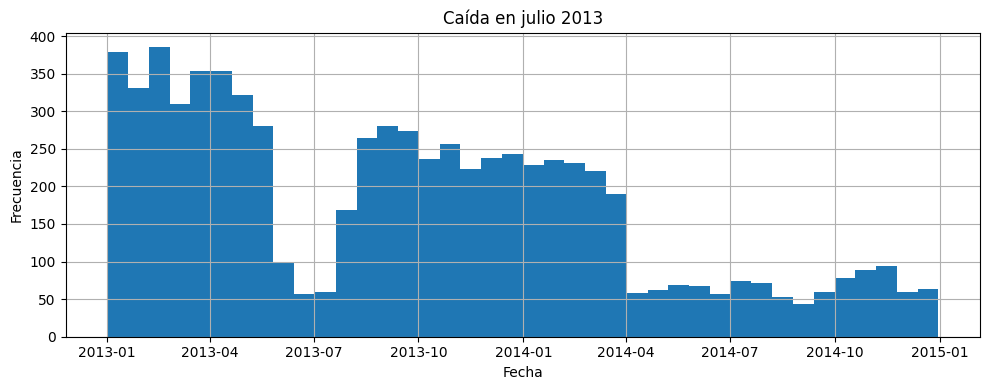

In [ ]:
# Primero compas_scores_two_years
compas_scores_two_years['compas_screening_date'].hist(bins=40, figsize=(10,4))

plt.xlabel("Fecha")
plt.ylabel("Frecuencia")
plt.title("Caída en julio 2013")
plt.tight_layout()
plt.show()

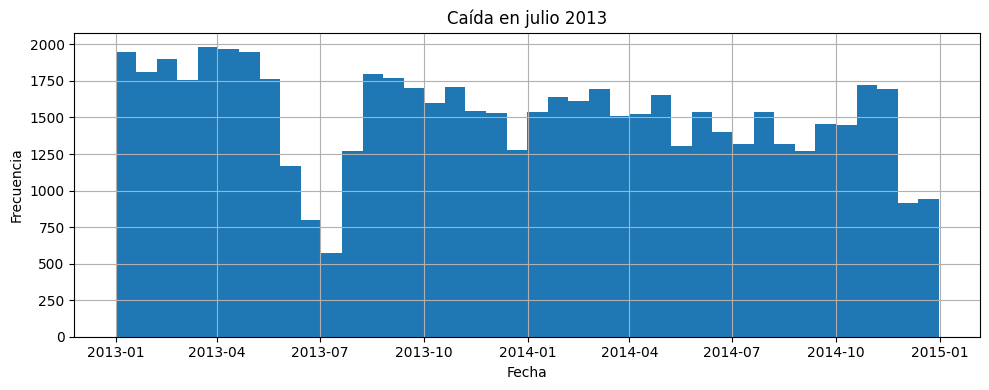

In [ ]:
# Ahora con compas_scores_raw
compas_scores_raw['Screening_Date'].hist(bins=40, figsize=(10,4))

plt.xlabel("Fecha")
plt.ylabel("Frecuencia")
plt.title("Caída en julio 2013")
plt.tight_layout()
plt.show()

### Corrección del cutoff de dos años
En los datos de "compas_scores_two_years", se intenta recopilar el nivel de reincidencia de cada persona dentro de los dos años posteriores a su evaluación COMPAS. Por ello, debido a que el dataset se recopiló con datos de arrestos hasta el 1 de abril de 2016, se deben quitar los datos con screening date posterior al 1 de abril de 2014 (de lo contrario,
no tienen dos años completos de observación disponibles.)

El problema metodológico principal identificado en el dataset de "compas_scores_two_years" de ProPublica es que:
- eliminó a los no recidivistas con compas_screening_date posterior al 1 de abril de 2014,  
- pero mantuvieron recidivistas con screening dates posteriores a esa fecha, inflando artificialmente la tasa de recidivismo.  




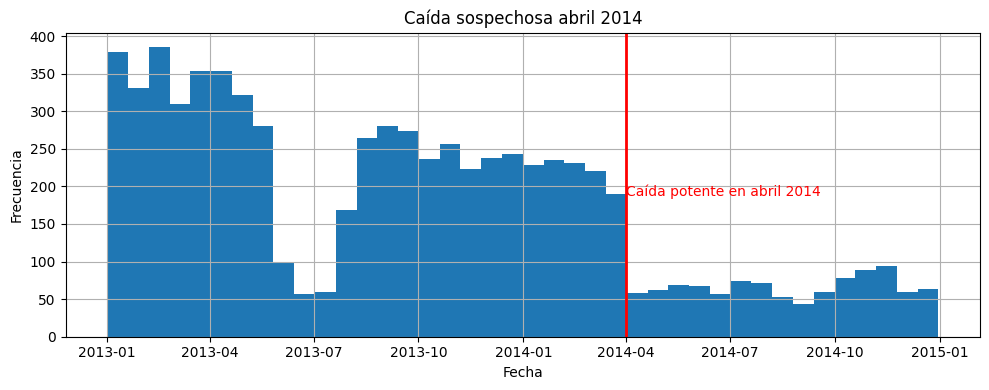

In [ ]:
# Graficamos para demostrarlo visualmente
compas_scores_two_years['compas_screening_date'].hist(bins=40, figsize=(10,4))
fecha = pd.to_datetime("2014-04")
plt.axvline(fecha, color="red", linestyle="-", linewidth=2)
plt.text(fecha, plt.ylim()[1]*0.5, "Caída potente en abril 2014",
         rotation=0, color="red", va="top")
plt.xlabel("Fecha")
plt.ylabel("Frecuencia")
plt.title("Caída sospechosa abril 2014")
plt.tight_layout()
plt.show()

##### En los datos vemos que ProPublica hizo un cutoff de 2 años únicamente en los no reincidentes, pero mantuvo los reincidentes

In [ ]:
# Vemos que no hay personas que superan la fecha de corte si no son reincidentes
compas_scores_two_years[(compas_scores_two_years["is_recid"] == 0) & (compas_scores_two_years["compas_screening_date"] > pd.to_datetime("2014-04-01"))].shape[0]

0

In [ ]:
# Vemos que hay 998 personas que superan la fecha de corte si son reincidentes
compas_scores_two_years[(compas_scores_two_years["is_recid"] == 1) & (compas_scores_two_years["compas_screening_date"] > pd.to_datetime("2014-04-01"))].shape[0]

998

Por coherencia: Eliminamos de nuestro dataset a todas las personas con compas_screening_date posterior al 1 de abril de 2014, para que los recidivastas y no recidivistas tengan el mismo cutoff date.

In [ ]:
cs_two_years_mask = ~((compas_scores_two_years["is_recid"] == 1) & (compas_scores_two_years["compas_screening_date"] > pd.to_datetime("2014-04-01")))

In [ ]:
compas_scores_two_years_filtered = compas_scores_two_years[cs_two_years_mask]

In [ ]:
# Comprobamos que se hayan eliminado correctamente
compas_scores_two_years_filtered[(compas_scores_two_years_filtered["is_recid"] == 1) & (compas_scores_two_years_filtered["compas_screening_date"] > pd.to_datetime("2014-04-01"))].shape[0]

0

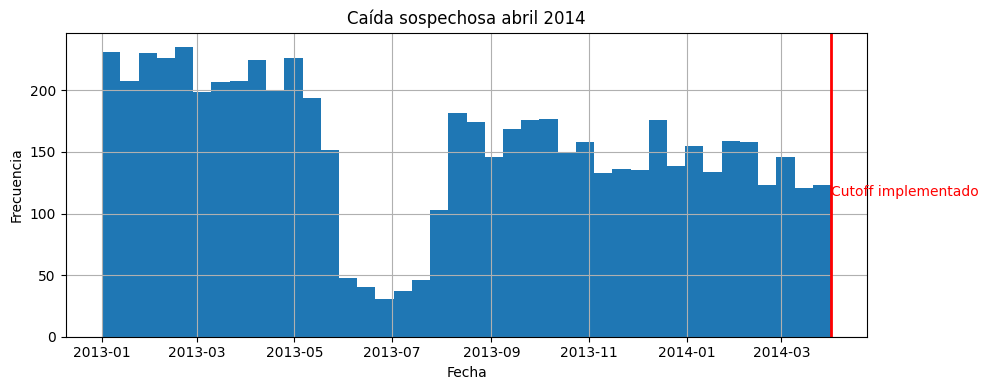

In [ ]:
# Graficamos para demostrarlo visualmente
compas_scores_two_years_filtered['compas_screening_date'].hist(bins=40, figsize=(10,4))
fecha = pd.to_datetime("2014-04")
plt.axvline(fecha, color="red", linestyle="-", linewidth=2)
plt.text(fecha, plt.ylim()[1]*0.5, "Cutoff implementado",
         rotation=0, color="red", va="top")
plt.xlabel("Fecha")
plt.ylabel("Frecuencia")
plt.title("Caída sospechosa abril 2014")
plt.tight_layout()
plt.show()

#### **DUPLICADOS**
##### Búsqueda de filas duplicadas

In [ ]:
duplicates_2_years = compas_scores_two_years_filtered[compas_scores_two_years_filtered.duplicated()]
duplicates_2_years.count().sum()

np.int64(0)

##### No hay duplicados

In [ ]:
duplicates_compas_scores_raw = compas_scores_raw[compas_scores_raw.duplicated()]
duplicates_compas_scores_raw.count().sum()

np.int64(0)

##### No hay duplicados

### Búsqueda de personas duplicadas: ¿Son las mismas personas?
#### Para determinar si existen personas duplicadas, usamos la fecha de nacimiento, la fecha de registro de COMPAS y el nombre para identificarlos unívocamente, para evitar confundir personas con el mismo nombre

In [ ]:
duplicates_2_years_people = compas_scores_two_years_filtered[compas_scores_two_years_filtered.duplicated(subset=["name"],keep=False)]
duplicates_2_years_people.sort_values(by="name")

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,start,end,event,two_year_recid
2461,3747,angel santiago,angel,santiago,2013-05-26,Male,1978-04-27,37,25 - 45,Caucasian,...,Risk of Violence,4,Low,2013-05-26,2013-05-25,2013-05-26,0,1041,0,0
6432,9810,angel santiago,angel,santiago,2013-09-17,Male,1983-07-28,32,25 - 45,African-American,...,Risk of Violence,4,Low,2013-09-17,2014-04-07,2014-04-10,0,202,0,0
5650,8613,anthony gonzalez,anthony,gonzalez,2013-04-10,Male,1982-08-26,33,25 - 45,Caucasian,...,Risk of Violence,2,Low,2013-04-10,2013-03-18,2013-03-18,0,1087,0,0
2772,4230,anthony gonzalez,anthony,gonzalez,2013-05-24,Male,1985-03-04,31,25 - 45,Hispanic,...,Risk of Violence,7,Medium,2013-05-24,2013-05-23,2013-08-12,80,1043,0,0
447,679,anthony louis,anthony,louis,2013-03-19,Male,1985-07-19,30,25 - 45,African-American,...,Risk of Violence,2,Low,2013-03-19,2013-03-19,2013-03-23,4,1109,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3114,4755,travis taylor,travis,taylor,2013-05-09,Male,1973-09-13,42,25 - 45,African-American,...,Risk of Violence,3,Low,2013-05-09,2013-11-25,2013-11-26,0,200,1,1
3889,5933,travis washington,travis,washington,2013-09-20,Male,1970-05-27,45,Greater than 45,African-American,...,Risk of Violence,1,Low,2013-09-20,2014-01-15,2014-01-21,0,117,0,1
5122,7799,travis washington,travis,washington,2013-04-10,Male,1990-04-23,25,25 - 45,African-American,...,Risk of Violence,7,Medium,2013-04-10,2014-05-23,2014-05-24,531,408,0,1
6189,9438,william shaw,william,shaw,2013-05-30,Male,1959-12-26,56,Greater than 45,African-American,...,Risk of Violence,4,Low,2013-05-30,2014-04-15,2014-05-06,0,320,0,0


In [ ]:
duplicates_2_years_people_check = compas_scores_two_years_filtered.copy()
duplicates_2_years_people_check["name_dob_assesmentdate_code"] = duplicates_2_years_people_check["first"] + duplicates_2_years_people_check["last"] + duplicates_2_years_people_check["dob"].astype("string").str.replace("-","") + duplicates_2_years_people_check["compas_screening_date"].astype("string").str.replace("-","")
duplicates_2_years_people_check["name_dob_assesmentdate_code"]


,name_dob_assesmentdate_code
0,miguelhernandez1947041820130814
1,kevondixon1982012220130127
2,edphilo1991051420130414
3,marcubrown1993012120130113
4,bouthypierrelouis1973012220130326
...,...
7208,raheemsmith1995062820131020
7209,stevenbutler1992071720131123
7210,malcolmsimmons1993032520140201
7211,winstongregory1958100120140114


In [ ]:
duplicates_2_years_people_check[duplicates_2_years_people_check.duplicated(subset=["name_dob_assesmentdate_code"],keep=False)].count().sum()

np.int64(0)

##### No hay duplicados. No hacemos el mismo ejercicio para el de "raw", ya que sabemos que hay por lo menos 3 scores por persona. Por ende, habrá personas con más de una fila. Como ya sabemos que no hay filas duplicadas, sabemos que no es un problema, por lo menos en lo que respecta a este ejercicio.

#### ***Personas presentes en el dataset de ProPublica pero no en el del Condado de Broward***

In [ ]:
#Creamos el mismo ID con la fecha de nacimiento, la fecha de registro de COMPAS y el nombre para identificarlos unívocamente
duplicates_raw_people_check = compas_scores_raw.copy()
duplicates_raw_people_check["name_dob_assesmentdate_code"] = duplicates_raw_people_check["FirstName"].str.lower() + duplicates_raw_people_check["LastName"].str.lower() + duplicates_raw_people_check["DateOfBirth"].dt.strftime("%Y%m%d") + duplicates_raw_people_check["Screening_Date"].dt.strftime("%Y%m%d")

In [ ]:
two_year_check_count = duplicates_2_years_people_check["name_dob_assesmentdate_code"].value_counts()
raw_check_count = duplicates_raw_people_check["name_dob_assesmentdate_code"].value_counts()

In [ ]:
raw_2year_duplicate_check = (two_year_check_count.rename("two_year_check_count").to_frame().join(raw_check_count.rename("raw_check_count"), how="inner"))
display(f"El recuento de registros en 'compas_scores_two_years': {duplicates_2_years_people_check["name_dob_assesmentdate_code"].count()}")
display(f"El registro de elementos compartidos entre 'compas_scores_two_years' y 'compas_scores_raw': {raw_2year_duplicate_check["raw_check_count"].count()}")
display(f"Diferencia entre ambos: {duplicates_2_years_people_check["name_dob_assesmentdate_code"].count() - raw_2year_duplicate_check["raw_check_count"].count()}")


"El recuento de registros en 'compas_scores_two_years': 6216"

"El registro de elementos compartidos entre 'compas_scores_two_years' y 'compas_scores_raw': 4779"

'Diferencia entre ambos: 1437'

Al cruzar ambos datasets, identificamos **1437 personas (23,11%)** que aparecen en el dataset de ProPublica pero no tienen correspondencia en el dataset raw del Condado de Broward.

Aunque el volumen es significativo, **no se recomienda eliminar estos registros**, por las siguientes razones:

- Es improbable que ProPublica haya fabricado registros: su metodología está documentada y su objetivo era estudiar la reincidencia a dos años, no expandir artificialmente la muestra.
- Algunas discrepancias pueden deberse a correcciones editoriales aplicadas por ProPublica (por ejemplo, nombres y apellidos transpuestos), que dificultan el cruce por nombre pero no invalidan los registros.
- Revisar manualmente 1437 casos no es un uso eficiente del tiempo en esta fase del análisis.

**Decisión adoptada:** Ambos datasets sirven propósitos distintos y se trabajarán en paralelo cuando sea necesario. El dataset de ProPublica (**"compas-scores-two-years.csv"**) se usará como fuente principal para el análisis de reincidencia a dos años, sin descartar los registros no coincidentes.

#### ***Limpieza del dataset raw*** (*compas_scores_raw.csv*)

Dado el volumen del dataset y la imposibilidad de validar registros con el Condado de Broward, la estrategia adoptada es **corregir los errores que afecten directamente al análisis, sin eliminar filas completas por errores parciales**: un error en una columna no invalida el resto de la información del registro.

Vale la pena notar que muchos de estos problemas parecen estar ya corregidos en el dataset de ProPublica, como los **errores de imputación de etnicidad** detectados en el raw. Por tanto, para los análisis principales se priorizará el dataset de ProPublica, recurriendo al raw solo cuando sea estrictamente necesario.

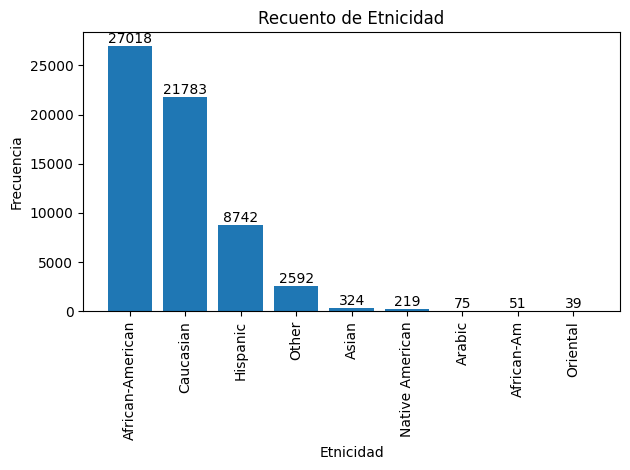

In [ ]:
# Raw tiene problemas en la imputación de nombres de etnicidad

freq = compas_scores_raw['Ethnic_Code_Text'].value_counts()
plt.bar(freq.index, freq.values)
for x, y in zip(freq.index, freq.values):
    plt.text(x, y, str(y), ha='center', va='bottom')

plt.xlabel('Etnicidad')
plt.ylabel('Frecuencia')
plt.title('Recuento de Etnicidad')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

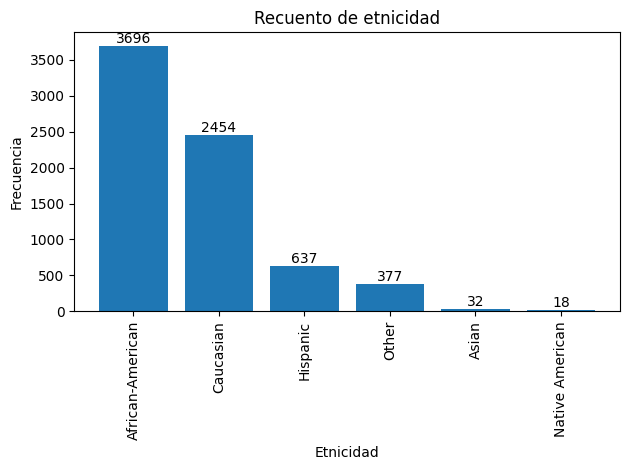

In [ ]:
# Algo que parece corregido en la de 2 years
freq = compas_scores_two_years['race'].value_counts()
plt.bar(freq.index, freq.values)
for x, y in zip(freq.index, freq.values):
    plt.text(x, y, str(y), ha='center', va='bottom')

plt.xlabel('Etnicidad')
plt.ylabel('Frecuencia')
plt.title('Recuento de etnicidad')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Esto puede corregirse fácilmente, pero debemos asumir algunas cosas:
- African-Am = claramente "African-American"
- Arabic = va a "Other"
- Oriental = va a "Asian"

**Aplicamos estos cambios en raw**

In [ ]:
etnicidad_reemplazo_raw = replacements = {"African-Am": "African-American","Oriental": "Asian","Arabic": "Other"}
compas_scores_raw_fixed = compas_scores_raw.copy()
compas_scores_raw_fixed["Ethnic_Code_Text"] = compas_scores_raw_fixed["Ethnic_Code_Text"].replace(etnicidad_reemplazo_raw)
compas_scores_raw_fixed["Ethnic_Code_Text"].value_counts()

,count
Ethnic_Code_Text,
African-American,27069
Caucasian,21783
Hispanic,8742
Other,2667
Asian,363
Native American,219


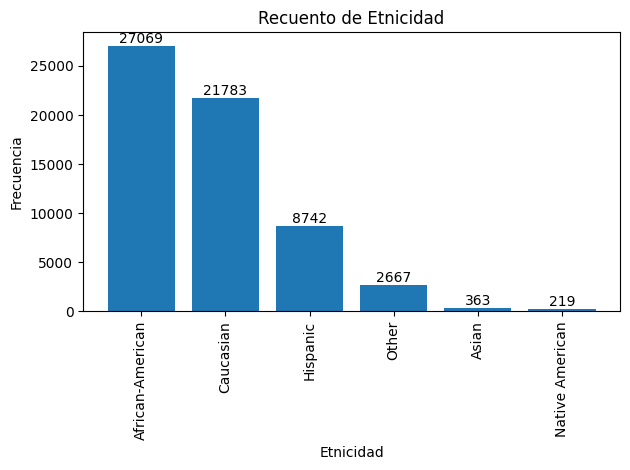

In [ ]:
freq = compas_scores_raw_fixed['Ethnic_Code_Text'].value_counts()
plt.bar(freq.index, freq.values)
for x, y in zip(freq.index, freq.values):
    plt.text(x, y, str(y), ha='center', va='bottom')

plt.xlabel('Etnicidad')
plt.ylabel('Frecuencia')
plt.title('Recuento de Etnicidad')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

2. Los datos tienen problemas de imputación en la edad. Aquí debemos ir con algo más de cuidado y hacer suposiciones

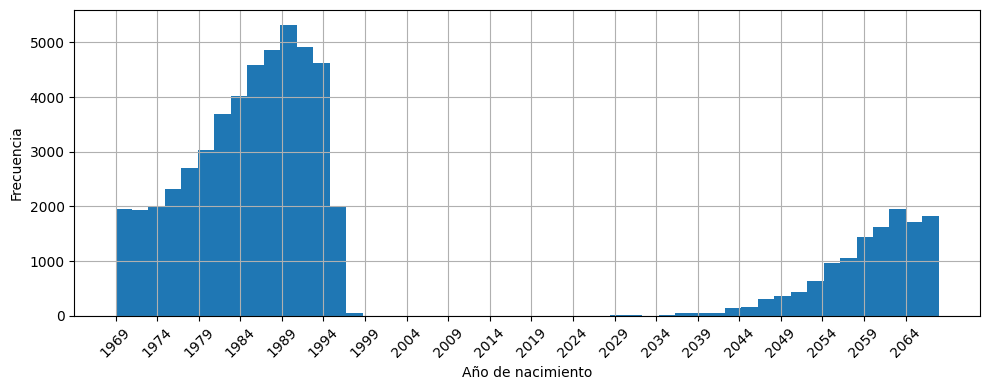

In [ ]:
# Raw tiene años de nacimiento inverosímiles
years_raw = compas_scores_raw['DateOfBirth'].dt.year
years_raw.hist(bins=50, figsize=(10,4))
plt.xlabel("Año de nacimiento")
plt.ylabel("Frecuencia")
min_year = int(years_raw.min())
max_year = int(years_raw.max())
plt.xticks(range(min_year, max_year + 1, 5), rotation=45)

plt.tight_layout()
plt.show()


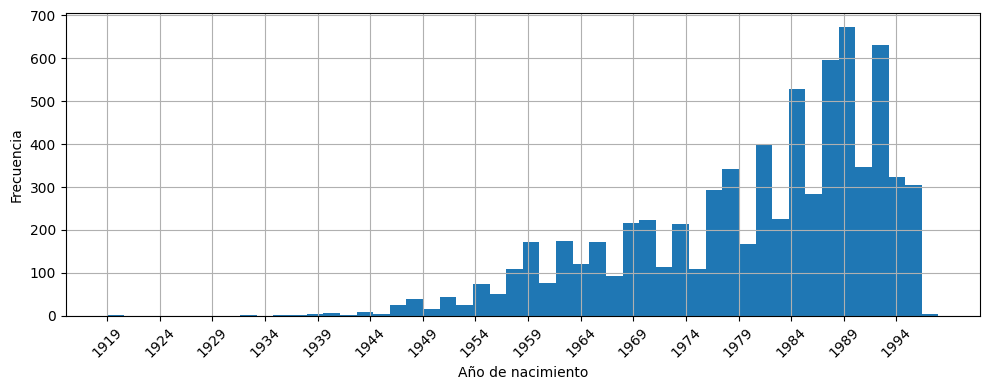

In [ ]:
# En 2_years, aparece otro error interesante: gente mucho mayor.
compas_scores_two_years_check_dob = compas_scores_two_years
years_two_years = compas_scores_two_years_check_dob['dob'].dt.year
years_two_years.hist(bins=50, figsize=(10,4))
plt.xlabel("Año de nacimiento")
plt.ylabel("Frecuencia")
min_year = int(years_two_years.min())
max_year = int(years_two_years.max())
plt.xticks(range(min_year, max_year + 1, 5), rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Revisamos la cantidad de pesonas nacidas después de 1996 (menores de edad o con fechas en el futuro)
impossible_dob_duplicates_raw_people_check = (duplicates_raw_people_check.loc[duplicates_raw_people_check["DateOfBirth"] > "1996-12-31",["name_dob_assesmentdate_code","DateOfBirth"]].copy())
impossible_dob_duplicates_raw_people_check = impossible_dob_duplicates_raw_people_check.drop_duplicates()
impossible_dob_duplicates_raw_people_check.count()

,0
name_dob_assesmentdate_code,4260
DateOfBirth,4260


In [ ]:
duplicates_2_years_people_check =  (duplicates_2_years_people_check.loc[duplicates_2_years_people_check["dob"] > "1996-12-31",["name_dob_assesmentdate_code","dob"]].copy())
duplicates_2_years_people_check

,name_dob_assesmentdate_code,dob
1357,darrenhouston1997041320131115,1997-04-13


En cada uno, podemos ver los límites superiores e inferiores.

In [ ]:
# Más viejo en raw
compas_scores_raw.loc[compas_scores_raw["DateOfBirth"].idxmin()]["DateOfBirth"]

Timestamp('1969-01-01 00:00:00')

In [ ]:
# Más joven en raw
compas_scores_raw.loc[compas_scores_raw["DateOfBirth"].idxmax()]["DateOfBirth"]

Timestamp('2068-12-28 00:00:00')

In [ ]:
#Más viejo en 2 years
compas_scores_two_years.loc[compas_scores_two_years["dob"].idxmin()]["dob"]

Timestamp('1919-10-14 00:00:00')

In [ ]:
#Más joven en 2 years
compas_scores_two_years.loc[compas_scores_two_years["dob"].idxmax()]["dob"]

Timestamp('1998-01-20 00:00:00')

La suposición que podemos hacer es que hay problemas de imputación, y podríamos limitar la cohorte a los que:
- Tienen una edad inferior a la media de vida en EE. UU. (~77 años) para la fecha en la que se ha hecho el screening.
- Son mayores de edad para la fecha en la que se ha hecho el screening.

In [ ]:
# Creamos columnas que calculen un valor booleano si la persona está en ese rango de edad con relación a la fecha de screening.
compas_scores_raw_fixed["adult_at_screening"] = compas_scores_raw_fixed["DateOfBirth"] <= (compas_scores_raw_fixed["Screening_Date"] - pd.DateOffset(years=18))
compas_scores_raw_fixed["younger_than_average_lifespan"] = compas_scores_raw_fixed["DateOfBirth"] > (compas_scores_raw_fixed["Screening_Date"] - pd.DateOffset(years=77))

In [ ]:
# Creamos columnas que calculne un valor booleano si la persona está en ese rango de edad con relación a la fecha de screening.
compas_scores_two_years_filtered["adult_at_screening"] = compas_scores_two_years_filtered["dob"] <= (compas_scores_two_years_filtered["compas_screening_date"] - pd.DateOffset(years=18))
compas_scores_two_years_filtered["younger_than_average_lifespan"] = compas_scores_two_years_filtered["dob"] > (compas_scores_two_years_filtered["compas_screening_date"] - pd.DateOffset(years=77))

In [ ]:
# Mostramos los resultados
display(compas_scores_two_years_filtered["adult_at_screening"].value_counts())
display(compas_scores_two_years_filtered["younger_than_average_lifespan"].value_counts())
display(compas_scores_raw_fixed["adult_at_screening"].value_counts())
display(compas_scores_raw_fixed["younger_than_average_lifespan"].value_counts())

,count
adult_at_screening,
True,6199
False,17


,count
younger_than_average_lifespan,
True,6212
False,4


,count
adult_at_screening,
True,47898
False,12945


,count
younger_than_average_lifespan,
True,60843


In [ ]:
# Creamos una tabla nueva con este valor capado
compas_scores_raw_fixed_age_capped = compas_scores_raw_fixed.query("younger_than_average_lifespan & adult_at_screening")
compas_scores_two_years_filtered_age_capped = compas_scores_two_years_filtered.query("younger_than_average_lifespan & adult_at_screening")

In [ ]:
# Confirmamos que se hayan capado correctamente
display(compas_scores_two_years_filtered_age_capped["adult_at_screening"].value_counts())
display(compas_scores_two_years_filtered_age_capped["younger_than_average_lifespan"].value_counts())
display(compas_scores_raw_fixed_age_capped["adult_at_screening"].value_counts())
display(compas_scores_raw_fixed_age_capped["younger_than_average_lifespan"].value_counts())

,count
adult_at_screening,
True,6195


,count
younger_than_average_lifespan,
True,6195


,count
adult_at_screening,
True,47898


,count
younger_than_average_lifespan,
True,47898


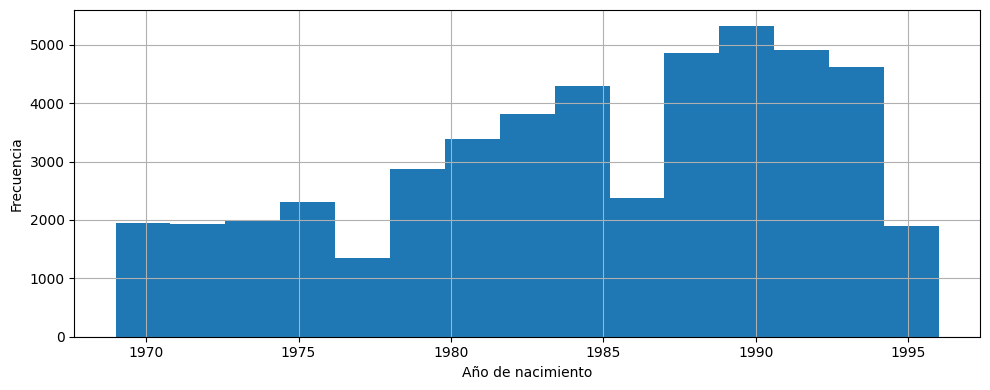

In [ ]:
# Parece corregido
years_raw = compas_scores_raw_fixed_age_capped['DateOfBirth'].dt.year
years_raw.hist(bins=15, figsize=(10,4))
plt.xlabel("Año de nacimiento")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


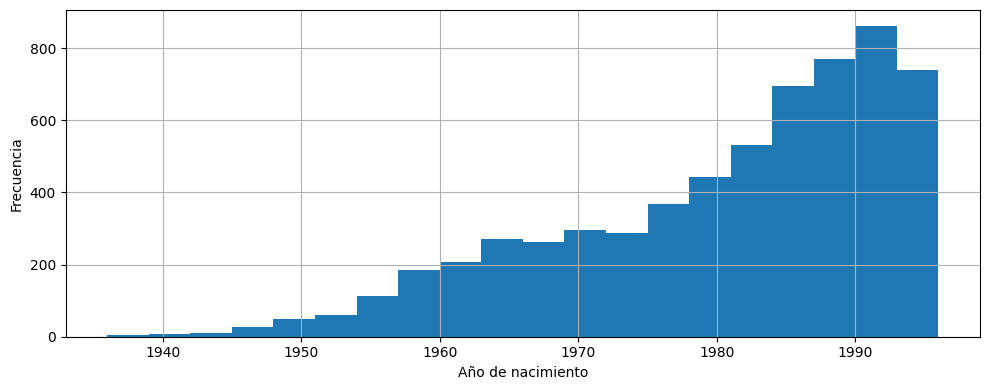

In [ ]:
# Parece corregido también
years_two_years = compas_scores_two_years_filtered_age_capped['dob'].dt.year
years_two_years.hist(bins=20, figsize=(10,4))
plt.xlabel("Año de nacimiento")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


## **ANÁLISIS DESCRIPTIVO**
### COMENZAMOS CON UN ANÁLISIS DEL PERFIL DE DETENIDOS DEL COMPASS-SCORE-RAW

In [ ]:
def graficar_barras_relativo_px (compas_scores_raw_fixed_age_capped,variable_analisis):

    volumen = compas_scores_raw_fixed_age_capped [variable_analisis].value_counts(normalize=False).reset_index()
    volumen.columns = [variable_analisis, 'Frecuencia']


    volumen['Porcentaje'] = compas_scores_raw_fixed_age_capped [variable_analisis].value_counts(normalize=True).reset_index(drop=True) * 100


    volumen['Cantidad'] = volumen.apply(lambda row: f'{row["Frecuencia"]} ({row["Porcentaje"]:.2f}%)', axis=1)


    fig = px.bar(volumen, x=variable_analisis, y='Porcentaje', text=volumen['Cantidad'])
    fig.update_traces(texttemplate='%{text}', textposition='outside')
    fig.update_layout(title_text=f'Gráfico de barras relativo: {variable_analisis}',
                      xaxis_title=variable_analisis,
                      yaxis_title='Porcentaje',
                      xaxis={'categoryorder': 'total descending'})


    fig.update_layout({
        'plot_bgcolor': 'rgba(255, 255, 255, 1)',
        'xaxis': {'showgrid': True, 'gridcolor': 'lightgrey'},
        'yaxis': {'showgrid': True, 'gridcolor': 'lightgrey'}
    })

    fig.show()

In [ ]:
graficar_barras_relativo_px(compas_scores_raw_fixed_age_capped, "Ethnic_Code_Text")

In [ ]:
graficar_barras_relativo_px(compas_scores_raw_fixed_age_capped, "Sex_Code_Text")

In [ ]:
graficar_barras_relativo_px(compas_scores_raw_fixed_age_capped, "MaritalStatus")

Hacemos un estudio sobre los deciles por razas

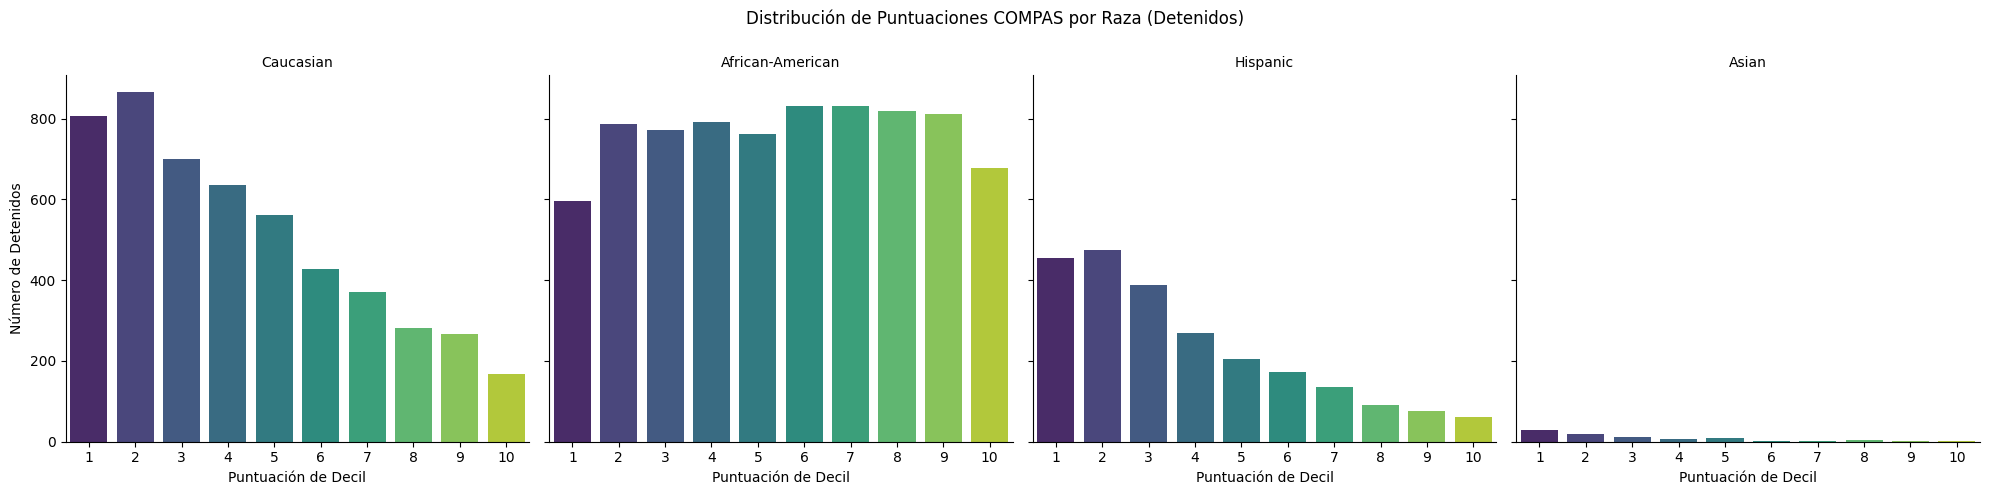

In [ ]:
df_estudio = compas_scores_raw_fixed_age_capped[
    compas_scores_raw_fixed_age_capped['DisplayText'] == 'Risk of Recidivism'
]


razas_interes = ['African-American', 'Caucasian', 'Hispanic', "Asian"]
df_filtrado = df_estudio[df_estudio['Ethnic_Code_Text'].isin(razas_interes)]


g = sns.FacetGrid(df_filtrado, col="Ethnic_Code_Text", height=5, aspect=1)


g.map(sns.countplot, "DecileScore", order=range(1, 11), palette="viridis")

g.set_titles("{col_name}")
g.set_axis_labels("Puntuación de Decil", "Número de Detenidos")

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Distribución de Puntuaciones COMPAS por Raza (Detenidos)')

plt.show()

### Se ve claramente como la tendencia del DecileScore que se le da a la reincidencia de los detenidos en los caucasicos, hispanos y asiaticos es descendente, mientras que en los Africanos-Americanos es lineal

Lo comparamos con el RawScore para comprobar que sigue la misma coherencia

<Figure size 1200x600 with 0 Axes>

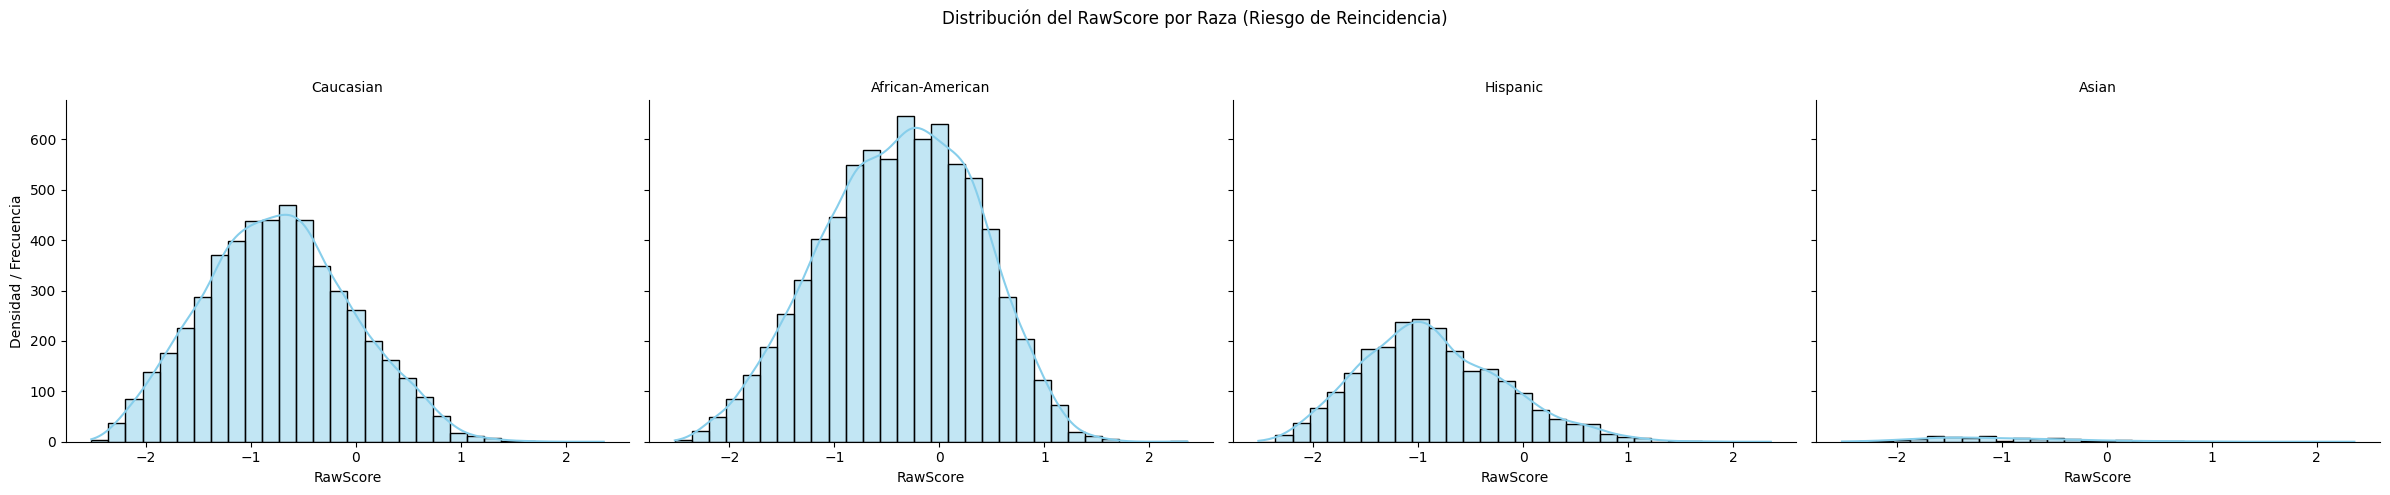

In [ ]:
df_estudio = compas_scores_raw_fixed_age_capped[
    (compas_scores_raw_fixed_age_capped['DisplayText'] == 'Risk of Recidivism') &
    (compas_scores_raw_fixed_age_capped['RawScore'].notnull())
]


razas_interes = ['African-American', 'Caucasian', 'Hispanic', "Asian"]
df_filtrado = df_estudio[df_estudio['Ethnic_Code_Text'].isin(razas_interes)]


plt.figure(figsize=(12, 6))


g = sns.displot(
    data=df_filtrado,
    x="RawScore",
    col="Ethnic_Code_Text",
    kde=True,
    color="skyblue",
    bins=30,
    height=5,
    aspect=1.2
)


g.set_titles("{col_name}")
g.set_axis_labels("RawScore", "Densidad / Frecuencia")

plt.subplots_adjust(top=0.8)
g.fig.suptitle('Distribución del RawScore por Raza (Riesgo de Reincidencia)')

plt.show()

In [ ]:
df_estudio = compas_scores_raw_fixed_age_capped[
    compas_scores_raw_fixed_age_capped['DisplayText'] == 'Risk of Recidivism'
]

razas_interes = ['African-American', 'Caucasian', 'Hispanic', "Asian"]

descrip_raw = (
    df_estudio[df_estudio['Ethnic_Code_Text'].isin(razas_interes)]
    .groupby('Ethnic_Code_Text')['RawScore']
    .describe()
    .round(3)
)
print("Análisis Descriptivo del RawScore por Raza:")
display(descrip_raw)

Análisis Descriptivo del RawScore por Raza:


,count,mean,std,min,25%,50%,75%,max
Ethnic_Code_Text,,,,,,,,
African-American,7692.0,-0.375,0.729,-2.41,-0.890,-0.340,0.17,2.36
Asian,88.0,-1.045,0.670,-2.29,-1.552,-1.175,-0.59,0.68
Caucasian,5093.0,-0.738,0.697,-2.52,-1.240,-0.760,-0.27,1.69
Hispanic,2332.0,-0.854,0.673,-2.35,-1.340,-0.920,-0.41,1.69


Todos los estadisticos la raza African-American reciben un puntaje superior a la reincidencia. Además, se ve como la campana de RawScore respecto a la reincidencia por raza en los afroamericanos está desplazada a la derecha (más puntuación) respecto a las demás razas. Vamos a comprobar que variables puedan motivarlo

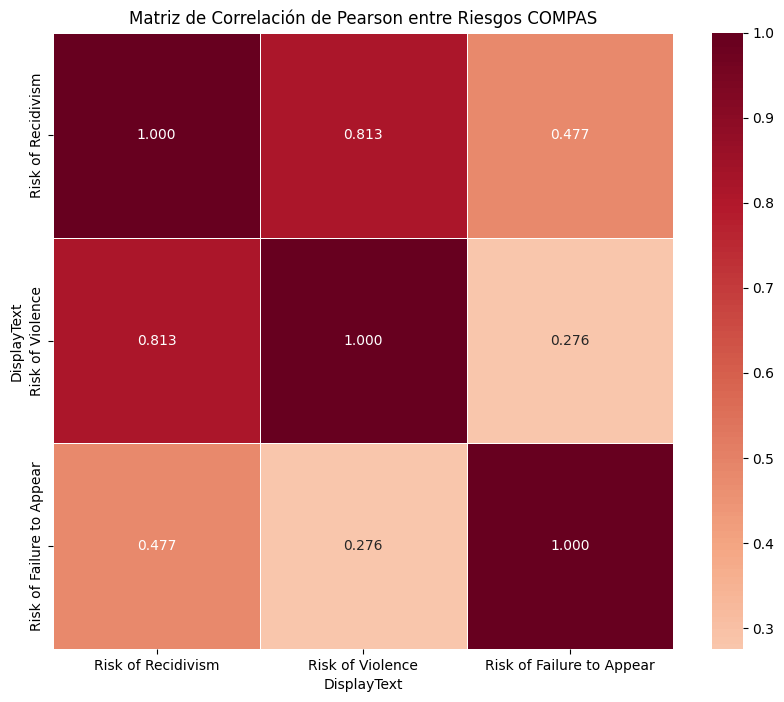

Matriz de Coeficientes:


DisplayText,Risk of Recidivism,Risk of Violence,Risk of Failure to Appear
DisplayText,,,
Risk of Recidivism,1.000000,0.813278,0.476809
Risk of Violence,0.813278,1.000000,0.275587
Risk of Failure to Appear,0.476809,0.275587,1.000000


In [ ]:
df_pivot = compas_scores_raw_fixed_age_capped.pivot_table(
    index='Person_ID',
    columns='DisplayText',
    values='RawScore'
)


matriz_pearson = df_pivot[['Risk of Recidivism', 'Risk of Violence', 'Risk of Failure to Appear']].corr(method='pearson')


plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(matriz_pearson, dtype=bool))

sns.heatmap(matriz_pearson, annot=True, cmap='RdBu_r', center=0, fmt=".3f", linewidths=.5)
plt.title('Matriz de Correlación de Pearson entre Riesgos COMPAS')
plt.show()

print("Matriz de Coeficientes:")
display(matriz_pearson)

Podemos comprobar que el riesgo de reincidencia está altamente correlacionado con el riesgo de violencia. Al buscar los posibles sesgos en el puntaje de reincidencia de los detenidos y este estar tan correlacionado con el riesgo de violencia, vamos a estudiar los puntajes por violencia que se dieron

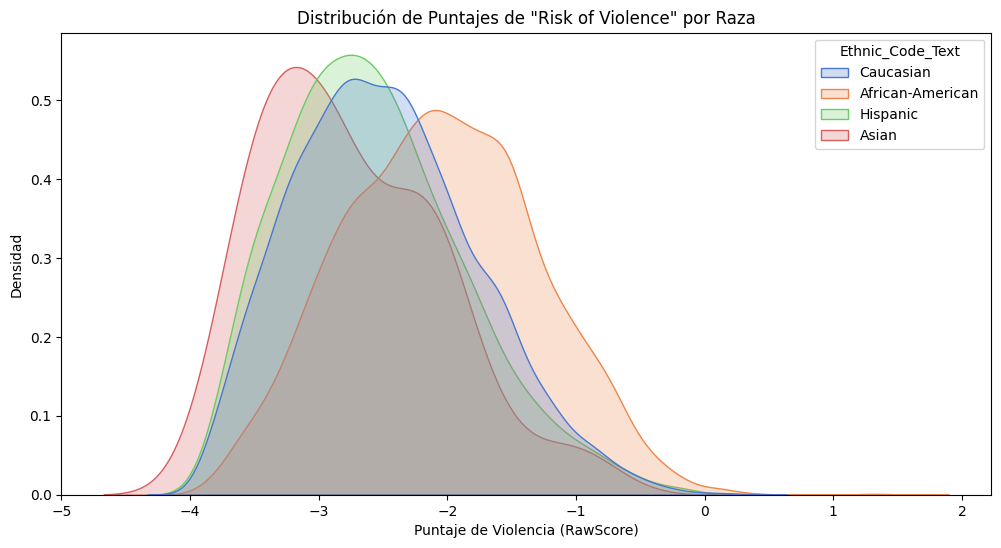

In [ ]:
df_filtered = compas_scores_raw_fixed_age_capped[
    (compas_scores_raw_fixed_age_capped['Ethnic_Code_Text'].isin(razas_interes)) &
    (compas_scores_raw_fixed_age_capped['DisplayText'] == 'Risk of Violence')
]

plt.figure(figsize=(12, 6))
sns.kdeplot(data=df_filtered, x='RawScore', hue='Ethnic_Code_Text', fill=True, common_norm=False, palette='muted')
plt.title('Distribución de Puntajes de "Risk of Violence" por Raza')
plt.xlabel('Puntaje de Violencia (RawScore)')
plt.ylabel('Densidad')
plt.show()

In [ ]:
stats_violencia = df_filtered.groupby('Ethnic_Code_Text')['RawScore'].agg(['mean', 'std', 'median', 'count'])
print("Estadísticas de Riesgo de Violencia por Raza:")
display(stats_violencia)

Estadísticas de Riesgo de Violencia por Raza:


,mean,std,median,count
Ethnic_Code_Text,,,,
African-American,-2.050101,0.757700,-2.06,7692
Asian,-2.748636,0.696073,-2.87,88
Caucasian,-2.482641,0.712051,-2.53,5093
Hispanic,-2.568049,0.706634,-2.63,2332


Se puede ver tanto en la campana desplazada a la derecha y en los estadisticos, que el puntaje recibido por la etnia African-American es el más alto en general.

Vamos a aplicar la misma lógica a las variables de género, edad y a estado civil

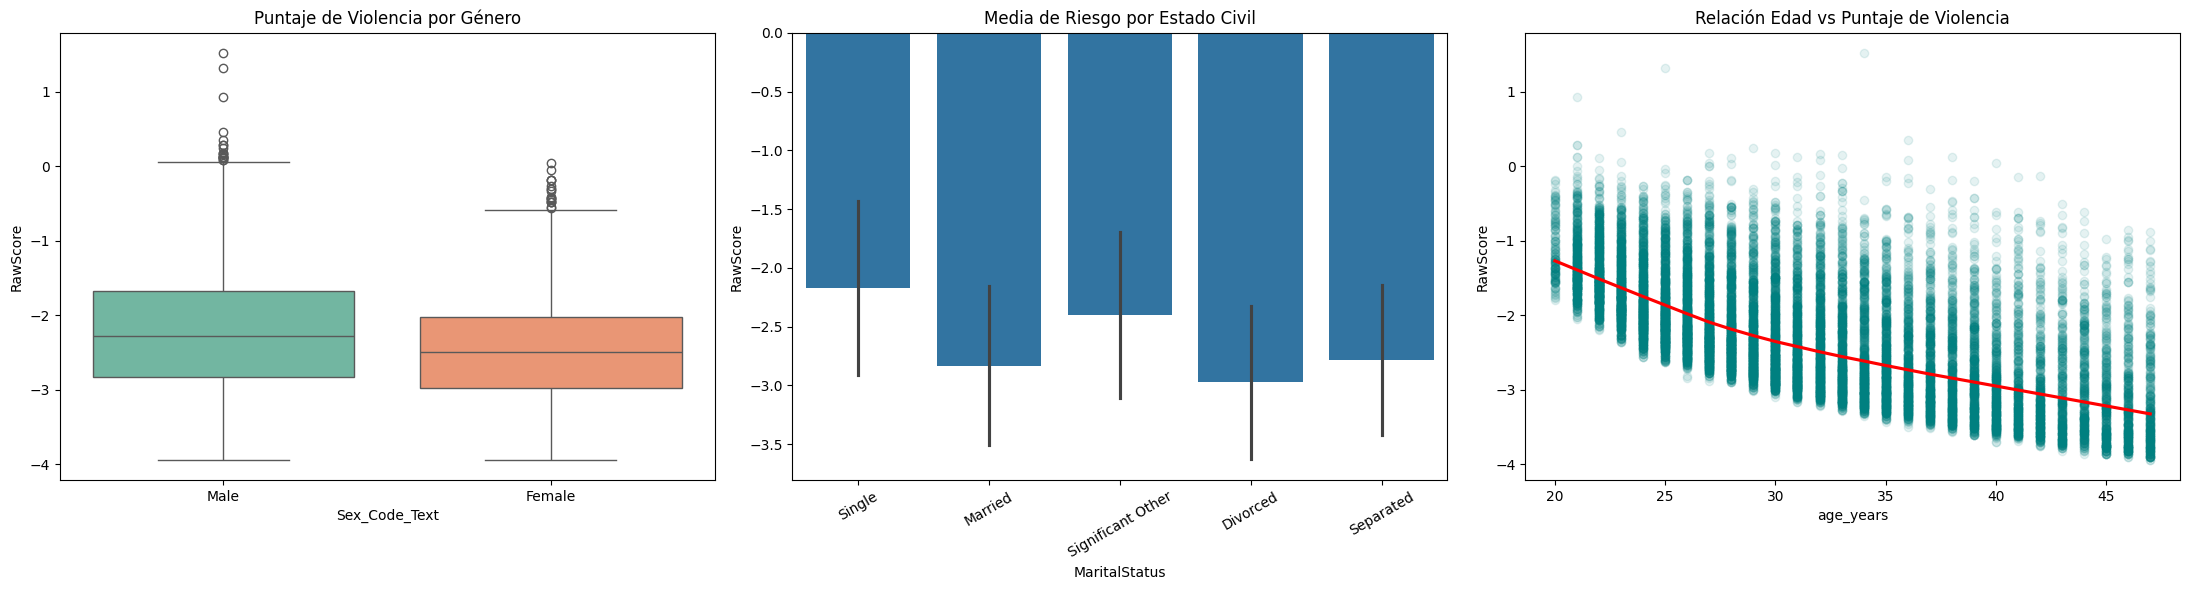

In [ ]:
# Creamos la columna de edad con el año 2016 como referencia para ser fieles al dataset original de COMPAS
compas_scores_raw_fixed_age_capped['age_years'] = 2016 - compas_scores_raw_fixed_age_capped['DateOfBirth'].dt.year


df_violencia = compas_scores_raw_fixed_age_capped[
    compas_scores_raw_fixed_age_capped['DisplayText'] == 'Risk of Violence'
].copy()


fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Género (Sex_Code_Text)
sns.boxplot(data=df_violencia, x='Sex_Code_Text', y='RawScore', ax=axes[0], palette='Set2')
axes[0].set_title('Puntaje de Violencia por Género')

# Estado Civil (MaritalStatus) - Solo las categorías más comunes para evitar ruido
top_marital = df_violencia['MaritalStatus'].value_counts().nlargest(5).index
df_marital = df_violencia[df_violencia['MaritalStatus'].isin(top_marital)]

sns.barplot(data=df_marital, x='MaritalStatus', y='RawScore', ax=axes[1], errorbar='sd')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_title('Media de Riesgo por Estado Civil')

# Edad (La edad que calculamos)
sns.regplot(data=df_violencia, x='age_years', y='RawScore',
            scatter_kws={'alpha':0.1, 'color':'teal'}, line_kws={'color':'red'},
            lowess=True, ax=axes[2])
axes[2].set_title('Relación Edad vs Puntaje de Violencia')

plt.tight_layout()
plt.show()

Las conclusiones más claras que se pueden sacar son que los puntajes más altos de riesgo de la violencia son para los detenidos solteros, más jovenes y de etnia African-American. Levemente el genero másculino tambien recibe un puntaje superior.

El motivo de estudiar el puntaje al riesgo de violencia es ver que variable está "inflando" el riesgo a reincidir, al ser la violencia la que tiene la mayor correlación (muy alta de hecho) es lógico pensar que un posible sesgo a la hora de puntuar el riesgo de violencia acabe con un sesgo a la hora de determinar si el detenido va a reincidir

<Figure size 1200x700 with 0 Axes>

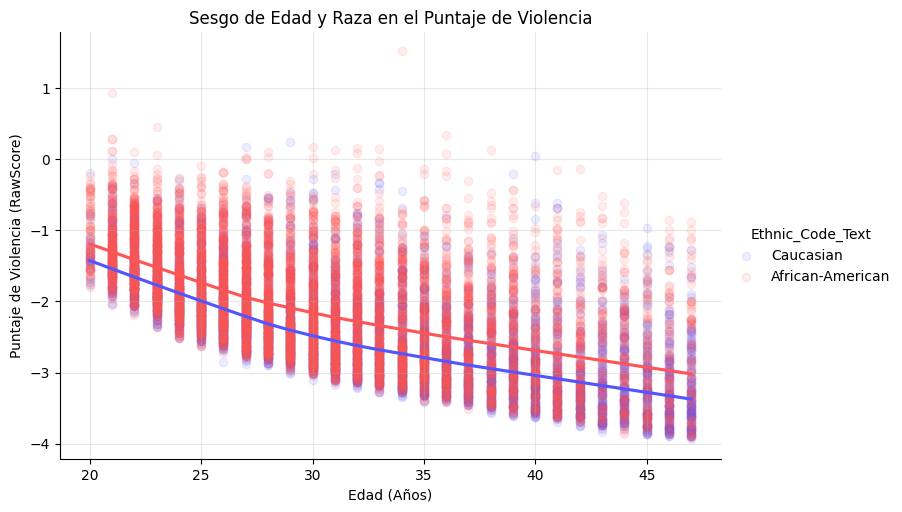

In [ ]:
#Vamos a hacer un experimento,
df_violencia = compas_scores_raw_fixed_age_capped[
    compas_scores_raw_fixed_age_capped['DisplayText'] == 'Risk of Violence'
].copy()
df_violencia['age_years'] = 2016 - df_violencia['DateOfBirth'].dt.year

df_comparativo = df_violencia[df_violencia['Ethnic_Code_Text'].isin(['African-American', 'Caucasian'])]

plt.figure(figsize=(12, 7))


sns.lmplot(data=df_comparativo, x='age_years', y='RawScore', hue='Ethnic_Code_Text',
           scatter_kws={'alpha':0.1}, aspect=1.5, lowess=True, palette='seismic')

plt.title('Sesgo de Edad y Raza en el Puntaje de Violencia')
plt.xlabel('Edad (Años)')
plt.ylabel('Puntaje de Violencia (RawScore)')
plt.grid(alpha=0.3)
plt.show()

Se ve como a lo largo del estudio por edad la etnia African-American siempre sigue una diferencia de puntaje superior respecto a la caucasica. (Ambas etnias representan el 80% de la muestra)

A partir de aquí comenzamos a estudiar el compass-score-two-years

Hemos visto como se distribuyen los puntajes por variables demograficas. Vamos a comprobar la variable de reincidencia real a ver si justifica dichos puntajes

In [ ]:
stats_reincidencia_etnia = compas_scores_two_years_filtered_age_capped.groupby("race").agg({
    "v_decile_score" : "mean",
    "two_year_recid" : "mean",
    "is_violent_recid" : "mean",
    "id" : "count"
}). rename (columns={"id":"total_casos"})
stats_reincidencia_etnia

,v_decile_score,two_year_recid,is_violent_recid,total_casos
race,,,,
African-American,4.287816,0.426607,0.116086,3127
Asian,2.250000,0.178571,0.107143,28
Caucasian,2.839756,0.301692,0.072368,2128
Hispanic,2.912343,0.279070,0.073345,559
Native American,4.285714,0.428571,0.142857,14
Other,2.755162,0.283186,0.088496,339


In [ ]:
#Dividimos decile_score entre 10 para interpretarlo como porcentaje
stats_reincidencia_etnia["brecha_violencia"] = (stats_reincidencia_etnia["v_decile_score"]/10) - stats_reincidencia_etnia['is_violent_recid']
stats_reincidencia_etnia


,v_decile_score,two_year_recid,is_violent_recid,total_casos,brecha_violencia
race,,,,,
African-American,4.287816,0.426607,0.116086,3127,0.312696
Asian,2.250000,0.178571,0.107143,28,0.117857
Caucasian,2.839756,0.301692,0.072368,2128,0.211607
Hispanic,2.912343,0.279070,0.073345,559,0.217889
Native American,4.285714,0.428571,0.142857,14,0.285714
Other,2.755162,0.283186,0.088496,339,0.187021


In [ ]:
stats_reincidencia_etnia = stats_reincidencia_etnia.sort_values(by="v_decile_score", ascending=False)
stats_reincidencia_etnia

,v_decile_score,two_year_recid,is_violent_recid,total_casos,brecha_violencia
race,,,,,
African-American,4.287816,0.426607,0.116086,3127,0.312696
Native American,4.285714,0.428571,0.142857,14,0.285714
Hispanic,2.912343,0.279070,0.073345,559,0.217889
Caucasian,2.839756,0.301692,0.072368,2128,0.211607
Other,2.755162,0.283186,0.088496,339,0.187021
Asian,2.250000,0.178571,0.107143,28,0.117857


Se puede observar que el riesgo de reincidencia violenta está entre el 30% y 40% en los grupos mayoritarios, mientras la reincidencia violenta real es mucho más baja, situandose entre el 7% y el 11%.
En etnias como African- American, el sistema le da un puntaje de riesgo de violencia de 4.28 (lo que podria interpretarse como un 42,8%), pero la reincidencia violenta es tan solo del 11,6%.
El modelo es alarmista respecto al riesgo de violencia en todos las etnias pero en African - American es muy grande la diferencia respecto a la realidad (este hecho sucede en Native-American pero es una muestra muy pequeña para valorarla con fiabilidad)
Llama la atención como los dos siguientes grupos de etnias con mayor representación (Caucasian, Hispanic), despues de African-American, tienen un puntaje de riesgo de violencia y brecha en el puntaje practicamente idéntico, reafirmando más la distinción en el trato a la etnia African-American donde reciben puntajes más altos y la brecha es mayor.

Vamos a hacer el mismo procedimiento usando como variable de estudio la edad

In [ ]:
compas_scores_two_years_filtered_age_capped["age_cat"] = (compas_scores_two_years_filtered_age_capped["age_cat"].astype(str).str.strip())


In [ ]:
stats_reincidencia_edad= compas_scores_two_years_filtered_age_capped.groupby("age_cat").agg({
   "v_decile_score" : "mean",
    "two_year_recid" : "mean",
    "is_violent_recid" : "mean",
    "id" : "count"
}). rename (columns={"id":"total_casos"})

In [ ]:
stats_reincidencia_edad["brecha_violencia"] = (stats_reincidencia_edad["v_decile_score"]/10) - stats_reincidencia_edad['is_violent_recid']

In [ ]:
orden_edad = ["Less than 25", "25 - 45", "Greater than 45"]
stats_reincidencia_edad = stats_reincidencia_edad.reindex(orden_edad)
stats_reincidencia_edad

,v_decile_score,two_year_recid,is_violent_recid,total_casos,brecha_violencia
age_cat,,,,,
Less than 25,6.084074,0.465643,0.130154,1237,0.478254
25 - 45,3.429946,0.371639,0.100481,3533,0.242513
Greater than 45,1.748772,0.245614,0.054035,1425,0.120842


In [ ]:
print (compas_scores_two_years_filtered_age_capped["age_cat"].unique())

['Greater than 45' '25 - 45' 'Less than 25']


---

### **ANALISIS DE TASAS DE RECIDIVISMO ENTRE GRUPOS ÉTNICOS MÁS IMPORTANTES**
#### Antes de continuar, analizemos la diferencia en las tasas de recidivismo de base de los dos grupos étnicos más grandes, African-American y Caucasian
Estas nos indicaran las diferencias entre grupos en la frecuencia subyacente del resultado que se predice (recidivismo después de dos años), antes de que se aplique cualquier modelo o regla de decisión (es decir, el COMPAS score).

In [ ]:
compas_scores_two_years_eval = compas_scores_two_years_filtered_age_capped.copy()

In [ ]:
tasa_base = (compas_scores_two_years_eval[compas_scores_two_years_eval["race"].isin(["Caucasian", "African-American"])].groupby("race")["two_year_recid"].agg(tasa_base="mean",n="count").reset_index()).rename(columns={
"race": "Raza","tasa_base": "Tasa de recidivismo","n": "Cantidad de casos"})
tasa_base["Tasa de recidivismo"] = (tasa_base["Tasa de recidivismo"]*100).round(2)
tasa_base

,Raza,Tasa de recidivismo,Cantidad de casos
0,African-American,42.66,3127
1,Caucasian,30.17,2128


Veámoslo gráficamente

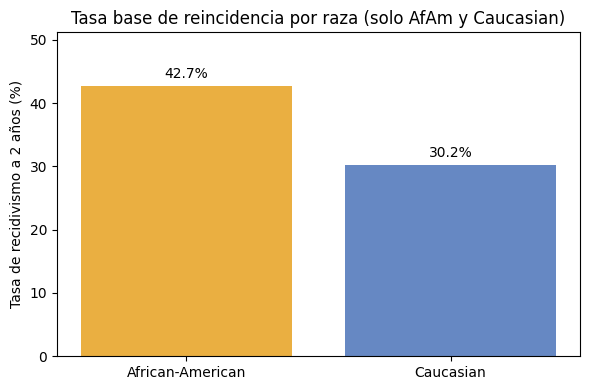

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    tasa_base["Raza"],
    tasa_base["Tasa de recidivismo"],
    color=["#eaaf41", "#6688c3"]
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_ylabel("Tasa de recidivismo a 2 años (%)")
ax.set_title("Tasa base de reincidencia por raza (solo AfAm y Caucasian)")
ax.set_ylim(0, max(tasa_base["Tasa de recidivismo"]) * 1.2)

plt.tight_layout()
plt.show()

Este gráfico muestra que los acusados African-American presentan una tasa base de reincidencia a dos años del 42.7%, frente al 30.2% de los Caucasian. Con tasas base distintas y un único umbral de decisión, no es posible tener simultáneamente FPR igual, FNR igual y precision igual entre grupos (Chouldechova, 2017): cumplir uno de estos criterios implica necesariamente sacrificar los otros. Vale la pena tener esto en cuenta al interpretar las disparidades observadas en las distribuciones de error.

***Chouldechova (2017): https://arxiv.org/pdf/1610.07524***

---

## **EVALUACIÓN DE LOS PUNTAJES DE COMPAS**

Para evaluar los puntajes de Compas, nos enfocaremos en 3 métricas diferentes

| Métrica                | Qué evalúa                                                                                                                                                                                                                    |
| ---------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **AUC**                | Qué tan bien el modelo distingue entre reincidentes y no reincidentes, es decir, la probabilidad de que asigne mayor riesgo (determinado por el decile_score) a un reincidente que a un no reincidente, independientemente de cualquier umbral.                 |
| **Precision / Recall** | La calidad de las decisiones binarias al aplicar un umbral: *precision* mide cuán fiable es la etiqueta de "high-risk", mientras que *recall* mide qué proporción de los reincidentes reales es correctamente identificada. |
| **Calibration**        | Si las probabilidades predichas por el modelo reflejan tasas reales de reincidencia, es decir, si a un riesgo estimado del X% corresponde aproximadamente una reincidencia del X%.                                            |



### AUC ROC (área bajo la curva de característica operativa del receptor): https://en.wikipedia.org/wiki/Receiver_operating_characteristic

Para intentar determinar la capacidad del score de COMPAS (definido por el "decile_score") para rankear correctamente a las personas según su riesgo de reincidencia en dos años, utilizamos el AUC, definido en este caso como la probabilidad de que una persona reincidente reciba una puntuación más alta que una persona no reincidente.

El AUC (área bajo la curva ROC) mide la eficacia con la que un sistema de puntuación clasifica los casos positivos por encima de los negativos comparando todos los pares positivo-negativo y calculando la proporción de veces que el caso positivo recibe una puntuación más alta que el caso negativo, lo que equivale al área bajo la curva de la tasa de verdaderos positivos frente a la tasa de falsos positivos en todos los umbrales posibles.
- un caso positivo es una persona que fue detenida nuevamente en un plazo de dos años (two_year_recid = 1)
- un caso negativo es una persona que no fue detenida nuevamente en un plazo de dos años (two_year_recid = 0)

Para interpretar los valores del AUC, podemos

- 0.5 = Clasificación aleatoria, igual lanzar una moneda.
- 0.5-0.7 = Clasificación deficiente, no mucho mejor que lanzar una moneda al aire.
- 0.7-0.8 = Clasificación aceptable.
- 0.8-0.9 = Clasificación excelente.
- Sobre 0.9 = Clasificación sobresaliente.

Fuentes:
* https://darwin.unmc.edu/dxtests/roc3.htm
* https://www.researchgate.net/post/What-is-the-value-of-the-area-under-the-roc-curve-AUC-to-conclude-that-a-classifier-is-excellent

In [ ]:
compas_scores_two_years_eval["decile_score"] = pd.to_numeric(compas_scores_two_years_eval["decile_score"], errors="coerce")
compas_scores_two_years_eval["two_year_recid"] = pd.to_numeric(compas_scores_two_years_eval["two_year_recid"], errors="coerce")
compas_scores_two_years_eval = compas_scores_two_years_eval[compas_scores_two_years_eval["two_year_recid"].isin([0, 1])]

auc_score = roc_auc_score(compas_scores_two_years_eval["two_year_recid"], compas_scores_two_years_eval["decile_score"])
print(f"AUC General: {auc_score:.4f}")

AUC General: 0.7022


Obtenemos un AUC general de ~0.70. Grafiquémoslo para analizarlo visualmente.

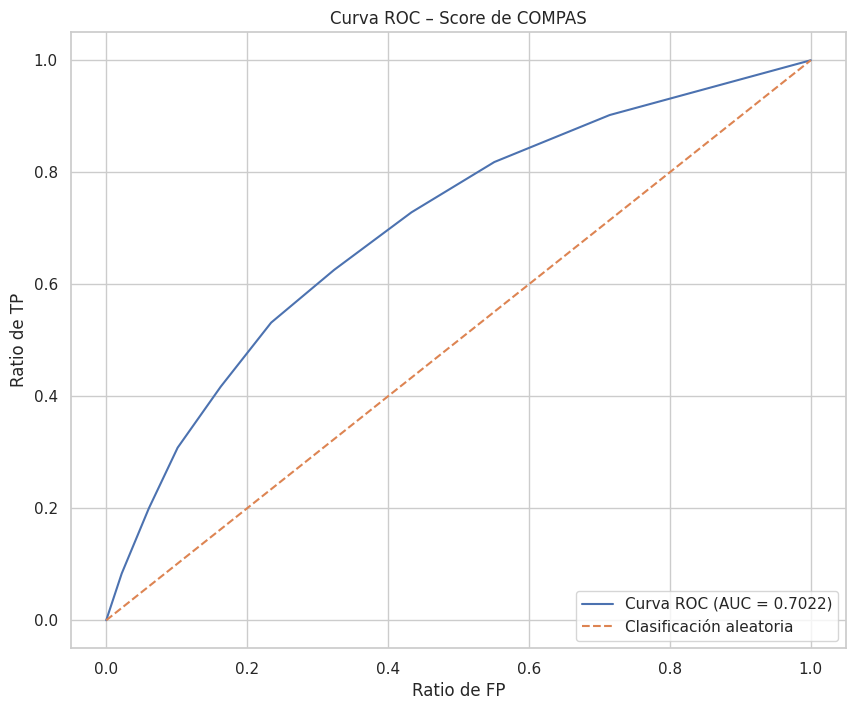

In [ ]:
y_recid = compas_scores_two_years_eval["two_year_recid"]
y_score = compas_scores_two_years_eval["decile_score"]
fpr, tpr, _ = roc_curve(y_recid, y_score) # "_" porque no usamos umbral
auc = roc_auc_score(y_recid, y_score)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f"Curva ROC (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificación aleatoria")
plt.xlabel("Ratio de FP")
plt.ylabel("Ratio de TP")
plt.title("Curva ROC – Score de COMPAS")
plt.legend(loc="lower right")
plt.show()

Aquí, en general, se obtiene un AUC de **0.702**, lo que significa que cuando se elige al azar a una persona que ha sido arrestada de nuevo en un plazo de dos años y a otra que no lo ha sido, la puntuación COMPAS asigna una puntuación de riesgo más alta a la persona detenida de nuevo en aproximadamente el 70,22 % de los casos.
En términos sencillos: COMPAS es mejor que el azar a la hora de clasificar a las personas por riesgo, pero la separación entre reincidentes y no reincidentes es solo moderada, con un solapamiento sustancial entre los dos grupos.

- https://www.statology.org/what-is-a-good-auc-score/

#### Ahora calculemos esto por grupos demográficos. Vayamos primero con la etnia.

In [ ]:
campos_etnia = ["race", "decile_score", "two_year_recid"]
campos_relevantes_etnia = compas_scores_two_years_eval[campos_etnia].dropna()
campos_relevantes_etnia = campos_relevantes_etnia[campos_relevantes_etnia["two_year_recid"].isin([0, 1])]

resultado = []
for etnia, g in campos_relevantes_etnia.groupby("race"):
    if g["two_year_recid"].nunique() < 2: #si en un grupo solo hay personas reincidentes o no reincidentes, no puede hacerse el análisis.
        resultado.append({
            "Etnia": etnia,
            "Registros": len(g),
            "recid_rate": g["two_year_recid"].mean(),
            "AUC": None,
        })
        continue

    auc_race = roc_auc_score(g["two_year_recid"], g["decile_score"])
    resultado.append({
        "Etnia": etnia,
        "Registros": len(g),
        "Mediana de recid_rate": round(g["two_year_recid"].mean(),3),
        "AUC": round(auc_race, 3)
    })

auc_by_race_group = pd.DataFrame(resultado).sort_values("Registros", ascending=False)
auc_by_race_group

,Etnia,Registros,Mediana de recid_rate,AUC
0,African-American,3127,0.427,0.694
2,Caucasian,2128,0.302,0.684
3,Hispanic,559,0.279,0.646
5,Other,339,0.283,0.689
1,Asian,28,0.179,0.922
4,Native American,14,0.429,0.854


Grafiquémoslo para analizarlo visualmente.

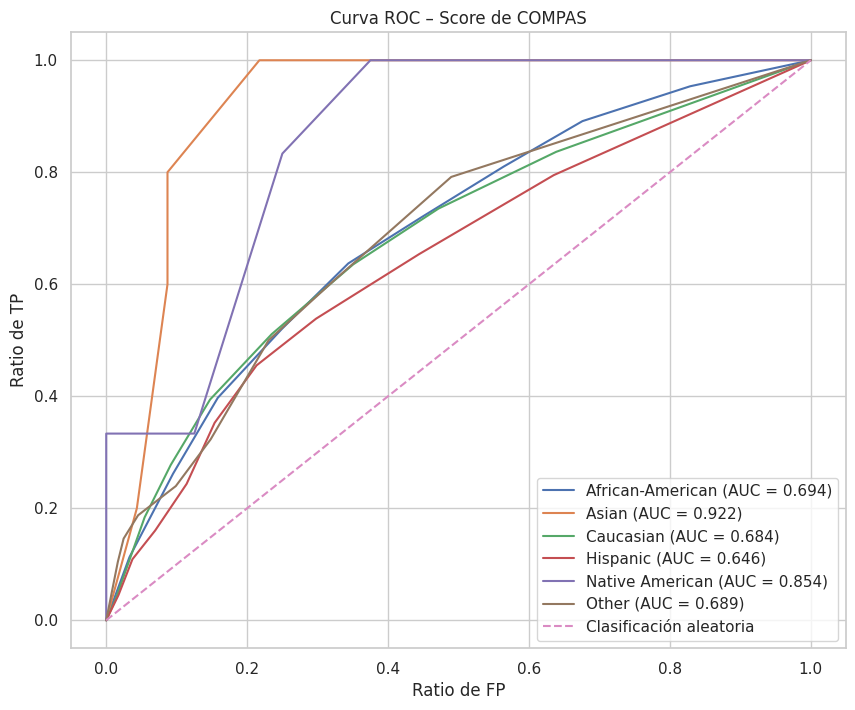

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))

for etnia, g in campos_relevantes_etnia.groupby("race"):
    if g["two_year_recid"].nunique() < 2:
        continue

    y_recid_race = g["two_year_recid"]
    y_score_race = g["decile_score"]

    fpr_race, tpr_race, _ = roc_curve(y_recid_race, y_score_race) # "_" porque no usamos umbral, no aporta información.
    auc_race = roc_auc_score(y_recid_race, y_score_race)

    plt.plot(fpr_race, tpr_race, label=f"{etnia} (AUC = {auc_race:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificación aleatoria")
plt.xlabel("Ratio de FP")
plt.ylabel("Ratio de TP")
plt.title("Curva ROC – Score de COMPAS")
plt.legend(loc="lower right")
plt.show()

Al estratificar por etnia, los deciles de COMPAS muestran una capacidad discriminatoria comparable y más baja que el AUC general (0.702) para los grupos "African-America", "Caucasian", "Hispanic" y "Other" (AUC ≈ **0,65-0,70**).

Los valores de AUC que observamos para los grupos "Asian" y "Native American", si bien son bastante altos, no deberían interpretarse como una mejora en el rendimiento predictivo, ya que estos grupos contienen muestras muy pequeñas (n = 28 y n = 14, respectivamente), lo que hace que las estimaciones sean estadísticamente inestables.

Por ello, el análisis se centra en los grupos "African-American" y "Caucasian",
que representan el 85% de la población.

#### Hagámoslo una vez más, esta vez con la edad

In [ ]:
campos_edad = ["age_cat", "decile_score", "two_year_recid"]
campos_relevantes_edad = compas_scores_two_years_eval[campos_edad].dropna()
campos_relevantes_edad = campos_relevantes_edad[campos_relevantes_edad["two_year_recid"].isin([0, 1])]

resultado = []
for edad, g in campos_relevantes_edad.groupby("age_cat"):
    if g["two_year_recid"].nunique() < 2:
        resultado.append({
            "Edad": edad,
            "Registros": len(g),
            "recid_rate": g["two_year_recid"].mean(),
            "AUC": None,
        })
        continue

    auc_edad = roc_auc_score(g["two_year_recid"], g["decile_score"])
    resultado.append({
        "Edad": edad,
        "Registros": len(g),
        "Mediana de recid_rate": round(g["two_year_recid"].mean(),3),
        "AUC": round(auc_edad,3)
    })

auc_by_edad = pd.DataFrame(resultado).sort_values("Registros", ascending=False)
auc_by_edad

,Edad,Registros,Mediana de recid_rate,AUC
0,25 - 45,3533,0.372,0.693
1,Greater than 45,1425,0.246,0.685
2,Less than 25,1237,0.466,0.657


Grafiquémoslo para analizarlo visualmente.

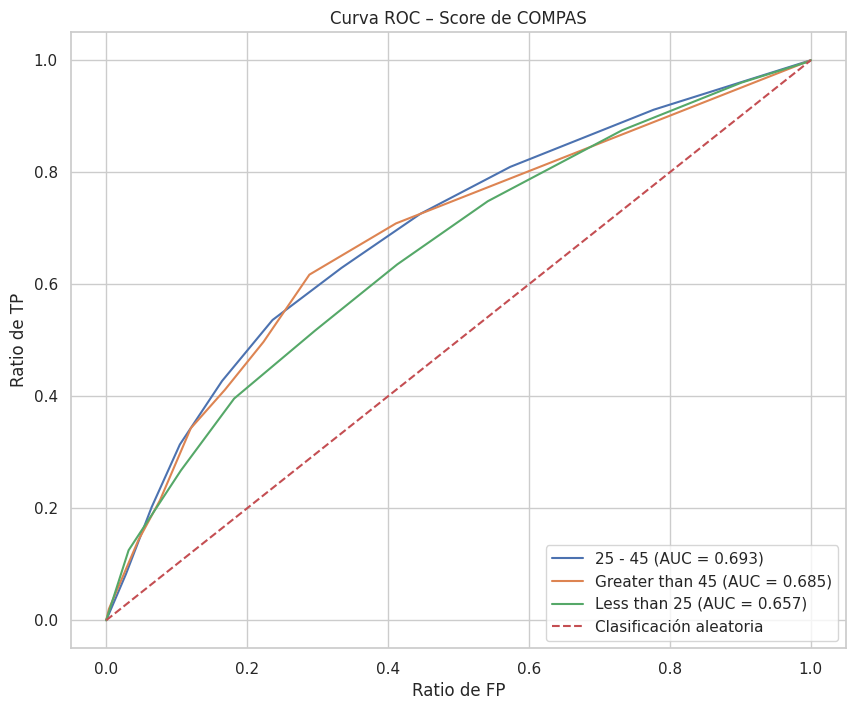

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))

for edad, g in campos_relevantes_edad.groupby("age_cat"):
    if g["two_year_recid"].nunique() < 2:
        continue

    y_recid_edad = g["two_year_recid"]
    y_score_edad = g["decile_score"]

    fpr_edad, tpr_edad, _ = roc_curve(y_recid_edad, y_score_edad) # "_" porque no usamos umbral, no aporta información.
    auc_edad = roc_auc_score(y_recid_edad, y_score_edad)

    plt.plot(fpr_edad, tpr_edad, label=f"{edad} (AUC = {auc_edad:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificación aleatoria")
plt.xlabel("Ratio de FP")
plt.ylabel("Ratio de TP")
plt.title("Curva ROC – Score de COMPAS")
plt.legend(loc="lower right")
plt.show()

Al estratificar por edad, el AUC dentro de cada grupo es inferior al AUC general (0.702), lo que indica que el decile_score de COMPAS discrimina peor cuando se evalúa por separado dentro de cada franja de edad. Esto sugiere que parte de la capacidad predictiva del score proviene precisamente de capturar diferencias entre grupos de edad, no solo dentro de ellos.

#### Por último, repitamos el cálculo, pero con el último factor demográfico restante: el género

In [ ]:
campos_genero = ["sex", "decile_score", "two_year_recid"]
campos_relevantes_genero = compas_scores_two_years_eval[campos_genero].dropna()
campos_relevantes_genero = campos_relevantes_genero[campos_relevantes_genero["two_year_recid"].isin([0, 1])]

resultado = []
for genero, g in campos_relevantes_genero.groupby("sex"):
    if g["two_year_recid"].nunique() < 2: #si en un grupo solo hay personas reincidentes o no reincidentes, no puede hacerse el análisis.
        resultado.append({
            "Genero": genero,
            "Registros": len(g),
            "recid_rate": g["two_year_recid"].mean(),
            "AUC": None,
        })
        continue

    auc_sex = roc_auc_score(g["two_year_recid"], g["decile_score"])
    resultado.append({
        "Genero": genero,
        "Registros": len(g),
        "Mediana de recid_rate": round(g["two_year_recid"].mean(),3),
        "AUC": round(auc_sex, 3)
    })

auc_by_sex_group = pd.DataFrame(resultado).sort_values("Registros", ascending=False)
auc_by_sex_group

,Genero,Registros,Mediana de recid_rate,AUC
1,Male,4984,0.386,0.704
0,Female,1211,0.260,0.683


Grafiquemos para verlo visualmente

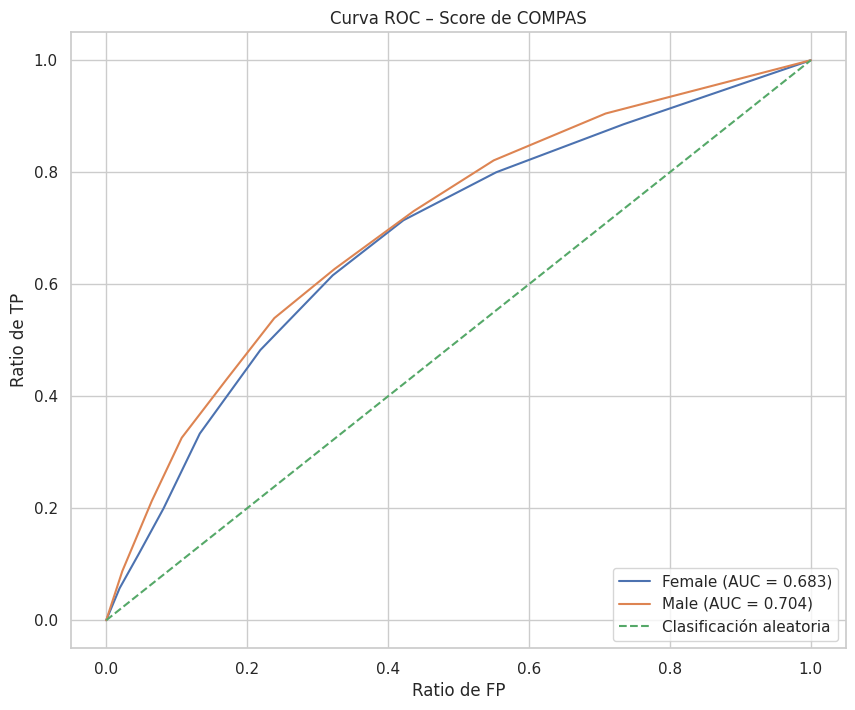

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))

for genero, g in campos_relevantes_genero.groupby("sex"):
    if g["two_year_recid"].nunique() < 2:
        continue

    y_recid_genero = g["two_year_recid"]
    y_score_genero = g["decile_score"]

    fpr_genero, tpr_genero, _ = roc_curve(y_recid_genero, y_score_genero) # "_" porque no usamos umbral, no aporta información.
    auc_genero = roc_auc_score(y_recid_genero, y_score_genero)

    plt.plot(fpr_genero, tpr_genero, label=f"{genero} (AUC = {auc_genero:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificación aleatoria")
plt.xlabel("Ratio de FP")
plt.ylabel("Ratio de TP")
plt.title("Curva ROC – Score de COMPAS")
plt.legend(loc="lower right")
plt.show()

Al estratificar por género, el AUC de Male (0.704) es prácticamente idéntico al AUC general (0.702), mientras que Female muestra un rendimiento ligeramente inferior (0.683). En ambos casos, la capacidad discriminatoria es comparable entre grupos.

La similitud de los valores AUC entre los distintos indicadores demográficos (etnia, edad y género) indica un rendimiento global comparable de COMPAS. Sin embargo, esto no implica que los factores demográficos sean irrelevantes para las predicciones o las consecuencias del sistema. Dado que el AUC es similar en todos los grupos, a continuación examinamos si COMPAS produce diferentes tasas de error (*falsos positivos* y *falsos negativos*) entre grupos demográficos cuando se utiliza como regla de decisión.

Esto nos permitirá evaluar a cuántos reincidentes COMPAS detecta realmente, cuántos no reincidentes se les marca erróneamente, y donde se concentran los falsos positivos/negativos.

### **Precision/Recall**

Comencemos evaluando una confusion matrix para determinar los FP, FN, TP y TN (https://en.wikipedia.org/wiki/Confusion_matrix)

Antes usamos AUC, que nos permitía responder a la pregunta "¿COMPAS clasifica de forma razonablemente correcta?". Pero COMPAS no se utiliza como herramienta de clasificación en la práctica. Se utiliza de la siguiente manera:

- «Alto riesgo: supervisión más estricta/detención»
- «Bajo riesgo: libertad/indulgencia»

Una matriz de confusión representa una tabla con dos filas y dos columnas que reporta el número de verdaderos positivos, falsos negativos, falsos positivos y verdaderos negativos, lo cual:
- Permite identificar patrones de error específicos por grupo demográfico
- Revela disparidades en falsos positivos/negativos que el AUC global no muestra

Es decir, una matriz de confusión muestra el éxito y el fracaso de COMPAS cuando sus puntuaciones de riesgo se convierten en decisiones reales, contando las clasificaciones correctas e incorrectas de alto y bajo riesgo.


| Término | Significado|
|---------|---------------------------|
| Verdadero positivo (TP) | La persona fue arrestada nuevamente y COMPAS la etiquetó como de alto riesgo |
| Falso positivo (FP) | La persona NO fue arrestada nuevamente pero COMPAS la etiquetó como de alto riesgo |
| Verdadero negativo (TN) | La persona NO fue arrestada nuevamente y COMPAS la etiquetó como de bajo riesgo |
| Falso negativo (FN) | La persona SÍ fue arrestada nuevamente pero COMPAS la etiquetó como de bajo riesgo |

Fuentes:
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html#sklearn.metrics.confusion_matrix
- https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html

### ***NOTA IMPORTANTE***

El umbral seleccionado para clasificar a un individuo como "de riesgo" es decile_score ≥ 5, que corresponde a las categorías "Medium Risk" y "High Risk" definidas por el propio sistema COMPAS (scores 5-10). Esta decisión sigue la metodología empleada por ProPublica en su análisis original, lo que permite que los resultados de precision, recall y FPR sean directamente comparables con los publicados en dicho estudio.

Nota: El umbral decile_score ≥ 5 es una convención adoptada para comparabilidad con ProPublica, no una verdad objetiva del sistema; otros umbrales producirían resultados distintos.

In [ ]:
compas_scores_two_years_compas_CF_eval = compas_scores_two_years_eval.copy()

threshold = 5

y_recid_cf = compas_scores_two_years_compas_CF_eval["two_year_recid"].astype(int)
y_pred_cf = (compas_scores_two_years_compas_CF_eval["decile_score"] >= threshold).astype(int)

tabla_confusion = confusion_matrix(y_recid_cf, y_pred_cf, labels=[0, 1])
tn, fp, fn, tp = tabla_confusion.ravel()

print(f"Verdaderos negativos: {tn}\r\nFalsos positivos: {fp}\r\nFalsos negativos: {fn}\r\nVerdaderos positivos: {tp}")


Verdaderos negativos: 2676
Falsos positivos: 1280
Falsos negativos: 838
Verdaderos positivos: 1401


In [ ]:
#Normalicemos los resultados
tabla_confusion_n = np.round(confusion_matrix(y_recid_cf, y_pred_cf, labels=[0, 1],normalize="all"),4)
tn_n, fp_n, fn_n, tp_n = tabla_confusion_n.ravel()
print(f"Verdaderos negativos: {tn_n*100:.2f}\r\nFalsos positivos: {fp_n*100:.2f}\r\nFalsos negativos: {fn_n*100:.2f}\r\nVerdaderos positivos: {tp_n*100:.2f}")

Verdaderos negativos: 43.20
Falsos positivos: 20.66
Falsos negativos: 13.53
Verdaderos positivos: 22.62


Grafiquemos el resultado para hacerlo más claro:

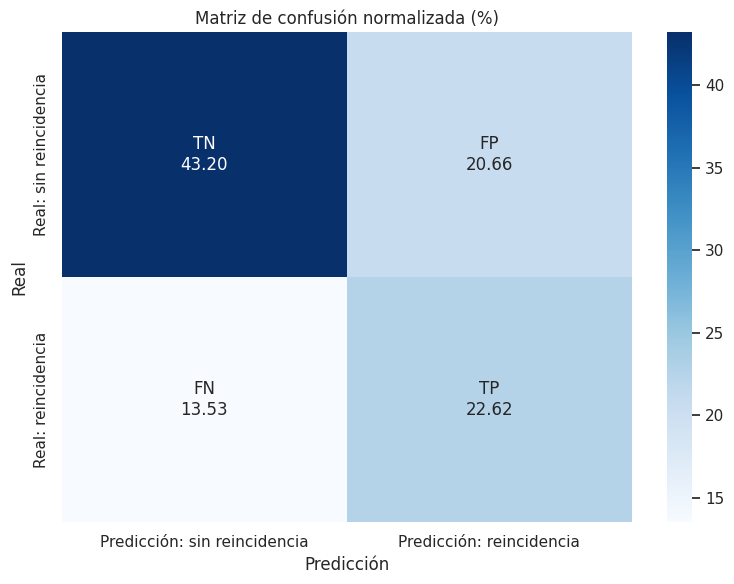

In [ ]:
etiquetas = np.array([
[f"TN\n{tn_n*100:.2f}", f"FP\n{fp_n*100:.2f}"],
[f"FN\n{fn_n*100:.2f}", f"TP\n{tp_n*100:.2f}"]
])

plt.figure(figsize=(8, 6))
sns.heatmap(
tabla_confusion_n*100,
annot=etiquetas,
fmt="",
cmap="Blues",
xticklabels=["Predicción: sin reincidencia", "Predicción: reincidencia"],
yticklabels=["Real: sin reincidencia", "Real: reincidencia"]
)


plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión normalizada (%)")
plt.tight_layout()
plt.show()

La matriz de confusión muestra que, globalmente, COMPAS clasifica correctamente como bajo riesgo al 67.6% de los no reincidentes (TN: 43.2% del total), pero etiqueta erróneamente como "de riesgo" al 32.4% restante (FP: 20.7% del total). Por otro lado, deja sin identificar a cerca del 37% de las personas que sí reincidirán (FN: 13.5% del total). Este patrón refleja un perfil de decisión agresivo: el sistema comete más errores por exceso que por defecto y prefiere sobreclasificar el riesgo antes que dejarlo pasar.

### Ahora veamos cómo se comparan los resultados entre poblaciones. Comencemos calculando la matriz de confusión de las poblaciones más representativas de la variable demográfica "race": "African-American" y "Caucasian".

In [ ]:
# Valores absolutos

threshold = 5

# Comencemos con la población "African-American"
compas_scores_two_years_af_am = compas_scores_two_years_eval[compas_scores_two_years_eval["race"] == "African-American"].copy()
y_recid_cf_af_am = compas_scores_two_years_af_am["two_year_recid"].astype(int)
y_pred_cf_af_am = (compas_scores_two_years_af_am["decile_score"] >= threshold).astype(int)
tabla_confusion_af_am = confusion_matrix(y_recid_cf_af_am, y_pred_cf_af_am, labels=[0, 1])
tn_af_am, fp_af_am, fn_af_am, tp_af_am = tabla_confusion_af_am.ravel()

#Ahora, con la población "Caucasian"
compas_scores_two_years_caucasian = compas_scores_two_years_eval[compas_scores_two_years_eval["race"] == "Caucasian"].copy()
y_recid_cf_caucasian = compas_scores_two_years_caucasian["two_year_recid"].astype(int)
y_pred_cf_caucasian = (compas_scores_two_years_caucasian["decile_score"] >= threshold).astype(int)
tabla_confusion_caucasian = confusion_matrix(y_recid_cf_caucasian, y_pred_cf_caucasian, labels=[0, 1])
tn_caucasian, fp_caucasian, fn_caucasian, tp_caucasian = tabla_confusion_caucasian.ravel()

# Veamos la comparación de los valores de matrices de confusión por los grupos étnicos más grandes
comparacion_matriz_etnias = pd.DataFrame({
"Raza": ["Caucasian", "African-American"],
"TN": [tn_caucasian, tn_af_am],
"FP": [fp_caucasian, fp_af_am],
"FN": [fn_caucasian, fn_af_am],
"TP": [tp_caucasian, tp_af_am],
})

comparacion_matriz_etnias = comparacion_matriz_etnias.set_index("Raza")
comparacion_matriz_etnias

,TN,FP,FN,TP
Raza,,,,
Caucasian,1137,349,314,328
African-American,989,804,373,961


In [ ]:
# Valores normalizados

threshold = 5

# Comencemos con la población "African-American"
tabla_confusion_af_am_norm = (np.round(confusion_matrix(y_recid_cf_af_am, y_pred_cf_af_am, labels=[0, 1],normalize="all"),4))*100
tn_af_am_norm, fp_af_am_norm, fn_af_am_norm, tp_af_am_norm = tabla_confusion_af_am_norm.ravel()

#Ahora, con la población "Caucasian"
tabla_confusion_caucasian_norm = (np.round(confusion_matrix(y_recid_cf_caucasian, y_pred_cf_caucasian, labels=[0, 1],normalize="all"),4))*100
tn_caucasian_norm, fp_caucasian_norm, fn_caucasian_norm, tp_caucasian_norm = tabla_confusion_caucasian_norm.ravel()

# Veamos la comparación de los valores de matrices de confusión por los grupos étnicos más grandes
comparacion_matriz_etnias_norm = pd.DataFrame({
"Raza": ["Caucasian", "African-American"],
"TN": [tn_caucasian_norm, tn_af_am_norm],
"FP": [fp_caucasian_norm, fp_af_am_norm],
"FN": [fn_caucasian_norm, fn_af_am_norm],
"TP": [tp_caucasian_norm, tp_af_am_norm],
})

comparacion_matriz_etnias_norm = comparacion_matriz_etnias_norm.set_index("Raza")
comparacion_matriz_etnias_norm

,TN,FP,FN,TP
Raza,,,,
Caucasian,53.43,16.40,14.76,15.41
African-American,31.63,25.71,11.93,30.73


A simple vista, podemos ver que existe disparidad entre ambas etnias. Veámosla gráficamente.

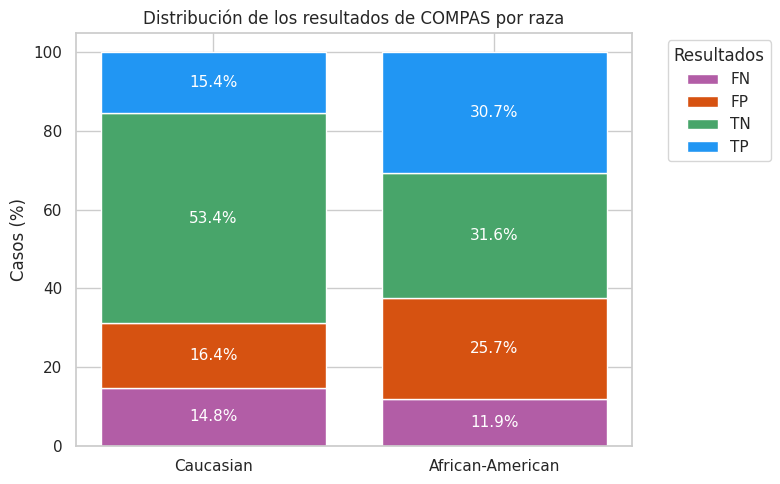

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

bottom = [0] * len(comparacion_matriz_etnias_norm)

colors = {
    "TN": "#48a56a",
    "FP": "#d65211",
    "FN": "#b25da6",
    "TP": "#2196F3",
}

for col in ["FN", "FP", "TN", "TP"]:
    values = comparacion_matriz_etnias_norm[col]
    bars = ax.bar(
        comparacion_matriz_etnias_norm.index,
        values,
        bottom=bottom,
        label=col,
        color=colors[col]
    )

    for bar, val in zip(bars, values):
        if val > 1:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%",
                ha="center",
                va="center",
                fontsize=11,
                color="white"
            )

    bottom = [b + v for b, v in zip(bottom, values)]

ax.set_ylabel("Casos (%)")
ax.set_title("Distribución de los resultados de COMPAS por raza")
ax.legend(title="Resultados", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

Tomando solo lo que puede considerarse errores en la predicción de COMPAS, vemos lo siguiente.

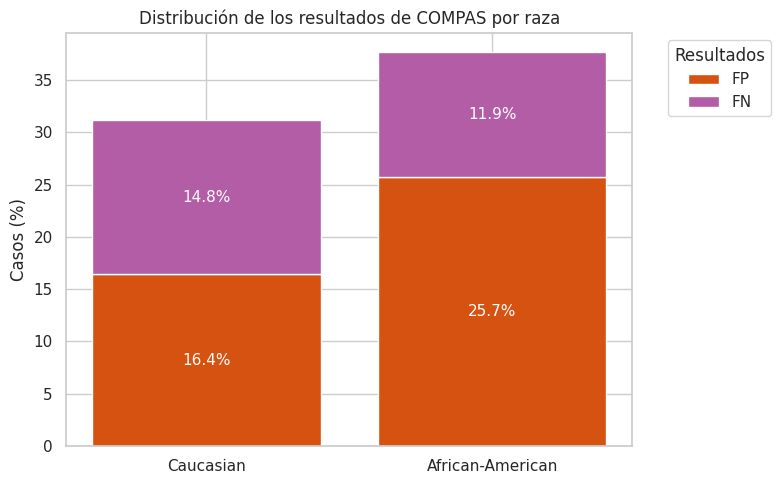

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

bottom = [0] * len(comparacion_matriz_etnias_norm)

colors = {
    "FP": "#d65211",
    "FN": "#b25da6",
}

for col in ["FP", "FN"]:
    values = comparacion_matriz_etnias_norm[col]
    bars = ax.bar(
        comparacion_matriz_etnias_norm.index,
        values,
        bottom=bottom,
        label=col,
        color=colors[col]
    )

    for bar, val in zip(bars, values):
        if val > 1:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%",
                ha="center",
                va="center",
                fontsize=11,
                color="white"
            )

    bottom = [b + v for b, v in zip(bottom, values)]

ax.set_ylabel("Casos (%)")
ax.set_title("Distribución de los resultados de COMPAS por raza")
ax.legend(title="Resultados", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

Recordemos que los deciles de COMPAS muestran una capacidad predictiva comparable y más baja que el AUC general (0.702) para los grupos "African-American" y "Caucasian" (0.69 y 0.68 respectivamente).

Sin embargo, comparando ambos grupos con el mismo umbral COMPAS (≥ 5, Medium + High Risk), vemos que, mientras que las tasas de falsos negativos son relativamente bajas entre los acusados "African-American" y los acusados "Caucasian" (una diferencia de 2.8 puntos porcentuales: 11.9% vs 14.7%), los primeros experimentan tasas de falsos positivos sustancialmente más altas que los otros (9.3 puntos porcentuales: 25.7% vs 16.4%), lo que indica cargas de error desiguales a pesar de un rendimiento predictivo general comparable.

Esto, a su vez, puede ser señal de que exista un sesgo en cómo el puntaje de COMPAS se traduce en decisiones reales según el grupo racial. En este caso, si se busca igualdad predictiva, las tasas de falsos positivos deben
ser similares entre grupos.

#### ***Ahora usemos esto para determinar el Precision y el Recall***

Mientras que los recuentos de falsos positivos y falsos negativos proporcionan una visión directa de los tipos de error, precision (precisión) y recall (sensibilidad) ofrecen un resumen más claro y más interpretable de estos errores al comparar el rendimiento de COMPAS entre los distintos grupos demográficos.

En pocas palabras:
- Precision: De todas las predicciones positivas que hizo el modelo, ¿cuántas eran correctas?
- Recall: De todos los casos positivos reales, ¿cuántos detectó el modelo?

Nos enfocaremos, nuevamente, en los grupos African-American y Caucasian, ya que:
- El tamaño de la población del resto de etnias es demasiado pequeño para extraer conclusiones sólidas.
- Los valores de precision y recall aquí son ruido estadístico.

In [ ]:
compas_scores_two_years_recpre = compas_scores_two_years_eval[compas_scores_two_years_eval["race"].isin(["African-American","Caucasian"])].copy()

In [ ]:
valores = []

for race, g in compas_scores_two_years_recpre.groupby("race"):
    g = g[["decile_score", "two_year_recid"]].dropna()
    g = g[g["two_year_recid"].isin([0, 1])]
    if len(g) == 0:
        continue

    threshold = 5
    y_real_recpre = g["two_year_recid"].astype(int)
    y_pred_recpre = (g["decile_score"] >= threshold).astype(int)

    tn_recpre, fp_recpre, fn_recpre, tp_recpre = confusion_matrix(y_real_recpre, y_pred_recpre, labels=[0, 1]).ravel()
    precision = tp_recpre / (tp_recpre + fp_recpre) if (tp_recpre + fp_recpre) else None
    recall = tp_recpre / (tp_recpre + fn_recpre) if (tp_recpre + fn_recpre) else None

    valores.append({
        "Etnia": race,
        "Población": len(g),
        "Precision": precision,
        "Recall": recall,
        "TP": tp_recpre, "FP": fp_recpre, "FN": fn_recpre, "TN": tn_recpre
    })

precision_recall_por_raza = pd.DataFrame(valores).sort_values("Población", ascending=False)
precision_recall_por_raza


,Etnia,Población,Precision,Recall,TP,FP,FN,TN
0,African-American,3127,0.544476,0.720390,961,804,373,989
1,Caucasian,2128,0.484490,0.510903,328,349,314,1137


Veámoslo gráficamente

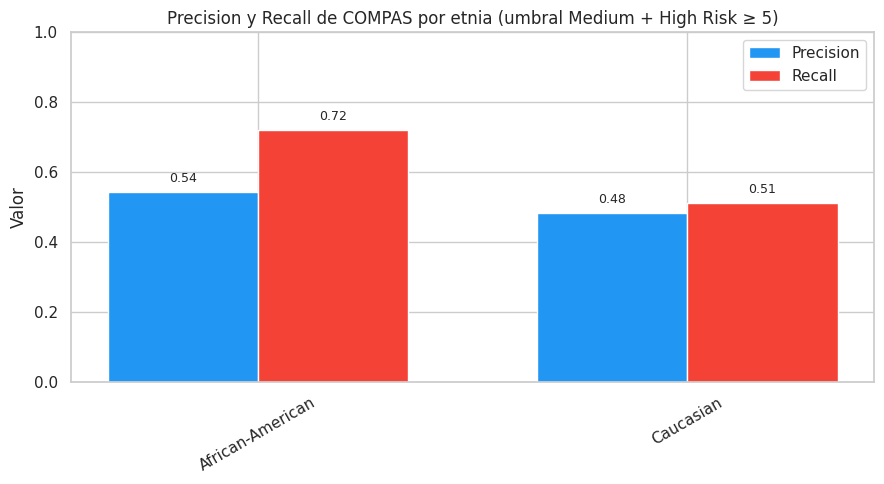

In [ ]:
grafico_recpre = precision_recall_por_raza.copy()
grafico_recpre = grafico_recpre.sort_values("Población", ascending=False)

etiquetas = grafico_recpre["Etnia"]
x = np.arange(len(etiquetas))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars_precision = ax.bar(
    x - width/2,
    grafico_recpre["Precision"],
    width,
    label="Precision",
    color="#2196F3"
)

bars_recall = ax.bar(
    x + width/2,
    grafico_recpre["Recall"],
    width,
    label="Recall",
    color="#F44336"
)

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        if height is not None:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.02,
                f"{height:.2f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

add_labels(bars_precision)
add_labels(bars_recall)

ax.set_ylabel("Valor")
ax.set_title("Precision y Recall de COMPAS por etnia (umbral Medium + High Risk ≥ 5)")
ax.set_xticks(x)
ax.set_xticklabels(etiquetas, rotation=30)
ax.legend()

ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

Los resultados indican que, aunque COMPAS presenta una capacidad de clasificación similar entre los grupos African-American y Caucasian (AUC comparable), el desempeño del sistema difiere al aplicar un umbral ≥ 5 (Medium + High Risk). En particular, la etiqueta de riesgo presenta un recall sustancialmente mayor para los acusados African-American (0.72) que para los acusados Caucasian (0.51), quienes quedan sin identificar en casi la mitad de los casos de reincidencia real.

***En otras palabras:***
COMPAS aplica el umbral de forma mucho más agresiva con "African-Americans": marca como "de riesgo" (sobre el decile 5) al 56% de ese grupo (1765 de 3127), frente al 32% del grupo Caucasian (677 de 2128). Esa agresividad produce un recall notablemente más alto, pero apenas mejora la precision (0.54 vs 0.48). Dicho de otro modo, el sistema clasifica a muchos más African-Americans como "de riesgo" sin ganar apenas fiabilidad predictiva a cambio, lo que se traduce principalmente en más falsos positivos (804 de African-American contra 349 de Caucasian).

Es decir, el sistema no es igualmente estricto con ambos grupos bajo el mismo umbral numérico. Un Caucasian y un African-American con el mismo score reciben la misma etiqueta, pero la probabilidad real de reincidencia que hay detrás de ese score es distinta entre grupos, lo que produce estos resultados asimétricos.

Estas diferencias reflejan principalmente las disparidades en las tasas base de reincidencia y muestran que una capacidad predictiva similar en términos de AUC no garantiza un desempeño equivalente en términos de precisión y cobertura del riesgo cuando se aplica un umbral uniforme.

### Calibration (https://scikit-learn.org/stable/modules/calibration.html)
La calibration (calibración) permite responder a la siguiente pregunta: cuando el modelo predice una probabilidad de reincidencia del X%, ¿aproximadamente X% de esas personas reinciden realmente?
Por ejemplo, para todos los individuos con una predicción de probabilidad de reincidencia del 0.30 ¿30% reincide en dos años?

Un score está bien calibrado si cumple esta idea básica "Personas con mayor puntuación tienen, en promedio, mayor tasa real de reincidencia que personas con menor puntuación." Esto porque personas con menor riesgo de reincidir (menor decile_score) deberían, lógicamente, reincidir menos.

Evaluemos esta métrica.

In [ ]:
compas_scores_two_years_eval_calibration = compas_scores_two_years_eval.copy()

In [ ]:
tabla_calibration = (
    compas_scores_two_years_eval_calibration.groupby("decile_score")["two_year_recid"]
      .agg(recuento="count", tasa_observada="mean")
      .reset_index()
      .sort_values("decile_score")
)

tabla_calibration["pct_tasa_observada"] = (tabla_calibration["tasa_observada"] * 100).round(2)
tabla_calibration


,decile_score,recuento,tasa_observada,pct_tasa_observada
0,1,1348,0.162463,16.25
1,2,836,0.224880,22.49
2,3,666,0.301802,30.18
3,4,664,0.346386,34.64
4,5,565,0.373451,37.35
5,6,539,0.474954,47.50
6,7,486,0.502058,50.21
7,8,405,0.600000,60.00
8,9,412,0.631068,63.11
9,10,274,0.682482,68.25


Veámoslo gráficamente

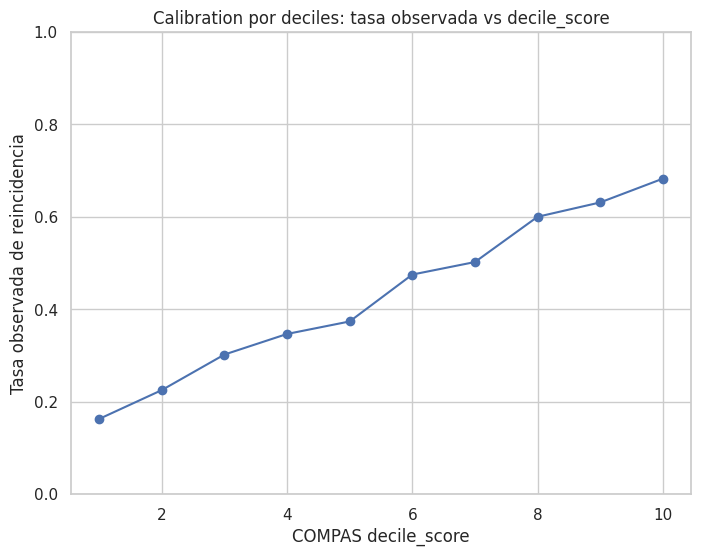

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(tabla_calibration["decile_score"], tabla_calibration["tasa_observada"], marker="o")
plt.xlabel("COMPAS decile_score")
plt.ylabel("Tasa observada de reincidencia")
plt.title("Calibration por deciles: tasa observada vs decile_score")
plt.grid(True)
plt.ylim(0, 1)
plt.show()


Para cada decile_score, "tasa_observada" es la proporción real de personas que reinciden entre quienes tienen ese mismo score. Es decir, personas con mayor puntuación tienen, en promedio, mayor tasa real de reincidencia que personas con menor puntuación.

Los resultados muestran que el decile_score de COMPAS está bien calibrado en sentido ordinal, ya que valores más altos del score corresponden sistemáticamente a mayores tasas observadas de reincidencia, aunque esto no garantiza decisiones equitativas bajo un umbral común (decile_score >=8 o "High risk")

Hagamos la calibration por grupo, en el que mostremos el porcentaje de tasa observada por raza:

In [ ]:
calib_por_raza = (
    compas_scores_two_years_eval_calibration[compas_scores_two_years_eval_calibration["race"].isin(["Caucasian", "African-American"])]
      .groupby(["race", "decile_score"])["two_year_recid"]
      .agg(recuento_raza="count", tasa_observada_raza="mean")
      .reset_index()
      .sort_values(["race","decile_score"])
)
calib_por_raza["pct_tasa_observada"] = (calib_por_raza["tasa_observada_raza"] * 100).round(2)
calib_por_raza_wide = (calib_por_raza.pivot(index="decile_score", columns="race", values="pct_tasa_observada"))
calib_por_raza_wide["diferencia entre tasas"] = abs(calib_por_raza_wide["African-American"]-calib_por_raza_wide["Caucasian"])
calib_por_raza_wide

race,African-American,Caucasian,diferencia entre tasas
decile_score,,,
1,16.80,16.36,0.44
2,23.25,20.77,2.48
3,35.06,26.23,8.83
4,36.59,31.75,4.84
5,37.12,36.59,0.53
6,48.00,47.47,0.53
7,50.15,52.17,2.02
8,61.36,60.49,0.87
9,64.19,60.53,3.66


Ahora veámoslo gráficamente

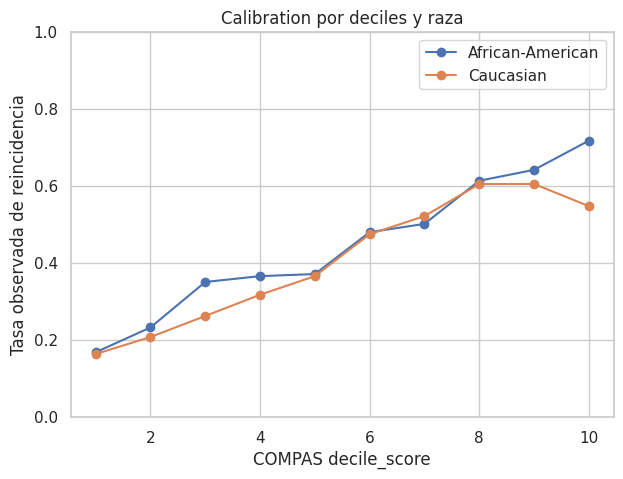

In [ ]:
plt.figure(figsize=(7, 5))
for race, g in calib_por_raza.groupby("race"):
    plt.plot(g["decile_score"], g["tasa_observada_raza"], marker="o", label=race)

plt.xlabel("COMPAS decile_score")
plt.ylabel("Tasa observada de reincidencia")
plt.title("Calibration por deciles y raza")
plt.grid(True)
plt.ylim(0, 1)
plt.legend()
plt.show()

La comparación de la tasa observada de reincidencia por decil y raza muestra que, para la mayoría de los niveles del score, African-American y Caucasian presentan tasas similares, lo que sugiere una calibración comparable **dentro** de cada grupo.

Las diferencias más pronunciadas aparecen en el decil superior, especialmente para el grupo Caucasian, donde el tamaño muestral es reducido (observar la tabla abajo) y la estimación es estadísticamente inestable, lo que sugiere ruido en los extremos más que una mala calibración sistemática.

En este contexto, las disparidades observadas en precision y recall bajo un umbral fijo de alto riesgo no contradicen la buena calibración del score, sino que reflejan la interacción entre un sistema de puntuación ordinal bien calibrado y la aplicación de un umbral común en presencia de tasas base y distribuciones distintas entre grupos.

In [ ]:
calib_por_raza[calib_por_raza["decile_score"] == 10][["race", "recuento_raza"]]

,race,recuento_raza
9,African-American,209
19,Caucasian,42


## **Conclusión**

El análisis muestra que COMPAS presenta una capacidad de discriminación similar entre los grupos African-American y Caucasian, como indican los valores comparables de AUC. Asimismo, el estudio de calibration por deciles evidencia que el decile_score está bien calibrado en sentido ordinal y de forma consistente dentro de cada grupo, ya que niveles más altos del score corresponden sistemáticamente a mayores tasas observadas de reincidencia; las diferencias más pronunciadas aparecen únicamente en el decil superior, donde los tamaños muestrales son reducidos para Caucasian y la variabilidad es mayor.

No obstante, al aplicar un único umbral para clasificar a los individuos como de alto riesgo, surgen diferencias sustanciales en precision y recall. En particular, COMPAS identifica una mayor proporción de reincidentes en el grupo African-American, mientras que en el grupo Caucasian el sistema presenta un recall considerablemente inferior, omitiendo a una parte relevante de los reincidentes. Estas disparidades no contradicen la buena calibración ni la capacidad de ordenación del score, sino que reflejan la interacción entre un sistema bien calibrado, el uso de un criterio de decisión uniforme y la existencia de tasas base y distribuciones distintas entre grupos.

En conjunto, los resultados indican que una AUC similar y una calibration adecuada no garantizan un desempeño equivalente en términos de precision y recall. Estos resultados subrayan que la evaluación de sistemas de riesgo debe ir más allá de métricas globales como el AUC y considerar cómo los scores se traducen en decisiones operativas. En este contexto, resulta pertinente analizar si modelos alternativos, entrenados con variables transparentes, reproducen patrones similares en términos de calibration y precision/recall.

---

# **Creación de modelos de machine learning**
Ahora, se entrenará un modelo de regresión logística con el objetivo de estimar la probabilidad de reincidencia a partir de las variables disponibles en el dataset COMPAS, y evaluamos su desempeño por raza.

La elección de este modelo responde a su carácter lineal e interpretable, lo que permite analizar de manera transparente la contribución de cada variable en la predicción y establecer una línea base metodológicamente sólida. Además, la regresión logística constituye un punto de referencia estándar en problemas de clasificación binaria, facilitando comparaciones posteriores con modelos más complejos.

### ***Estructura***

Tras la evaluación de COMPAS mediante AUC, precision/recall y calibration, se constató que el sistema presenta una capacidad de discriminación comparable entre grupos y una calibración adecuada del decile_score, pero que al aplicar un umbral común emergen diferencias relevantes en las métricas operativas. Esto plantea la necesidad de analizar si dichas disparidades son atribuibles al diseño específico de COMPAS o si, por el contrario, responden a características estructurales.

Con este objetivo, se propone entrenar varios modelos de regresión logística utilizando distintas combinaciones de variables consideradas aceptables —principalmente historial delictivo y otros factores relevantes— excluyendo explícitamente la variable raza. Estos modelos se evaluarán mediante las mismas métricas (AUC, precision/recall y calibration) para permitir una comparación sistemática con COMPAS y analizar si las diferencias observadas persisten bajo un enfoque predictivo más simple y transparente.

### Preparación del dataset
Preparamos los datos para el modelo de regresión logística.
Nos quedamos solo con `age_cat`, `juv_fel_count`, `juv_misd_count`, `juv_other_count`, `priors_count`, `c_charge_degree`, `two_year_recid`, ya que el resto son variables irrelevantes, pueden causar data leakage (como las variables relevantes al recidivismo, p. ej., `r_case_number`, `r_offense_date`, `r_days_from_arrest`), o son precisamente la variable que queremos retirar para controlarla en el modelo (`race`).

In [ ]:
campos_modelo = ["age_cat", "juv_fel_count", "juv_misd_count", "juv_other_count", "priors_count", "c_charge_degree", "two_year_recid"]
compas_scores_two_years_modelo = compas_scores_two_years_eval[campos_modelo].dropna().copy()
compas_scores_two_years_modelo.shape


(6195, 7)

### Hacemos get_dummies para convertir las variables categóricas en numéricas


In [ ]:
compas_scores_two_years_modelo = pd.get_dummies(compas_scores_two_years_modelo, columns=["age_cat", "c_charge_degree"], drop_first=True)
compas_scores_two_years_modelo.head()

,juv_fel_count,juv_misd_count,juv_other_count,priors_count,two_year_recid,age_cat_Greater than 45,age_cat_Less than 25,c_charge_degree_M
0,0,0,0,0,0,True,False,False
1,0,0,0,0,1,False,False,False
2,0,0,1,4,1,False,True,False
3,0,1,0,1,0,False,True,False
4,0,0,0,2,0,False,False,False


### Separamos el dataset entre train y test


In [ ]:
# Separamos dataset entre train y test
X = compas_scores_two_years_modelo.drop(columns=["two_year_recid"])
y = compas_scores_two_years_modelo["two_year_recid"]
# Dividimos el dataset en conjunto de entrenamiento (80%) y conjunto de prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape de compas_scores_two_years_modelo:", compas_scores_two_years_modelo.shape)
print("Shape de X y Y:", X.shape, y.shape)
print("Shape de X y Y de training:", X_train.shape, y_train.shape)
print("Shape de X y Y de test:", X_test.shape, y_test.shape)

Shape de compas_scores_two_years_modelo: (6195, 8)
Shape de X y Y: (6195, 7) (6195,)
Shape de X y Y de training: (4956, 7) (4956,)
Shape de X y Y de test: (1239, 7) (1239,)


# Estandarizar variables con StandardScaler
Antes de entrenar el modelo, estandarizamos las variables numéricas con StandardScaler. Las variables tienen escalas muy distintas: priors_count puede llegar a 30 o más, mientras que las variables dummy solo toman valores 0 o 1.
LogisticRegression penaliza los coeficientes en función de su tamaño numérico, lo que distorsionaría artificialmente el peso de las variables con mayor escala. Estandarizar garantiza que todas contribuyan en igualdad de condiciones y que los coeficientes sean interpretables correctamente.
En palabras simples, StandardScaler hace que todas las variables sean comparables entre sí.

**NOTA**: StandardScaler se aplica únicamente a las variables numéricas (`juv_fel_count`, `juv_misd_count`, `juv_other_count` y `priors_count`), ya que las variables dummy (`age_cat` y `c_charge_degree`) ya están en escala 0-1 y escalarlas distorsionaría su interpretación sin aportar beneficio al modelo.

In [ ]:
# Instanciamos y fiteamos el scaler solo con el set de train. Esto es importante para evitar data leakage.
scaler = StandardScaler()

columnas_continuas = ["juv_fel_count", "juv_misd_count", "juv_other_count", "priors_count"]
X_train[columnas_continuas] = scaler.fit_transform(X_train[columnas_continuas])
X_test[columnas_continuas] = scaler.transform(X_test[columnas_continuas])

In [ ]:
# Instanciamos el modelo
logreg = LogisticRegression(random_state=42)
# Entrenamos el modelo
logreg.fit(X_train, y_train)

LogisticRegression(random_state=42)

**Hemos entrenado el modelo, ahora exploremos los parámetros con sus coeficientes e intercept, así como sus odds ratios**

- **Coeficiente (coefficient)**: Es el "peso" que el modelo le asigna a cada variable del dataset. Indica cuánto influye esa variable en la predicción final y en qué dirección (positiva o negativa). Por ejemplo, si el coeficiente de priors_count es alto, significa que tener más antecedentes tiene un fuerte impacto en la predicción del modelo.
- **Odds ratio (razón de probabilidades)**: Indica cuánto se multiplican las probabilidades de reincidencia cuando una variable aumenta en una unidad, manteniendo constantes las demás variables. Para las variables continuas
(priors_count, juv_fel_count, juv_misd_count, juv_other_count), que han sido
estandarizadas, el incremento de "una unidad" equivale a una desviación estándar, no a un caso adicional. Para las variables dummy (age_cat, c_charge_degree), la interpretación es directa: 0 o 1.
- **Intercepto (intercept)**: Es el valor base de la predicción cuando todas las variables del modelo valen cero. Es el punto de partida del modelo antes de considerar cualquier variable. En la práctica, es un ajuste que permite al modelo ser más preciso aunque ninguna variable tenga un valor real de cero.


https://www.theanalysisfactor.com/interpreting-regression-coefficients/

In [ ]:
# Evaluamos los coeficientes odds ratio de cada variable para interpretar su impacto en la probabilidad de reincidencia, así como el intercepto
coeficientes = logreg.coef_.flatten()
odds_ratios = np.exp(coeficientes)
coef_y_odds_ratios_logreg = pd.DataFrame({"Coeficientes": coeficientes, "Odds ratios": odds_ratios}, index=X.columns).sort_values('Odds ratios', ascending=False)
intercept = logreg.intercept_
display(coef_y_odds_ratios_logreg)
print(f"Intercepto: {intercept}")

# Convirtamos el intercepto a odds ratio y a probabilidad para facilitar la interpretación
odds_ratio_intercept = np.exp(intercept)
probabilidad_intercepto = odds_ratio_intercept / (1 + odds_ratio_intercept)
print(f"Odds ratio del intercepto: {odds_ratio_intercept[0]:.4f}")
print(f"Probabilidad del intercepto: {probabilidad_intercepto[0]*100:.4f}")

,Coeficientes,Odds ratios
age_cat_Less than 25,0.730610,2.076348
priors_count,0.689841,1.993398
juv_other_count,0.100282,1.105482
juv_misd_count,0.066081,1.068314
juv_fel_count,0.044911,1.045935
c_charge_degree_M,-0.141240,0.868281
age_cat_Greater than 45,-0.665468,0.514033


Intercepto: [-0.55740299]
Odds ratio del intercepto: 0.5727
Probabilidad del intercepto: 36.4149


#### Grafiquemos los coeficientes y el odds ratio por claridad

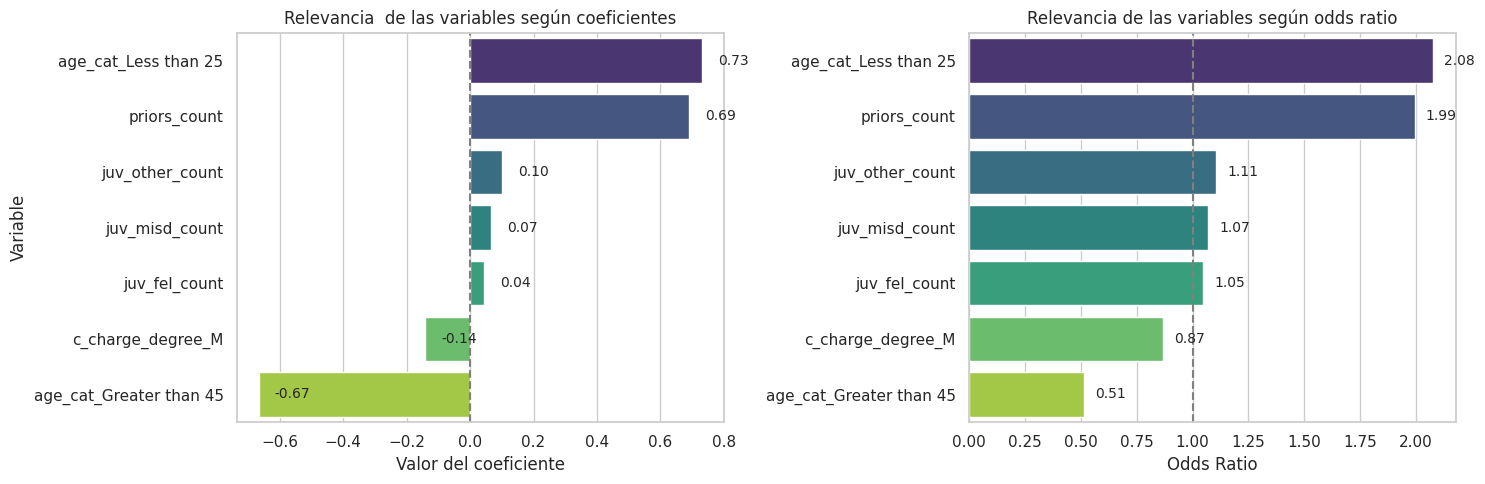

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
coef_plot = pd.DataFrame(logreg.coef_.flatten(),index=X.columns,columns=['Coeficientes']).sort_values('Coeficientes', ascending=False).reset_index()
coef_plot.columns = ['Variable', 'Coeficientes']

odds_plot = coef_y_odds_ratios_logreg.reset_index()
odds_plot.columns = ['Variable', 'Coeficiente', 'Odds Ratio']

sns.barplot(data=coef_plot, x='Coeficientes', y='Variable', palette='viridis', ax=axes[0])
axes[0].set_title('Relevancia  de las variables según coeficientes')
axes[0].set_xlabel('Valor del coeficiente')
axes[0].set_ylabel('Variable')
for i, coef in enumerate(coef_plot['Coeficientes']):
    axes[0].text(coef + 0.05, i, f"{coef:.2f}", va='center', fontsize=10)
axes[0].axvline(0, color='grey', linestyle='--')

sns.barplot(data=odds_plot, x='Odds Ratio', y='Variable', palette='viridis', ax=axes[1])
axes[1].set_title('Relevancia de las variables según odds ratio')
axes[1].set_xlabel('Odds Ratio')
axes[1].set_ylabel('')
axes[1].axvline(1, color='grey', linestyle='--')

for i, (coef, odds) in enumerate(zip(coef_plot['Coeficientes'], odds_plot['Odds Ratio'])):
    axes[1].text(odds + 0.05, i, f"{odds:.2f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

### **¿Qué podemos interpretar de los coeficientes y odds ratios?**
Según el modelo, pertenecer al grupo de edad menor de 25 años es el factor más
asociado con la reincidencia (Odds Ratio = 2.08), seguido muy de cerca por el
historial de delitos previos (Odds Ratio = 1.99, interpretado por desviación estándar dado que la variable fue estandarizada). Ambos factores tienen un peso
prácticamente equivalente en el modelo.

Ser mayor de 45 años aparece como el principal factor protector (Odds Ratio = 0.51).


#### **¿Y para el intercepto?**
El intercepto corresponde al perfil de referencia abstracto del modelo:
persona de 25–45 años, con delito grave (Felony) y con un historial criminal
en la media del conjunto de entrenamiento. Para este perfil, el modelo estima
una probabilidad base de reincidencia del 36.41%.

## Hagamos predicciones
Vamos a seleccionar una persona del conjunto test y hacer predicciones con el modelo de regresión logística

In [ ]:
# Prediccion para una persona especifica
sample_index = 165
sample_data = X_test.iloc[sample_index]
y_real_sample = y_test.iloc[sample_index]
y_pred_sample = logreg.predict([sample_data])[0]
#"Sample" fue forzado a `series`, así que se comporta como Object (dtype: object). Para el siguiente paso, fuerzo "Sample" a `float`.
sample_pred_proba = logreg.predict_proba([np.array(sample_data, dtype=float)])[0][1]


display("Datos de la persona:")
print(sample_data)
print("Valor de reincidencia real:", y_real_sample)
print(f"Predicción del modelo: {y_pred_sample} (1 = reincidente, 0 = no reincidente)")
print(f"Probabilidad de reincidencia según el modelo: {sample_pred_proba*100:.2f}%")

'Datos de la persona:'

juv_fel_count             -0.152294
juv_misd_count            -0.178518
juv_other_count           -0.206092
priors_count              -0.699234
age_cat_Greater than 45        True
age_cat_Less than 25          False
c_charge_degree_M              True
Name: 2794, dtype: object
Valor de reincidencia real: 1
Predicción del modelo: 0 (1 = reincidente, 0 = no reincidente)
Probabilidad de reincidencia según el modelo: 13.17%


Nota: los valores negativos que pueden aparecer en las variables continuas
al hacer predicciones individuales no indican valores reales negativos, sino
que esa persona se encuentra por debajo de la media del conjunto de
entrenamiento en esa variable.

Seleccionemos la primera persona del conjunto de test que haya reincidido

In [ ]:
# Seleccionar la primmera muestra del conjunto de test que corresponde a una persona que reincidió (y_test == 1)
primer_reincidente = y_test[y_test==1].index[0]
sample_data_2 = X_test.loc[primer_reincidente, :]
y_real_sample_2 = y_test.loc[primer_reincidente]
y_pred_sample_2 = logreg.predict([sample_data_2])[0]
sample_pred_proba_2 = logreg.predict_proba([np.array(sample_data_2, dtype=float)])[0][1]


display("Datos de la persona:")
print(sample_data_2)
print("Valor de reincidencia real:", y_real_sample_2)
print(f"Predicción del modelo: {y_pred_sample_2} (1 = reincidente, 0 = no reincidente)")
print(f"Probabilidad de reincidencia según el modelo: {sample_pred_proba_2*100:.2f}%")

'Datos de la persona:'

juv_fel_count             -0.152294
juv_misd_count            -0.178518
juv_other_count            1.808486
priors_count              -0.699234
age_cat_Greater than 45       False
age_cat_Less than 25           True
c_charge_degree_M              True
Name: 3006, dtype: object
Valor de reincidencia real: 1
Predicción del modelo: 0 (1 = reincidente, 0 = no reincidente)
Probabilidad de reincidencia según el modelo: 42.86%


### Hagamos una predicción de todo el conjunto

In [ ]:
# Hacer predicciones con el conjunto de prueba
y_pred_logreg_test = logreg.predict(X_test)
y_pred_proba_logreg_test = logreg.predict_proba(X_test)[:, 1]

# Hacer predicciones con el conjunto de training
y_pred_logreg_train = logreg.predict(X_train)
y_pred_proba_logreg_train = logreg.predict_proba(X_train)[:, 1]

print(f"Predicciones para todo el conjunto de test: {y_pred_logreg_test}")
print(f"Predicciones (probabilidades) para todo el conjunto de test: {y_pred_proba_logreg_test*100}")
print("**"*50)
print(f"Predicciones para todo el conjunto de train: {y_pred_logreg_train}")
print(f"Predicciones (probabilidades) para todo el conjunto de train: {y_pred_proba_logreg_train*100}")

Predicciones para todo el conjunto de test: [0 0 0 ... 1 1 1]
Predicciones (probabilidades) para todo el conjunto de test: [45.03446167 48.74775157 42.85740926 ... 56.74544249 55.90005715
 78.45702883]
****************************************************************************************************
Predicciones para todo el conjunto de train: [1 0 0 ... 0 0 0]
Predicciones (probabilidades) para todo el conjunto de train: [57.34219982 37.99650191 33.17481288 ... 16.97472827 25.51884113
 16.86315324]


---
### **Hagamos una comparación entre test y training, usando classification reports**

Un classification report es un resumen tabular del desempeño de un modelo de clasificación. Este produce estas métricas:

- **Precision:** De todos los casos que el modelo predijo como clase X, ¿cuántos realmente lo eran?

- **Recall** (también llamado sensibilidad o tasa de verdaderos positivos): De todos los casos que realmente son clase X, ¿cuántos detectó el modelo?

- **F1-Score**: La media armónica entre precision y recall. Sirve para tener un solo número que equilibre ambas métricas, especialmente útil cuando hay desbalance entre clases.

- **Macro avg**: El promedio simple de cada métrica entre las dos clases, sin importar cuántos casos tiene cada una.

- **Weighted avg**: El promedio ponderado por el número de casos (support) de cada clase.

- **Accuracy**: De todos los casos, ¿qué porcentaje clasificó correctamente? Este es una métrica global.


In [ ]:
# Classification report para el modelo de regresión logística en train y test (en dataframe para facilitar visibilidad)
cf_train = pd.DataFrame(classification_report(y_train, y_pred_logreg_train,output_dict=True)).transpose()
cf_test = pd.DataFrame(classification_report(y_test, y_pred_logreg_test,output_dict=True)).transpose()
print("Train")
display(cf_train)
print("\r\n","="*60,"\r\n","Test")
display(cf_test)

Train


,precision,recall,f1-score,support
0,0.701239,0.912164,0.792914,3165.000000
1,0.668653,0.313233,0.426616,1791.000000
accuracy,0.695722,0.695722,0.695722,0.695722
macro avg,0.684946,0.612699,0.609765,4956.000000
weighted avg,0.689463,0.695722,0.660541,4956.000000



 Test


,precision,recall,f1-score,support
0,0.694471,0.905183,0.785950,791.00000
1,0.639423,0.296875,0.405488,448.00000
accuracy,0.685230,0.685230,0.685230,0.68523
macro avg,0.666947,0.601029,0.595719,1239.00000
weighted avg,0.674567,0.685230,0.648381,1239.00000


**Veamos esto gráficamente**

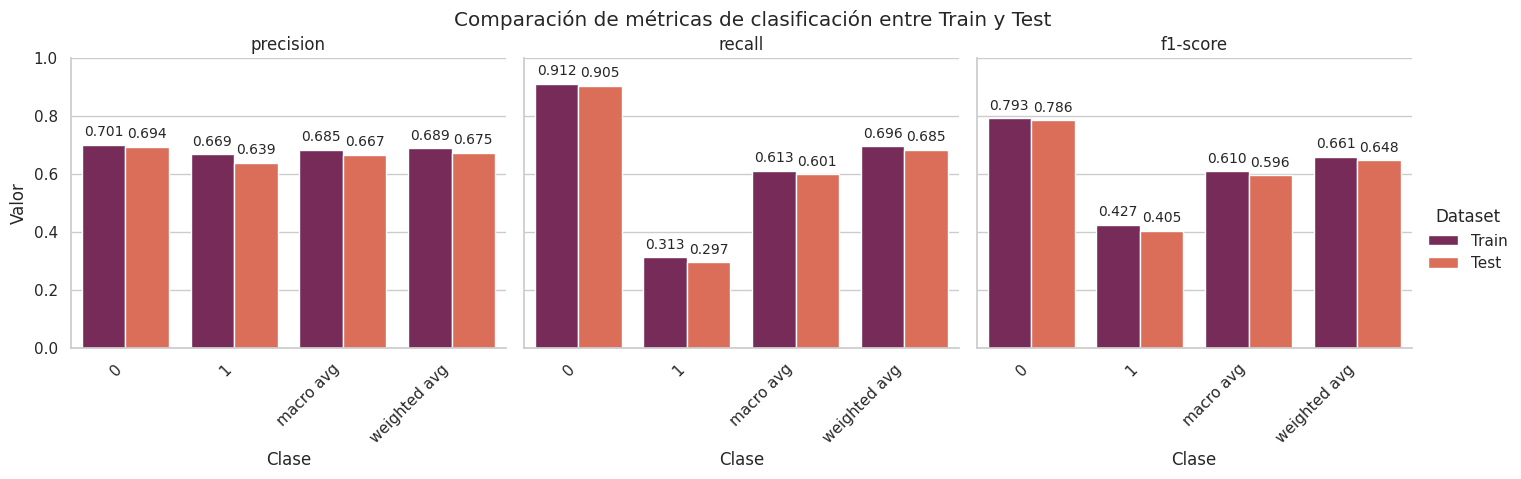

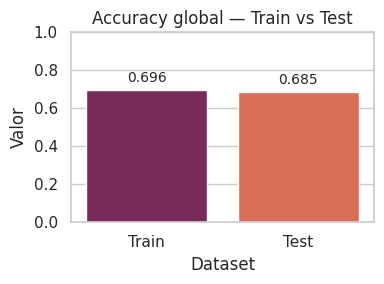

In [ ]:
# Plots que comparen los classification report de train y test para visualizar posibles overfitting o underfitting
## Definimos las métricas que queremos comparar
metric = ['precision', 'recall', 'f1-score']

# Separar accuracy antes del melt
accuracy = pd.DataFrame({'Dataset': ['Train', 'Test'],'Accuracy': [cf_train.loc['accuracy', 'f1-score'],cf_test.loc['accuracy', 'f1-score']]})

# Excluir la fila accuracy del melt
cf_train_melted = (cf_train.drop(index='accuracy').reset_index().melt(id_vars='index', value_vars=metric, var_name='Metric', value_name='Value'))
cf_test_melted = (cf_test.drop(index='accuracy').reset_index().melt(id_vars='index', value_vars=metric, var_name='Metric', value_name='Value'))
cf_train_melted['Dataset'] = 'Train'
cf_test_melted['Dataset']  = 'Test'
cf_combined = pd.concat([cf_train_melted, cf_test_melted])

g = sns.FacetGrid(cf_combined, col='Metric', height=4, aspect=1.2, sharey=True)
g.map_dataframe(sns.barplot, x='index', y='Value', hue='Dataset', palette='rocket', capsize=0.1)
g.add_legend(title='Dataset')
g.set_axis_labels('Clase', 'Valor')
g.set_titles(col_template='{col_name}')
g.set_xticklabels(rotation=45, ha='right')
g.figure.suptitle('Comparación de métricas de clasificación entre Train y Test', y=1.02)
for ax in g.axes.flat:
    ax.set_ylim(0, 1)
    for p in ax.patches:
        if p.get_height() > 0.001:
            ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=10)
plt.show()

# Accuracy por separado
fig, ax = plt.subplots(figsize=(4, 3))
sns.barplot(data=accuracy, x='Dataset', y='Accuracy', palette='rocket', ax=ax)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=10)
ax.set_title('Accuracy global — Train vs Test', fontsize=12)
ax.set_ylim(0, 1)
ax.set_ylabel('Valor')
plt.tight_layout()
plt.show()

**¿Qué nos dicen estos datos?**

Mirando el conjunto Test, nos dicen que el modelo se comporta de forma muy similar en entrenamiento y en test, por lo que no hay señales de sobreajuste: generaliza correctamente a datos nuevos. La accuracy y los F1-score son prácticamente iguales en ambos conjuntos, lo que indica estabilidad.

Sin embargo, también muestran que el modelo está detectando mucho mejor la clase mayoritaria (clase 0) que la minoritaria (clase 1). El recall de la clase 0 es alto (0.905), mientras que el de la clase 1 es bajo (alrededor de 0.297). Esto significa que el modelo está perdiendo muchos casos reales de la clase 1.

En resumen, el modelo es consistente y generaliza bien, pero está sesgado hacia la clase más frecuente y no está capturando adecuadamente la clase menos frecuente.

¿Cómo podemos enfrentar esto? Balanceando las clases para que el algoritmo penalice más los errores en la clase minoritaria y menos en la mayoritaria (es decir, cambia la función de coste durante el entrenamiento.) Para ello, usamos `class_weight='balanced'`

--------------------------------
### **Hagamos una segunda predicción de todo el conjunto, usando `class_weight='balanced'`**

In [ ]:
# Instanciamos el modelo
logreg_balanced = LogisticRegression(random_state=42, class_weight='balanced')
# Entrenamos el modelo
logreg_balanced.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

### Hagamos una predicción de todo el conjunto entrenado con clases balanceadas

In [ ]:
# Hacer predicciones con el conjunto de prueba
y_pred_logreg_balanced_test = logreg_balanced.predict(X_test)
y_pred_proba_logreg_balanced_test = logreg_balanced.predict_proba(X_test)[:, 1]

# Hacer predicciones con el conjunto de training
y_pred_logreg_balanced_train = logreg_balanced.predict(X_train)
y_pred_proba_logreg_balanced_train = logreg_balanced.predict_proba(X_train)[:, 1]

print(f"Predicciones para todo el conjunto de test: {y_pred_logreg_balanced_test}")
print(f"Predicciones (probabilidades) para todo el conjunto de test: {y_pred_proba_logreg_balanced_test*100}")
print("**"*50)
print(f"Predicciones para todo el conjunto de train: {y_pred_logreg_balanced_train}")
print(f"Predicciones (probabilidades) para todo el conjunto de train: {y_pred_proba_logreg_balanced_train*100}")

Predicciones para todo el conjunto de test: [1 1 1 ... 1 1 1]
Predicciones (probabilidades) para todo el conjunto de test: [58.71451148 62.46637613 56.95921445 ... 70.91026018 69.39817999
 87.26205141]
****************************************************************************************************
Predicciones para todo el conjunto de train: [1 1 0 ... 0 0 0]
Predicciones (probabilidades) para todo el conjunto de train: [70.7734993  51.51685928 47.61147809 ... 26.58154446 37.19385895
 26.13611016]


## Exploremos los parámetros con sus coeficientes e intercept, así como sus odds ratios

In [ ]:
# Evaluamos los coeficientes odds ratio de cada variable para interpretar su impacto en la probabilidad de reincidencia, así como el intercepto
coeficientes_balanced = logreg_balanced.coef_.flatten()
odds_ratios_balanced = np.exp(coeficientes_balanced)
coef_y_odds_ratios_logreg_balanced = pd.DataFrame({"Coeficientes": coeficientes_balanced, "Odds ratios": odds_ratios_balanced}, index=X.columns).sort_values('Odds ratios', ascending=False)
intercept_balanced = logreg_balanced.intercept_
display(coef_y_odds_ratios_logreg_balanced)
print(f"Intercepto: {intercept_balanced}")

# Convirtamos el intercepto a odds ratio y a probabilidad para facilitar la interpretación
odds_ratio_intercept_balanced = np.exp(intercept_balanced)
probabilidad_intercepto_balanced = odds_ratio_intercept_balanced / (1 + odds_ratio_intercept_balanced)
print(f"Odds ratio del intercepto: {odds_ratio_intercept_balanced[0]:.4f}")
print(f"Probabilidad del intercepto: {probabilidad_intercepto_balanced[0]*100:.4f}")

,Coeficientes,Odds ratios
age_cat_Less than 25,0.741818,2.099749
priors_count,0.727008,2.068881
juv_other_count,0.108953,1.115110
juv_misd_count,0.064434,1.066556
juv_fel_count,0.044990,1.046017
c_charge_degree_M,-0.134267,0.874356
age_cat_Greater than 45,-0.649264,0.522430


Intercepto: [0.00230036]
Odds ratio del intercepto: 1.0023
Probabilidad del intercepto: 50.0575


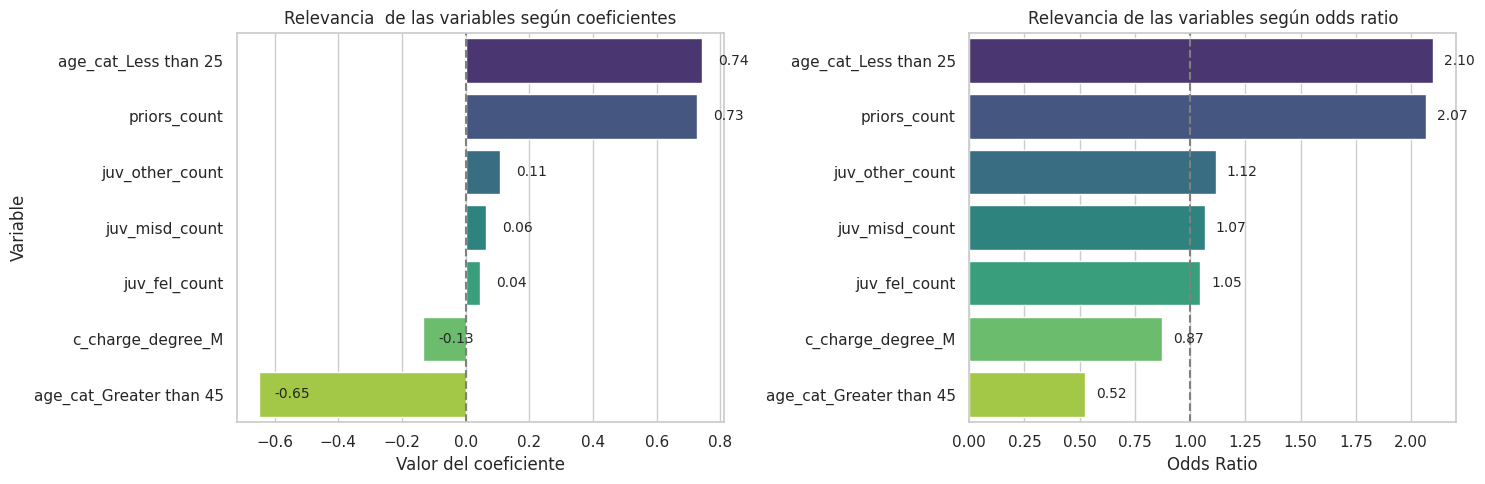

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
coef_plot_balanced = pd.DataFrame(logreg_balanced.coef_.flatten(),index=X.columns,columns=['Coeficientes']).sort_values('Coeficientes', ascending=False).reset_index()
coef_plot_balanced.columns = ['Variable', 'Coeficientes']

odds_plot_balanced = coef_y_odds_ratios_logreg_balanced.reset_index()
odds_plot_balanced.columns = ['Variable', 'Coeficiente', 'Odds Ratio']

sns.barplot(data=coef_plot_balanced, x='Coeficientes', y='Variable', palette='viridis', ax=axes[0])
axes[0].set_title('Relevancia  de las variables según coeficientes')
axes[0].set_xlabel('Valor del coeficiente')
axes[0].set_ylabel('Variable')
for i, coef in enumerate(coef_plot_balanced['Coeficientes']):
    axes[0].text(coef + 0.05, i, f"{coef:.2f}", va='center', fontsize=10)
axes[0].axvline(0, color='grey', linestyle='--')

sns.barplot(data=odds_plot_balanced, x='Odds Ratio', y='Variable', palette='viridis', ax=axes[1])
axes[1].set_title('Relevancia de las variables según odds ratio')
axes[1].set_xlabel('Odds Ratio')
axes[1].set_ylabel('')
axes[1].axvline(1, color='grey', linestyle='--')

for i, (coef, odds) in enumerate(zip(coef_plot_balanced['Coeficientes'], odds_plot_balanced['Odds Ratio'])):
    axes[1].text(odds + 0.05, i, f"{odds:.2f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

Vemos que la relevancia de las diferentes variables en el modelo balanceado es casi idéntica a la del modelo anterior: el mismo orden, la misma dirección, y magnitudes muy similares.

### Nuevo classification_report para el modelo de regresión logística en train y test, con el nuevo modelo

In [ ]:
cf_train_balanced = pd.DataFrame(classification_report(y_train, y_pred_logreg_balanced_train,output_dict=True)).transpose()
cf_test_balanced = pd.DataFrame(classification_report(y_test, y_pred_logreg_balanced_test,output_dict=True)).transpose()
print("Train")
display(cf_train_balanced)
print("\r\n","="*60,"\r\n","Test")
display(cf_test_balanced)

Train


,precision,recall,f1-score,support
0,0.767500,0.678989,0.720536,3165.00000
1,0.528757,0.636516,0.577654,1791.00000
accuracy,0.663640,0.663640,0.663640,0.66364
macro avg,0.648128,0.657752,0.649095,4956.00000
weighted avg,0.681223,0.663640,0.668902,4956.00000



 Test


,precision,recall,f1-score,support
0,0.760623,0.678887,0.717435,791.000000
1,0.523452,0.622768,0.568807,448.000000
accuracy,0.658596,0.658596,0.658596,0.658596
macro avg,0.642038,0.650828,0.643121,1239.000000
weighted avg,0.674866,0.658596,0.663694,1239.000000


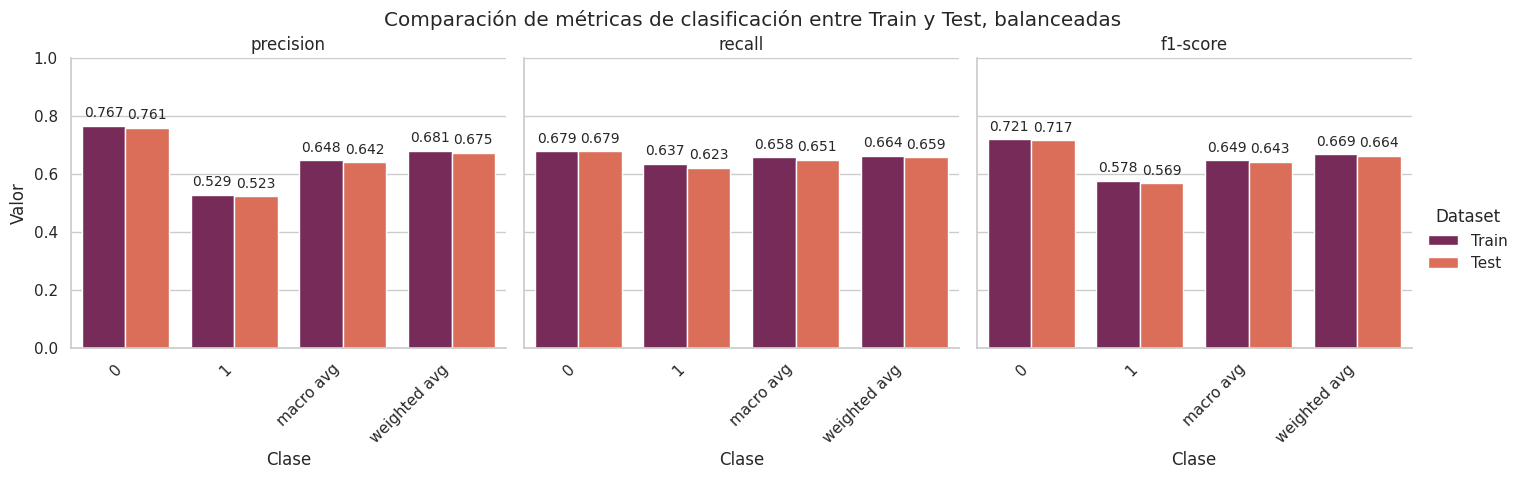

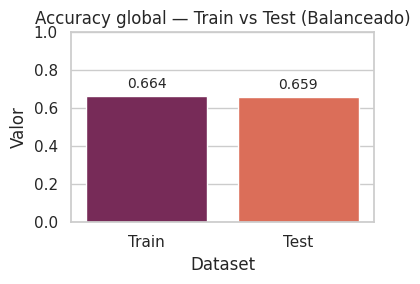

In [ ]:
# Plots que comparen los classification report de train y test para visualizar posibles overfitting o underfitting
## Definimos las métricas que queremos comparar
metric_balanced = ['precision', 'recall', 'f1-score']

# Separar accuracy antes del melt
accuracy_balanced = pd.DataFrame({'Dataset': ['Train', 'Test'],'Accuracy': [cf_train_balanced.loc['accuracy', 'f1-score'],cf_test_balanced.loc['accuracy', 'f1-score']]})

# Excluir la fila accuracy del melt
cf_train_balanced_melted = (cf_train_balanced.drop(index='accuracy').reset_index().melt(id_vars='index', value_vars=metric_balanced, var_name='Metric', value_name='Value'))

cf_test_balanced_melted = (cf_test_balanced.drop(index='accuracy').reset_index().melt(id_vars='index', value_vars=metric_balanced, var_name='Metric', value_name='Value'))

cf_train_balanced_melted['Dataset'] = 'Train'
cf_test_balanced_melted['Dataset']  = 'Test'
cf_combined_balanced = pd.concat([cf_train_balanced_melted, cf_test_balanced_melted])

# FacetGrid sin accuracy
g = sns.FacetGrid(cf_combined_balanced, col='Metric', height=4, aspect=1.2, sharey=True)
g.map_dataframe(sns.barplot, x='index', y='Value', hue='Dataset', palette='rocket', capsize=0.1)
g.add_legend(title='Dataset')
g.set_axis_labels('Clase', 'Valor')
g.set_titles(col_template='{col_name}')
g.set_xticklabels(rotation=45, ha='right')
g.figure.suptitle('Comparación de métricas de clasificación entre Train y Test, balanceadas', y=1.02)
for ax in g.axes.flat:
    ax.set_ylim(0, 1)
    for p in ax.patches:
        if p.get_height() > 0.001:
            ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=10)
plt.show()

# Accuracy por separado
fig, ax = plt.subplots(figsize=(4, 3))
sns.barplot(data=accuracy_balanced, x='Dataset', y='Accuracy', palette='rocket', ax=ax)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=10)
ax.set_title('Accuracy global — Train vs Test (Balanceado)', fontsize=12)
ax.set_ylim(0, 1)
ax.set_ylabel('Valor')
plt.tight_layout()
plt.show()

## **Comparemos gráficamente cómo se comportan las métricas entre el modelo original y el balanceado**

In [ ]:
def compare_reports(comp1, comp2, label1="Original", label2="Balanceado", split="Train"):
    metrics_comparison = ["precision", "recall", "f1-score"]

    # Seleccionamos solo las filas relevantes (clases + promedios)
    rows = [idx for idx in comp1.index if idx != "support"]
    comparison = pd.DataFrame()
    for metric in metrics_comparison:
        comparison[(label1, metric)] = comp1.loc[rows, metric]
        comparison[(label2, metric)] = comp2.loc[rows, metric]

    comparison.columns = pd.MultiIndex.from_tuples(comparison.columns)
    return comparison


# Comparación Train
compare_train = compare_reports(cf_train, cf_train_balanced, split="Train")

# Comparación Test
compare_test = compare_reports(cf_test, cf_test_balanced, split="Test")

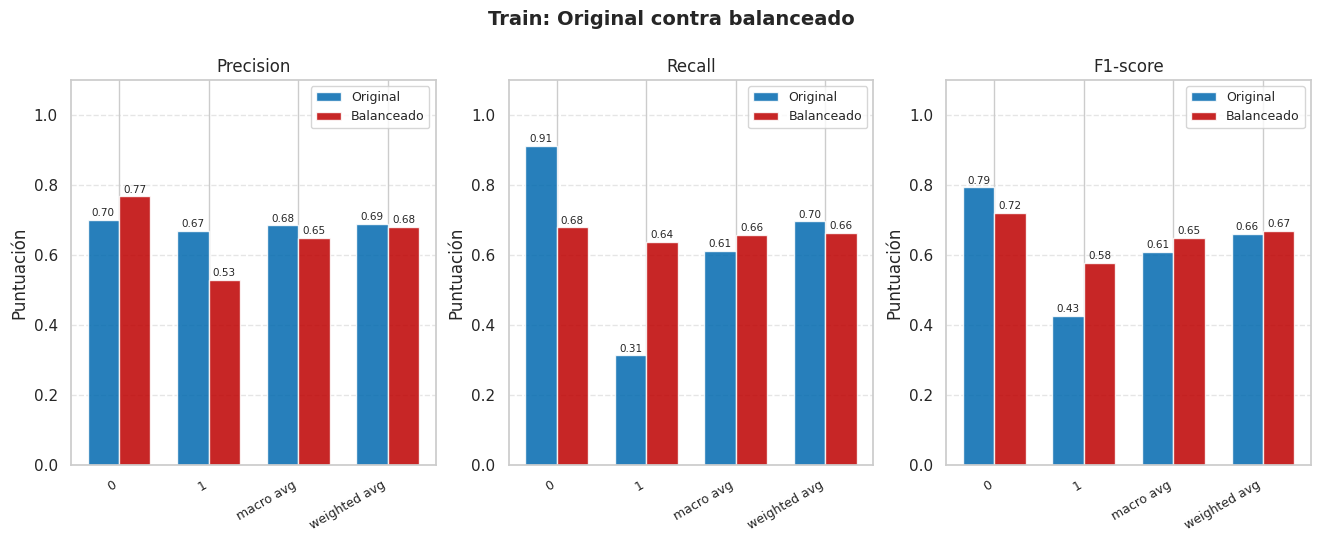

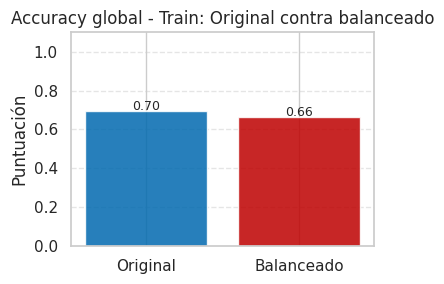

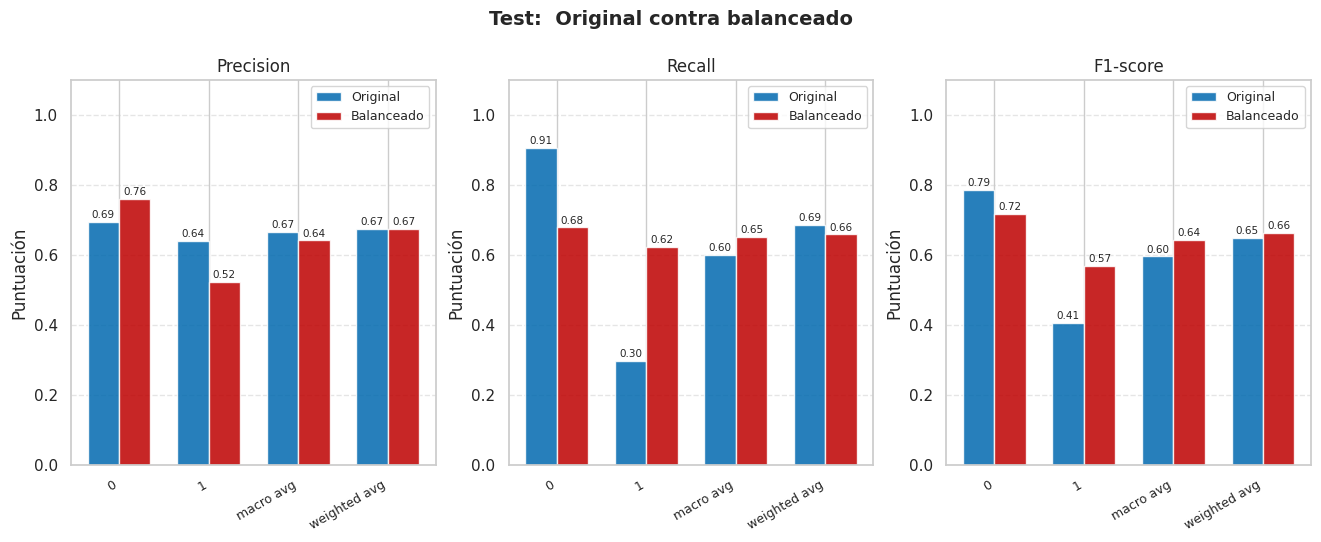

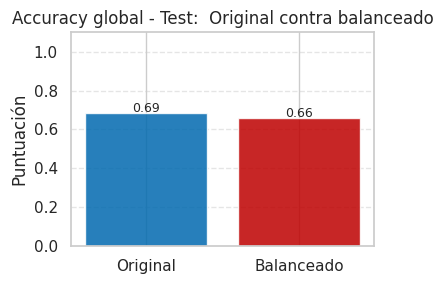

In [ ]:
def plot_comparison(compare_df, title=""):
    metrics = ["precision", "recall", "f1-score"]

    # Separar accuracy del resto
    rows = [r for r in compare_df.index.tolist() if r != "accuracy"]
    accuracy_row = compare_df.loc["accuracy"] if "accuracy" in compare_df.index else None

    labels = [col for col in compare_df.columns.get_level_values(0).unique() if col != "delta"]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.02)

    x = np.arange(len(rows))
    width = 0.35
    colors = ["#0169AF", "#BE0000"]

    for ax, metric in zip(axes, metrics):
        for i, (label, color) in enumerate(zip(labels, colors)):
            values = compare_df.loc[rows, (label, metric)].values
            bars = ax.bar(x + i * width, values, width, label=label, color=color, alpha=0.85)

            for bar in bars:
                height = bar.get_height()
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    height + 0.005,
                    f"{height:.2f}",
                    ha="center", va="bottom", fontsize=7.5
                )

        ax.set_title(metric.capitalize(), fontsize=12)
        ax.set_xticks(x + width / 2)
        ax.set_xticklabels(rows, rotation=30, ha="right", fontsize=9)
        ax.set_ylim(0, 1.1)
        ax.set_ylabel("Puntuación")
        ax.legend(fontsize=9)
        ax.grid(axis="y", linestyle="--", alpha=0.5)

    fig2, ax2 = plt.subplots(figsize=(4, 3))
    acc_values = [accuracy_row[(label, "f1-score")] for label in labels]
    ax2.bar(labels, acc_values, color=colors, alpha=0.85)
    for i, v in enumerate(acc_values):
        ax2.text(i, v + 0.005, f"{v:.2f}", ha="center", fontsize=9)
    ax2.set_title(f"Accuracy global - {title}", fontsize=12)
    ax2.set_ylim(0, 1.1)
    ax2.set_ylabel("Puntuación")
    ax2.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
plot_comparison(compare_train, title="Train: Original contra balanceado")
plot_comparison(compare_test,  title="Test:  Original contra balanceado")

***¿Qué nos dicen estos datos?***  
Comparando los datos en el conjunto de Test, que es el que mide el rendimiento real del modelo sobre datos no vistos, el modelo balanceado mejora sustancialmente la detección de reincidentes reales: el recall de la clase 1 (reincidentes) pasa de 0.30 a 0.62, es decir, se duplica. Sin embargo, la precision cae de 0.64 a 0.52, lo que indica un aumento considerable de falsos positivos. Es el intercambio esperado: más sensibilidad, menos precisión.

En resumen, el modelo sigue generalizando bien, pero aumenta la cantidad de personas que son denominadas como potenciales reincidentes sin serlo.    
\
***CONCLUSIÓN***  
En relación con la predicción de reincidencia judicial, el modelo original es preferible porque **minimiza los falsos positivos**: cuando marca a alguien como "de riesgo", acierta el 64% de las veces, frente al 52% del
modelo balanceado.

Esto quiere decir que el modelo balanceado marca incorrectamente como reincidentes a casi la mitad de las personas que etiqueta como "de riesgo" (precision: 0.52), influyendo en decisiones que les negarían libertad condicional o aumentarían sus sentencias por crímenes que no cometerían.

El coste del modelo original es que detecta menos reincidentes reales (recall más bajo, de 0.30 frente a 0.62 del balanceado). Pero este error tiene una naturaleza distinta: significa que el modelo no interviene, y la persona recibe el trato por defecto del sistema judicial sin el peso adicional de una predicción adversa.

En derecho penal, donde la presunción de inocencia es fundamental, es preferible un modelo conservador que se equivoque menos al acusar, aunque eso signifique perder capacidad de detección. Un falso positivo en este contexto no es un error estadístico, es una injusticia concreta contra una persona identificable.

## **COMPARACIÓN DE ACIERTO DEL MODELO COMPAS VS EL NUESTRO**

### **PRIMERO, CALCULEMOS EL AUC**
El AUC mide la capacidad del modelo para ordenar correctamente. Es decir: probabilidad de que un reincidente tenga un score mayor que un no reincidente.
Como no tenemos un "Score" como en el caso de COMPAS (que tenía un "decile_score" asignado por su modelo), usaremos  la probabilidad de reincidencia (calculado por el método "predict_proba").

In [ ]:
df_auc_nuestro = pd.DataFrame({
    "race": compas_scores_two_years_eval.loc[y_test.index, "race"],
    "score": y_pred_proba_logreg_test,
    "two_year_recid": y_test
})

Recalculamos el AUC del dataset de COMPAS con los mismos datos que usamos para el test dataset de nuestro modelo, para que la comparación sea válida.

In [ ]:
df_auc_compas_test = pd.DataFrame({
    "race": compas_scores_two_years_eval.loc[y_test.index, "race"],
    "score": compas_scores_two_years_eval.loc[y_test.index, "decile_score"],
    "two_year_recid": y_test
})

In [ ]:
# Verificamos que ambos coincidan
print(f"Tamaño y_test: {len(y_test)}")
print(f"Tamaño df_auc_compas_test: {len(df_auc_compas_test)}")
print(f"Índices coinciden: {y_test.index.equals(df_auc_compas_test.index)}")

Tamaño y_test: 1239
Tamaño df_auc_compas_test: 1239
Índices coinciden: True


In [ ]:
auc_score_nuestro = roc_auc_score(df_auc_nuestro["two_year_recid"], df_auc_nuestro["score"])
auc_score_compas_test = roc_auc_score(df_auc_compas_test["two_year_recid"], df_auc_compas_test["score"])
print(f"AUC General de nuestro modelo: {auc_score_nuestro:.4f}")
print(f"AUC General de COMPAS: {auc_score_compas_test:.4f}")

AUC General de nuestro modelo: 0.7084
AUC General de COMPAS: 0.6851


### Veámoslo gráficamente

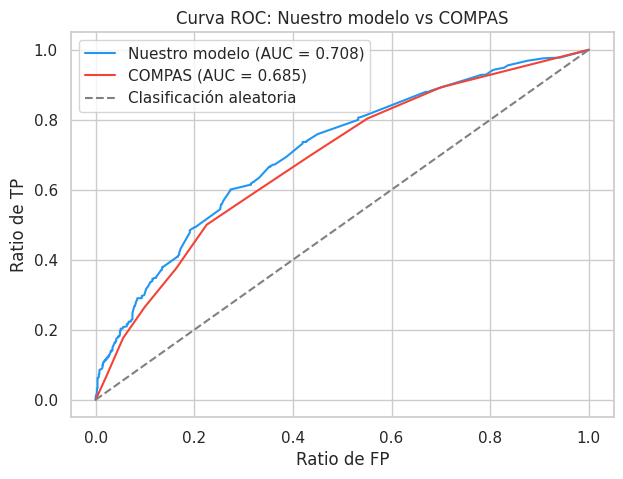

In [ ]:
plt.figure(figsize=(7, 5))
fpr_nuestro, tpr_nuestro, _ = roc_curve(df_auc_nuestro["two_year_recid"], df_auc_nuestro["score"])
fpr_compas, tpr_compas, _ = roc_curve(df_auc_compas_test["two_year_recid"], df_auc_compas_test["score"])
plt.plot(fpr_nuestro, tpr_nuestro, label=f"Nuestro modelo (AUC = {auc_score_nuestro:.3f})", color="#2196F3")
plt.plot(fpr_compas, tpr_compas, label=f"COMPAS (AUC = {auc_score_compas_test:.3f})", color="#F44336")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Clasificación aleatoria")
plt.xlabel("Ratio de FP")
plt.ylabel("Ratio de TP")
plt.title("Curva ROC: Nuestro modelo vs COMPAS")
plt.legend()
plt.show()

### **Calculémoslo por grupo étnico**

In [ ]:
resultado = []
for etnia, g in df_auc_nuestro.groupby("race"):

    if g["two_year_recid"].nunique() < 2:
        resultado.append({
            "Etnia": etnia,
            "Registros": len(g),
            "Mediana de recid_rate": round(g["two_year_recid"].mean(), 3),
            "AUC_NUESTRO": None
        })
        continue

    auc_race = roc_auc_score(g["two_year_recid"], g["score"])

    resultado.append({
        "Etnia": etnia,
        "Registros": len(g),
        "Mediana de recid_rate": round(g["two_year_recid"].mean(), 3),
        "AUC_NUESTRO": round(auc_race, 3)
    })

auc_by_race_nuestro = pd.DataFrame(resultado).sort_values("Registros", ascending=False)
auc_by_race_nuestro


,Etnia,Registros,Mediana de recid_rate,AUC_NUESTRO
0,African-American,639,0.430,0.692
2,Caucasian,401,0.289,0.718
3,Hispanic,125,0.320,0.688
5,Other,68,0.235,0.650
1,Asian,5,0.200,0.750
4,Native American,1,0.000,NaN


In [ ]:
resultado_compas = []
for etnia, g in df_auc_compas_test.groupby("race"):

    if g["two_year_recid"].nunique() < 2:
        resultado_compas.append({
            "Etnia": etnia,
            "Registros": len(g),
            "Mediana de recid_rate": round(g["two_year_recid"].mean(), 3),
            "AUC_COMPAS": None
        })
        continue

    auc_race = roc_auc_score(g["two_year_recid"], g["score"])

    resultado_compas.append({
        "Etnia": etnia,
        "Registros": len(g),
        "Mediana de recid_rate": round(g["two_year_recid"].mean(), 3),
        "AUC_COMPAS": round(auc_race, 3)
    })

auc_by_race_compas = pd.DataFrame(resultado_compas).sort_values("Registros", ascending=False)
auc_by_race_compas

,Etnia,Registros,Mediana de recid_rate,AUC_COMPAS
0,African-American,639,0.430,0.667
2,Caucasian,401,0.289,0.667
3,Hispanic,125,0.320,0.647
5,Other,68,0.235,0.748
1,Asian,5,0.200,0.875
4,Native American,1,0.000,NaN


In [ ]:
auc_compas = auc_by_race_compas.rename(columns={"Etnia": "Etnia", "AUC": "AUC_COMPAS"})
auc_nuestro = auc_by_race_nuestro.rename(columns={"Etnia": "Etnia", "AUC": "AUC_NUESTRO"})
auc_comparativa = auc_compas[["Etnia", "AUC_COMPAS"]].merge(auc_nuestro[["Etnia", "AUC_NUESTRO"]],on="Etnia",how="inner")
auc_comparativa["Diferencia AUC"] = auc_comparativa["AUC_NUESTRO"] - auc_comparativa["AUC_COMPAS"]
auc_comparativa

,Etnia,AUC_COMPAS,AUC_NUESTRO,Diferencia AUC
0,African-American,0.667,0.692,0.025
1,Caucasian,0.667,0.718,0.051
2,Hispanic,0.647,0.688,0.041
3,Other,0.748,0.650,-0.098
4,Asian,0.875,0.750,-0.125
5,Native American,NaN,NaN,NaN


### Veámoslo gráficamente

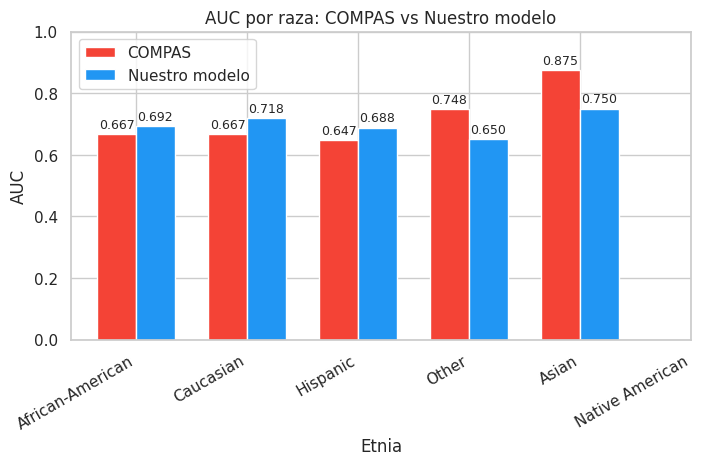

In [ ]:
# AUC por raza de COMPAS vs nuestro modelo
plt.figure(figsize=(8, 4))
bar_width = 0.35
races = auc_comparativa["Etnia"]
x = np.arange(len(races))
plt.bar(x - bar_width/2, auc_comparativa["AUC_COMPAS"], width=bar_width, label="COMPAS", color="#F44336")
plt.bar(x + bar_width/2, auc_comparativa["AUC_NUESTRO"], width=bar_width, label="Nuestro modelo", color="#2196F3")
for i, (compas_auc, nuestro_auc) in enumerate(zip(auc_comparativa["AUC_COMPAS"], auc_comparativa["AUC_NUESTRO"])):
    plt.text(x[i] - bar_width/2, compas_auc + 0.01, f"{compas_auc:.3f}", ha="center", va="bottom", fontsize=9)
    plt.text(x[i] + bar_width/2, nuestro_auc + 0.01, f"{nuestro_auc:.3f}", ha="center", va="bottom", fontsize=9)
plt.xticks(x, races, rotation=30, ha="right")
plt.ylim(0, 1)
plt.xlabel("Etnia")
plt.ylabel("AUC")
plt.title("AUC por raza: COMPAS vs Nuestro modelo")
plt.legend()
plt.show()

Nuestro modelo presenta una capacidad de discriminación general superior a COMPAS (AUC 0.708 vs 0.685), con una mejora de +0.023. Esta mejora se concentra en los grupos más representativos: African-American (+0.025), Caucasian (+0.051) e Hispanic (+0.041). Native American no tiene representación suficiente para calcular AUC.

**Nota:** El rendimiento inferior de nuestro modelo en los grupos Other y Asian
debe interpretarse con cautela por dos razones:
- Primera, los tamaños muestrales en test son muy reducidos (Other: n=68, Asian: n=5), lo que hace que el AUC sea muy sensible a unos pocos casos y estadísticamente inestable.
- Segunda, si estos grupos están igualmente poco representados en el conjunto de entrenamiento, el modelo no habrá aprendido bien sus patrones específicos de reincidencia, lo que puede explicar un rendimiento inferior al de COMPAS, que fue entrenado con un volumen de datos históricamente mayor.

Ambas razones son suposiciones plausibles, no conclusiones verificadas con los datos disponibles

### **AHORA CALCULEMOS EL CALIBRATION**

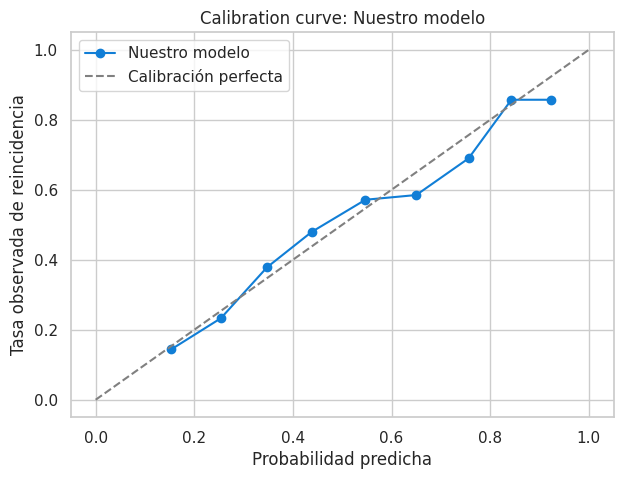

In [ ]:
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba_logreg_test, n_bins=10)
plt.figure(figsize=(7, 5))
plt.plot(prob_pred, prob_true, marker="o", label="Nuestro modelo", color="#117ED6")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Calibración perfecta")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Tasa observada de reincidencia")
plt.title("Calibration curve: Nuestro modelo")
plt.legend()
plt.show()

Esto insinua que nuestro modelo está bien calibrado: las probabilidades predichas se ajustan estrechamente a la diagonal, con ligera inestabilidad solo en el tramo alto. ***Debido a que la calibration curve de nuestro modelo se tiene ruido en la probabilidad más elevada, grafiquemos la distribución de probabilidades predichas por nuestro modelo en el conjunto de test***

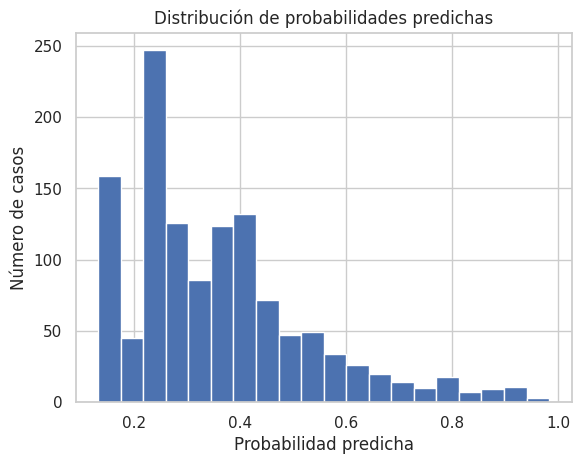

In [ ]:
# Grafico de distribución de probablidades predichas
plt.hist(y_pred_proba_logreg_test, bins=20)
plt.xlabel("Probabilidad predicha")
plt.ylabel("Número de casos")
plt.title("Distribución de probabilidades predichas")
plt.show()

Arriba, podemos ver que la mayoría de los casos se concentran en probabilidades bajas y medias (entre aproximadamente 0.15 y 0.55), con pocos casos por encima de 0.7. Esto explica la mayor inestabilidad de las curvas de calibración de nueustro modelo en el rango alto.

### **Comparemos esta curva de calibration con la de COMPAS**
*Nota: esta comparación es orientativa. COMPAS produce deciles ordinales (1-10), mientras que nuestro modelo produce probabilidades continuas (0-1). Aunque ambos se pueden normalizar a la misma escala, no son conceptualmente equivalentes.*


Cómo hicimos anteriormente con el AUC, para que la comparación sea válida, COMPAS debe evaluarse sobre exactamente los mismos casos que nuestro modelo.

In [ ]:
compas_comparison_calibration = compas_scores_two_years_eval.loc[y_test.index]
tabla_comparison_calibration = (
    compas_comparison_calibration.groupby("decile_score")["two_year_recid"]
      .agg(recuento="count", tasa_observada="mean")
      .reset_index()
      .sort_values("decile_score")
)

tabla_comparison_calibration["pct_tasa_observada"] = (tabla_comparison_calibration["tasa_observada"] * 100).round(2)
tabla_comparison_calibration


,decile_score,recuento,tasa_observada,pct_tasa_observada
0,1,285,0.168421,16.84
1,2,158,0.253165,25.32
2,3,138,0.340580,34.06
3,4,150,0.346667,34.67
4,5,106,0.349057,34.91
5,6,105,0.533333,53.33
6,7,99,0.494949,49.49
7,8,75,0.533333,53.33
8,9,79,0.645570,64.56
9,10,44,0.636364,63.64


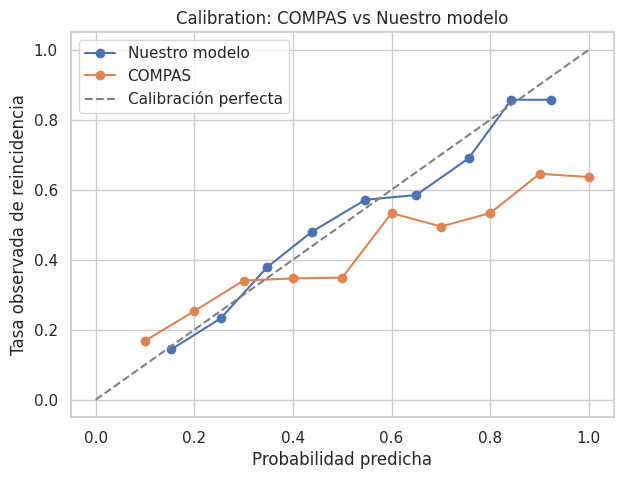

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(prob_pred, prob_true, marker="o", label="Nuestro modelo")
plt.plot(tabla_comparison_calibration["decile_score"] / 10,
         tabla_comparison_calibration["tasa_observada"],
         marker="o", label="COMPAS")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Calibración perfecta")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Tasa observada de reincidencia")
plt.title("Calibration: COMPAS vs Nuestro modelo")
plt.legend()
plt.grid(True)
plt.show()

**Comparación de calibration de COMPAS con nuestro modelo**

- COMPAS subestima sistemáticamente el riesgo a partir de scores medios-altos: la curva se aplana por debajo de la diagonal desde 0.4 en adelante, lo que significa que cuando COMPAS asigna scores altos, la tasa real de reincidencia es menor de lo que el score sugiere.
- Nuestro modelo sigue la diagonal más de cerca en el rango 0.2-0.6, lo que indica mejor calibración en la zona donde se concentra la mayoría de los casos.

### **Comparemos estas curvas de calibration por raza**
*Nota: esta comparación es orientativa. COMPAS produce deciles ordinales (1-10), mientras que nuestro modelo produce probabilidades continuas (0-1). Aunque ambos se pueden normalizar a la misma escala, no son conceptualmente equivalentes.*

In [ ]:
tabla_comparison_calibration_raza = (
    compas_comparison_calibration[compas_comparison_calibration["race"].isin(["African-American", "Caucasian"])]
    .groupby(["race", "decile_score"])["two_year_recid"]
    .agg(recuento="count", tasa_observada="mean")
    .reset_index()
    .sort_values(["race", "decile_score"])
)

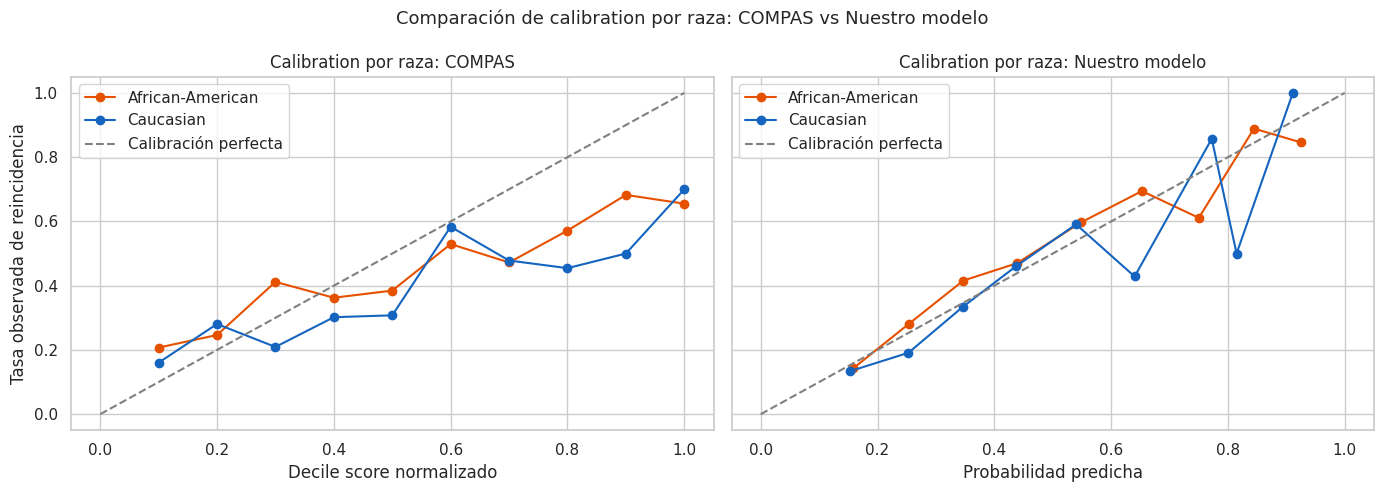

In [ ]:
filtro_raza_tabla_calibration = compas_scores_two_years_eval.loc[y_test.index, "race"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# COMPAS por raza
for raza, color in [("African-American", "#E65100"), ("Caucasian", "#1565C0")]:
    subset = tabla_comparison_calibration_raza[tabla_comparison_calibration_raza["race"] == raza]
    axes[0].plot(subset["decile_score"] / 10, subset["tasa_observada"],
                 marker="o", label=raza, color=color)

axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Calibración perfecta")
axes[0].set_title("Calibration por raza: COMPAS")
axes[0].set_xlabel("Decile score normalizado")
axes[0].set_ylabel("Tasa observada de reincidencia")
axes[0].legend()
axes[0].grid(True)

# Nuestro modelo por raza
for raza, color in [("African-American", "#E65100"), ("Caucasian", "#1565C0")]:
    mask = filtro_raza_tabla_calibration == raza
    prob_true_r, prob_pred_r = calibration_curve(
        y_test[mask], y_pred_proba_logreg_test[mask], n_bins=10
    )
    axes[1].plot(prob_pred_r, prob_true_r, marker="o", label=raza, color=color)

axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Calibración perfecta")
axes[1].set_title("Calibration por raza: Nuestro modelo")
axes[1].set_xlabel("Probabilidad predicha")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Comparación de calibration por raza: COMPAS vs Nuestro modelo", fontsize=13)
plt.tight_layout()
plt.show()

#### ***Comparación de calibration por raza de COMPAS con nuestro modelo***  
- En COMPAS ambos grupos se sitúan por debajo de la diagonal a lo largo de casi todo el rango, lo que indica que el sistema tiende a sobreestimar el riesgo para ambas poblaciones. African-American se sitúa sistemáticamente por encima de Caucasian, lo que sugiere que para un mismo score, los African-American reinciden algo más que los Caucasian, pero ambos por debajo de lo que el score predice.
- Nuestro modelo presenta un comportamiento comparable entre grupos en el rango aproximado de 0.15-0.55, donde se concentra la mayoría de los casos (como pudimos comprobar más arriba). Por encima de 0.6, ambas curvas divergen con alta inestabilidad, lo que refleja el reducido tamaño muestral en ese tramo y no una mala calibración estructural.

En conjunto, ninguno de los dos modelos muestra una diferencia sistemática de calibración entre grupos raciales en el rango donde los datos son suficientes.

---

### **AHORA CALCULEMOS EL RESTO DE MÉTRICAS**

In [ ]:
def obtener_metricas_globales (y_real, y_pred):
  tn, fp, fn, tp = confusion_matrix(y_real, y_pred, labels=[0,1]).ravel()
  return {
      "accuracy": accuracy_score(y_real, y_pred),
  	"precision": precision_score(y_real, y_pred),
  	"recall": recall_score(y_real, y_pred),
    "F1": f1_score(y_real, y_pred)
  }

Cómo hicimos anteriormente con el AUC, para que la comparación sea válida, COMPAS debe evaluarse sobre exactamente los mismos casos que nuestro modelo.

In [ ]:
threshold = 5
compas_test = compas_scores_two_years_eval.loc[y_test.index]

y_recid_cf_test = compas_test["two_year_recid"].astype(int)
y_pred_cf_test = (compas_test["decile_score"] >= threshold).astype(int)

tabla_confusion = confusion_matrix(y_recid_cf_test, y_pred_cf_test, labels=[0, 1])
tn_ct, fp_ct, fn_ct, tp_ct = tabla_confusion.ravel()

print(f"Verdaderos negativos: {tn_ct}")
print(f"Falsos positivos: {fp_ct}")
print(f"Falsos negativos: {fn_ct}")
print(f"Verdaderos positivos: {tp_ct}")

Verdaderos negativos: 544
Falsos positivos: 247
Falsos negativos: 187
Verdaderos positivos: 261


In [ ]:
# Verificamos que ambos coincidan
print(f"Tamaño y_test: {len(y_test)}")
print(f"Tamaño compas_test: {len(compas_test)}")
print(f"Índices coinciden: {y_test.index.equals(compas_test.index)}")

Tamaño y_test: 1239
Tamaño compas_test: 1239
Índices coinciden: True


In [ ]:
metrics_compas_global = obtener_metricas_globales(y_recid_cf_test, y_pred_cf_test)
metrics_nuestro_modelo_global = obtener_metricas_globales(y_test, y_pred_logreg_test)

### ***Evaluemos el accuracy, precision, recall y F1 de ambos modelos***

In [ ]:
df_comparativa_global = pd.DataFrame([metrics_compas_global, metrics_nuestro_modelo_global], index=["COMPAS", "Nuestro modelo"])
print ("RESULTADOS GLOBALES")
display (df_comparativa_global)

RESULTADOS GLOBALES


,accuracy,precision,recall,F1
COMPAS,0.649718,0.513780,0.582589,0.546025
Nuestro modelo,0.685230,0.639423,0.296875,0.405488


Grafiquemos estas métricas globales para comparar ambos modelos

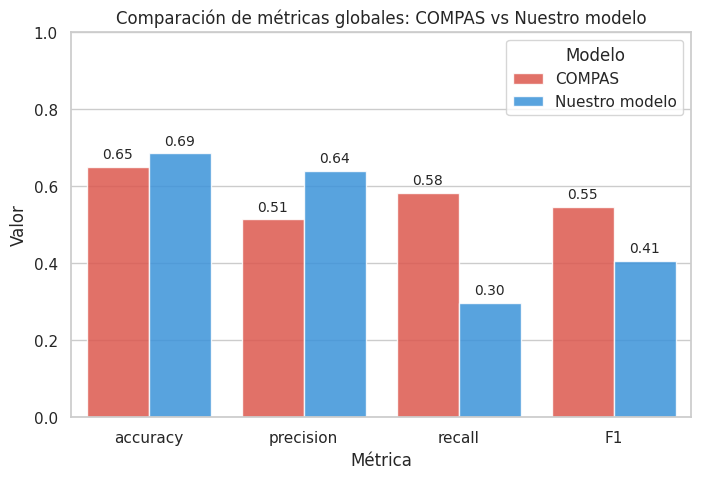

In [ ]:
metricas_globales = ["accuracy", "precision", "recall", "F1"]
df_comparativa_global_graf = df_comparativa_global[metricas_globales].reset_index().melt(id_vars="index", var_name="Métrica", value_name="Valor")
plt.figure(figsize=(8, 5))
sns.barplot(data=df_comparativa_global_graf, x="Métrica", y="Valor", hue="index", palette=["#F44336", "#2196F3"], alpha=0.85, capsize=0.1)
plt.title("Comparación de métricas globales: COMPAS vs Nuestro modelo")
plt.ylim(0, 1)
plt.xlabel("Métrica")
plt.ylabel("Valor")
plt.legend(title="Modelo")
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0.001:
        plt.gca().annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height),
                           ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=10)
plt.show()


### ***Evaluemos el FPR de ambos modelos***

In [ ]:
fpr_global_compas = fp_ct / (fp_ct + tn_ct) if (fp_ct + tn_ct) > 0 else 0
tn_nuestro, fp_nuestro, fn_nuestro, tp_nuestro = confusion_matrix(y_test, y_pred_logreg_test, labels=[0,1]).ravel()
fpr_global_nuestro = fp_nuestro / (fp_nuestro + tn_nuestro) if (fp_nuestro + tn_nuestro) > 0 else 0
df_fpr_global = pd.DataFrame({"Modelo": ["COMPAS", "Nuestro modelo"],"FPR": [fpr_global_compas, fpr_global_nuestro]}).set_index("Modelo")

display(df_fpr_global)

,FPR
Modelo,
COMPAS,0.312263
Nuestro modelo,0.094817


***Grafiquemos el FPR global para comparar ambos modelos***

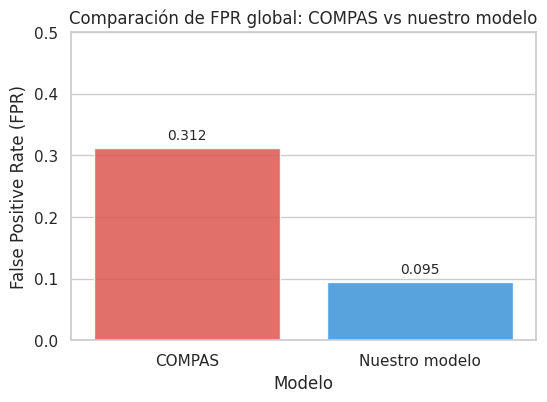

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(x=df_fpr_global.index, y=df_fpr_global["FPR"], palette=["#F44336", "#2196F3"], alpha=0.85, capsize=0.1)
plt.title("Comparación de FPR global: COMPAS vs nuestro modelo")
plt.ylim(0, 0.5)
plt.xlabel("Modelo")
plt.ylabel("False Positive Rate (FPR)")
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0.001:
        plt.gca().annotate(f'{height:.3f}', (p.get_x() + p.get_width() / 2., height),
                           ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=10)
plt.show()

Nuestro modelo supera a COMPAS en accuracy (0.69 vs 0.65) y precision (0.64 vs 0.51): cuando etiqueta a alguien como "de riesgo", acierta más frecuentemente, lo que se traduce en menos personas marcadas injustamente como potenciales reincidentes. Esto se refleja también en el FPR global: nuestro modelo etiqueta erróneamente como "de riesgo" al 9.5% de los no reincidentes, frente al 31.2% de COMPAS.

El recall es inferior (0.30 vs 0.58), lo que refleja una elección de diseño deliberada: al ser más conservador en la clasificación de riesgo, reduce los falsos positivos a costa de detectar menos reincidentes. En un contexto judicial, donde un falso positivo supone penalizar preventivamente a una persona que no reincidiría, esta elección es coherente con el principio de minimizar el daño injustificado.

La métrica que permite comparar ambos modelos sin el efecto del umbral es el AUC, donde nuestro modelo supera a COMPAS (0.708 vs 0.685).

## **Evaluación de métricas globales de equidad por raza**
### ***Evaluemos el FPR por raza de COMPAS y de nuestro modelo***

El FPR (False Positive Rate) mide la proporción de personas que **no reincidieron** pero fueron etiquetadas erróneamente como "de riesgo" por el modelo.

In [ ]:
df_eval_nuestro = pd.DataFrame({"Real": y_test, "Predicción": y_pred_logreg_test, "race": compas_scores_two_years_eval.loc[y_test.index, "race"]})
df_eval_compas = pd.DataFrame({"Real": y_recid_cf_test, "Predicción": y_pred_cf_test, "race": compas_scores_two_years_eval.loc[y_recid_cf_test.index, "race"]})

def calcular_fpr_por_raza(df_filtered):
  resultados = {}
  for raza in ["African-American", "Caucasian"]:
    subset= df_filtered [df_filtered["race"] == raza]
    tn, fp, fn, tp = confusion_matrix (subset ["Real"], subset ["Predicción"], labels=[0,1]).ravel()
    fpr = fp/(fp + tn) if (fp + tn) > 0 else 0
    resultados[raza] = fpr
  return resultados

fpr_compas = calcular_fpr_por_raza(df_eval_compas)
fpr_nuestro_modelo = calcular_fpr_por_raza(df_eval_nuestro)

In [ ]:
# Confirmemos que estos dos dataframes sean comparables
print(f"Tamaño df_eval_nuestro: {len(df_eval_nuestro)}")
print(f"Tamaño df_eval_compas: {len(df_eval_compas)}")
print(f"Índices coinciden: {df_eval_nuestro.index.equals(df_eval_compas.index)}")

Tamaño df_eval_nuestro: 1239
Tamaño df_eval_compas: 1239
Índices coinciden: True


In [ ]:
df_justicia = pd.DataFrame([fpr_compas, fpr_nuestro_modelo], index = ["COMPAS", "Nuestro modelo"])
print ("ANALISIS DE EQUIDAD (FPR)")
display (df_justicia)

ANALISIS DE EQUIDAD (FPR)


,African-American,Caucasian
COMPAS,0.428571,0.221053
Nuestro modelo,0.129121,0.066667


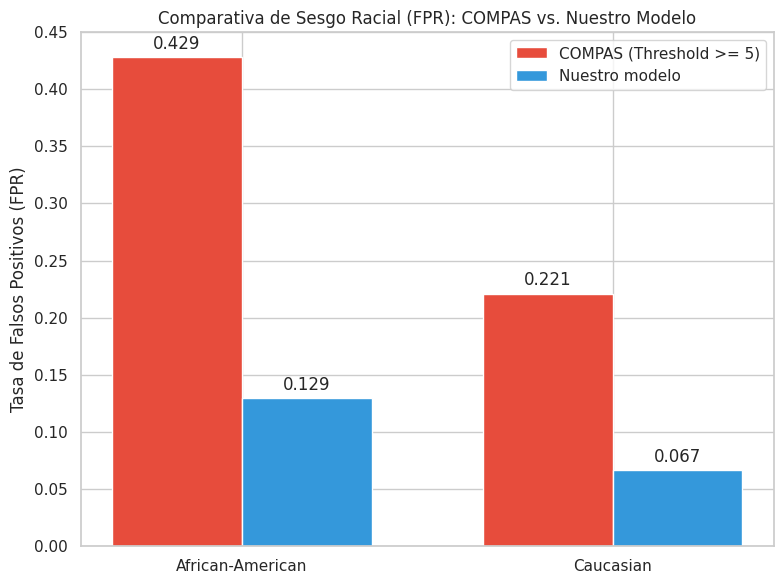

In [ ]:
labels = df_justicia.columns.tolist()

fpr_compas_values = df_justicia.loc["COMPAS"].values
fpr_nuestro_values = df_justicia.loc["Nuestro modelo"].values

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, fpr_compas_values, width, label="COMPAS (Threshold >= 5)", color="#e74c3c")
rects2 = ax.bar(x + width/2, fpr_nuestro_values, width, label="Nuestro modelo", color="#3498db")

ax.set_ylabel('Tasa de Falsos Positivos (FPR)')
ax.set_title('Comparativa de Sesgo Racial (FPR): COMPAS vs. Nuestro Modelo')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
fig.tight_layout()
plt.show()

Nuestro modelo reduce drásticamente el FPR absoluto en ambos grupos: de 0.429 a
0.129 en African-American, y de 0.221 a 0.067 en Caucasian (una reducción del 70% en ambos casos). En términos concretos, COMPAS etiquetaba incorrectamente como "de riesgo" al 42.86% de los acusados African-American que nunca reincidirían; nuestro modelo reduce esa cifra al 12.91%. Para los acusados Caucasian, se repite esta tendencia con una reducción del 22.11% al 6.67%.
Es una mejora muy sustancial en términos de daño absoluto sobre personas concretas.

***Sin embargo, veamos la disparidad relativa entre grupos (es decir, la proporción de FPR entre ambas razas por cada modelo).***

### ***Evaluemos la disparidad racial entre COMPAS y nuestro modelo***

In [ ]:
disparidad_compas = fpr_compas['African-American']/fpr_compas['Caucasian']
disparidad_nuestro_modelo = fpr_nuestro_modelo['African-American']/fpr_nuestro_modelo['Caucasian']
disparidades = pd.DataFrame({
    "Modelo": ["COMPAS", "Nuestro modelo"],
    "Disparidad": [disparidad_compas, disparidad_nuestro_modelo]
})
print("Disparidad entre African-American y Caucasian:")
disparidades

Disparidad entre African-American y Caucasian:


,Modelo,Disparidad
0,COMPAS,1.938776
1,Nuestro modelo,1.936813


Text(0.5, 1.0, 'Disparidad de falsos positivos entre African-American y Caucasian')

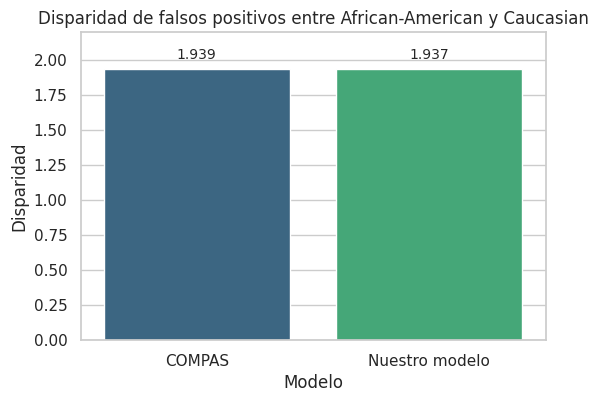

In [ ]:
# Gráfico que muestra la disparidad de falsos positivos entre las dos etnias para ambos modelos
plt.figure(figsize=(6, 4))
sns.barplot(data=disparidades, x="Modelo", y="Disparidad", palette="viridis")
plt.ylim(top=2.2)
for index, row in disparidades.iterrows():
    plt.text(index, row["Disparidad"] + 0.05, f"{row['Disparidad']:.4}", ha='center', va='bottom', fontsize=10)
plt.title("Disparidad de falsos positivos entre African-American y Caucasian")

La disparidad relativa entre grupos es prácticamente idéntica en ambos modelos
(1.939 vs 1.937): un acusado African-American sin reincidencia tiene casi el doble de probabilidad de ser etiquetado como "de riesgo" que uno Caucasian equivalente, independientemente del modelo utilizado. Nuestro modelo reduce el daño absoluto de forma sustancial, pero no resuelve la desigualdad estructural entre grupos.

### ***Extraigamos el resto de las métricas entre African-American y Caucasian para ver cómo se comportan***

In [ ]:
def calcular_metricas_por_raza(df_filtered):
    resultados = {}
    for raza in ["African-American", "Caucasian"]:
        subset = df_filtered[df_filtered["race"] == raza]
        precision = precision_score(subset["Real"], subset["Predicción"])
        recall = recall_score(subset["Real"], subset["Predicción"])
        f1 = f1_score(subset["Real"], subset["Predicción"])
        resultados[raza] = {"precision": precision, "recall": recall, "f1": f1}
    return resultados

metricas_compas_por_raza = calcular_metricas_por_raza(df_eval_compas)
metricas_nuestro_modelo_por_raza = calcular_metricas_por_raza(df_eval_nuestro)


In [ ]:
df_metricas_por_raza = pd.DataFrame({"COMPAS": metricas_compas_por_raza,"Nuestro modelo": metricas_nuestro_modelo_por_raza}).T

# Reorganizamos el dataframe para facilitar la visualización
df_metricas_por_raza = df_metricas_por_raza.apply(lambda x: pd.Series({
    "precision_African-American": x["African-American"]["precision"],
    "recall_African-American": x["African-American"]["recall"],
    "f1_African-American": x["African-American"]["f1"],
    "precision_Caucasian": x["Caucasian"]["precision"],
    "recall_Caucasian": x["Caucasian"]["recall"],
    "f1_Caucasian": x["Caucasian"]["f1"],
}), axis=1)
df_metricas_por_raza

,precision_African-American,recall_African-American,f1_African-American,precision_Caucasian,recall_Caucasian,f1_Caucasian
COMPAS,0.541176,0.669091,0.598374,0.461538,0.465517,0.463519
Nuestro modelo,0.680272,0.363636,0.473934,0.586957,0.232759,0.333333


**Grafiquemos las métricas por raza para ambos modelos**


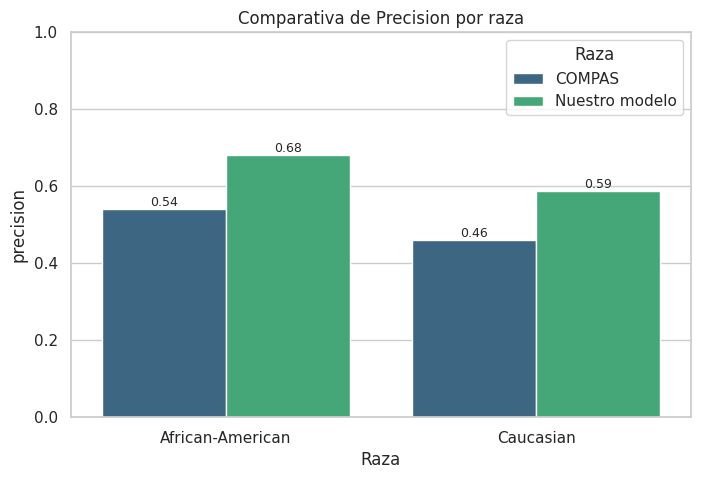

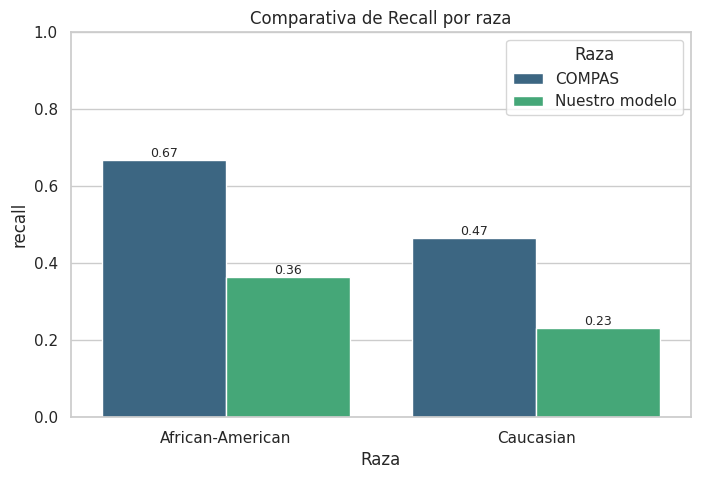

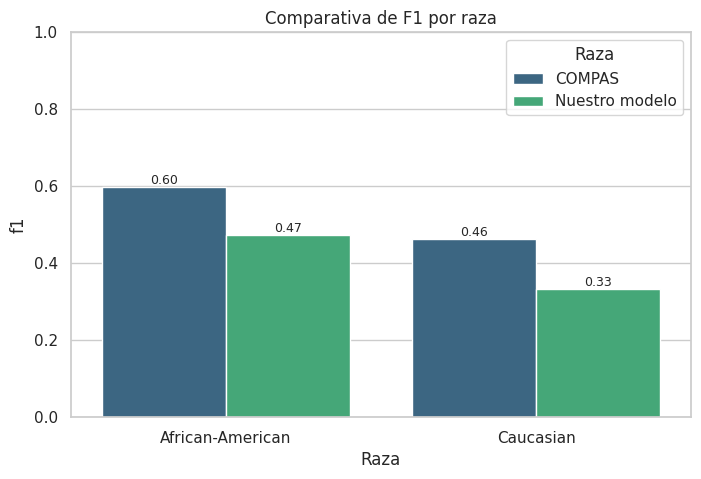

In [ ]:
metrics_to_plot = ["precision", "recall", "f1"]
for metric in metrics_to_plot:
    plt.figure(figsize=(8, 5))
    data_to_plot = df_metricas_por_raza[[f"{metric}_African-American", f"{metric}_Caucasian"]].copy()
    data_to_plot.columns = ["African-American", "Caucasian"]
    data_to_plot["Modelo"] = df_metricas_por_raza.index
    data_to_plot_melted = data_to_plot.melt(id_vars="Modelo", var_name="Raza", value_name=metric)

    sns.barplot(data=data_to_plot_melted, x="Raza", y=metric, hue="Modelo", palette="viridis")
    plt.title(f"Comparativa de {metric.capitalize()} por raza")
    for p in plt.gca().patches:
        height = p.get_height()
        if height > 0:
            plt.gca().annotate(f'{height:.2f}',
                               (p.get_x() + p.get_width() / 2., height),
                               ha='center', va='bottom', fontsize=9)
    plt.ylim(0, 1)
    plt.legend(title="Raza")
    plt.show()

Nuestro modelo mejora la precision en ambos grupos (African-American: 0.68 vs 0.54; Caucasian: 0.59 vs 0.46), a costa de un recall más bajo. Esto es coherente con la elección de diseño: un modelo más conservador que se equivoca menos al acusar, aunque detecte menos reincidentes reales. El F1, que pondera ambas métricas, es inferior al de COMPAS en los dos grupos, lo que refleja precisamente ese intercambio.

### ***Métrica adicional: usemos el Equalized Odds gap***
El Equalized Odds gap mide cuánto difiere el modelo entre African-American y
Caucasian en dos tasas de error:

- **Recall (TPR):** cuántos reincidentes reales detecta correctamente.
- **FPR:** cuántos no reincidentes clasifica erróneamente como reincidentes.

El indicador devuelve la diferencia más desfavorable entre grupos en estas dos
tasas. Cuanto más alto, más desigualmente distribuye el modelo sus errores entre
razas. Cuanto más cercano a cero, más equivalente es el trato entre grupos en
términos de errores predictivos.

In [ ]:
df_eo_compas = df_eval_compas[df_eval_compas["race"].isin(["Caucasian", "African-American"])].copy()
df_eo_nuestro = df_eval_nuestro[df_eval_nuestro["race"].isin(["Caucasian", "African-American"])].copy()

eo_compas = equalized_odds_difference(
    y_true=df_eo_compas["Real"],
    y_pred=df_eo_compas["Predicción"],
    sensitive_features=df_eo_compas["race"]
)

eo_nuestro = equalized_odds_difference(
    y_true=df_eo_nuestro["Real"],
    y_pred=df_eo_nuestro["Predicción"],
    sensitive_features=df_eo_nuestro["race"]
)

print("Equalized Odds gap COMPAS:", eo_compas)
print("Equalized Odds gap Nuestro modelo:", eo_nuestro)


Equalized Odds gap COMPAS: 0.20751879699248119
Equalized Odds gap Nuestro modelo: 0.13087774294670848


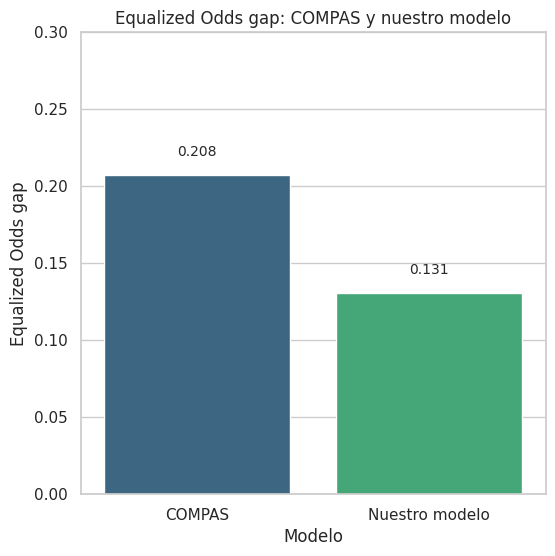

In [ ]:
# Grafico comparativo de Equalized Odds gap entre COMPAS y nuestro modelo
eo_comparativo = pd.DataFrame({
    "Modelo": ["COMPAS", "Nuestro modelo"],
    "Equalized Odds gap": [eo_compas, eo_nuestro]
})
plt.figure(figsize=(6, 6))
sns.barplot(data=eo_comparativo, x="Modelo", y="Equalized Odds gap", palette="viridis")
for index, row in eo_comparativo.iterrows():
    plt.text(index, row["Equalized Odds gap"] + 0.01, f"{row['Equalized Odds gap']:.3f}", ha='center', va='bottom', fontsize=10)
plt.title("Equalized Odds gap: COMPAS y nuestro modelo")
plt.ylim(0, 0.3)
plt.show()

Nuestro modelo reduce el Equalized Odds gap de 0.208 a 0.131, lo que indica que
distribuye sus errores de forma más equitativa entre grupos raciales que COMPAS.
Sin embargo, un gap de 0.131 sigue siendo sustancial: el modelo no trata a ambos
grupos de forma equivalente, solo lo hace menos desigualmente.

# ***CONCLUSIÓN***

Nuestro modelo supera a COMPAS en las métricas globales de rendimiento: accuracy
(0.69 vs 0.65), precision (0.64 vs 0.51) y AUC (0.708 vs 0.685). El AUC es la
comparación más robusta al ser independiente del umbral de clasificación elegido.

El F1 global es inferior en nuestro modelo, consecuencia directa del recall más bajo.

Nuestro modelo mejora la precision en ambos grupos raciales respecto a COMPAS:
- **African-American:** 0.68 vs 0.54 (+0.14)
- **Caucasian:** 0.59 vs 0.46 (+0.13)

El recall es inferior en ambos grupos (African-American: 0.36 vs 0.67; Caucasian: 0.23 vs 0.47), lo que refleja la elección de diseño deliberada de priorizar la reducción de falsos positivos sobre la detección exhaustiva.

En términos de daño absoluto, la reducción del FPR es sustancial: de 42.86% a 12.91% en African-American, y de 22.11% a 6.67% en Caucasian. COMPAS etiquetaba
incorrectamente como "de riesgo" a casi 1 de cada 2 acusados African-American que nunca reincidirían; nuestro modelo reduce esa cifra a poco más de 1 de cada 8.

Sin embargo, la disparidad relativa de FPR entre grupos es prácticamente idéntica en ambos modelos (1.937 vs 1.939): un acusado African-American sin reincidencia tiene casi el doble de probabilidad de ser etiquetado como "de riesgo" que uno Caucasian equivalente, independientemente del modelo utilizado.

Nuestro modelo reduce el Equalized Odds gap de 0.208 a 0.131 (una mejora del 37%), distribuyendo sus errores de forma más equitativa entre razas, aunque un gap de 0.131 sigue siendo sustancial.

En síntesis, nuestro modelo es más preciso y menos dañino en términos absolutos,
pero no elimina la disparidad estructural entre grupos. Representa una mejora en
eficacia y una reducción parcial en inequidad, no una solución al problema de fondo.

## ***Reflexión crítica: implicaciones del uso de modelos predictivos en decisiones judiciales***
Los resultados anteriores permiten una conclusión técnica clara: nuestro modelo
mejora la precision de COMPAS y reduce parcialmente la disparidad en errores entre grupos raciales (demostrado por el equalized Odds gap de 0.208 a 0.131).

Sin embargo, esa mejora no debe interpretarse como una justificación para el uso de este tipo de herramientas en decisiones judiciales.

La disparidad relativa de FPR entre grupos es prácticamente idéntica en ambos
modelos (1.939 vs 1.937): un acusado African-American sin antecedentes de reincidencia tiene casi el doble de probabilidad de ser etiquetado como "de riesgo" que uno Caucasian equivalente, independientemente del modelo utilizado.

La disparidad estructural persiste porque las variables utilizadas (historial de arrestos, delitos juveniles) pueden ser en sí mismas el resultado de un sistema que ha actuado históricamente de forma desigual (como discute Chouldechova, https://arxiv.org/pdf/1610.07524). Cualquier modelo entrenado sobre esos datos hereda esa desigualdad: no existe una solución puramente técnica a un problema fundamentalmente estructural.

La comparación relevante no es entre un modelo sesgado y la ausencia de sesgo, sino entre un modelo sesgado y el juicio humano, que tampoco es neutral. Ya que el juicio humano puede estar también sesgado, el riesgo específico de formalizar estos modelos es que escalan y legitiman el sesgo dándole apariencia de objetividad cuantitativa (como explica Angwin et al., https://www.propublica.org/article/machine-bias-risk-assessments-in-criminal-sentencing). En el caso de herramientas propietarias como COMPAS, impiden que el acusado pueda conocer o impugnar los criterios que determinaron su puntuación (como sugieren Rudin et al., https://arxiv.org/pdf/1811.00731, y Angwin et al., https://www.propublica.org/article/machine-bias-risk-assessments-in-criminal-sentencing).

Más allá de los resultados técnicos, y como posición normativa derivada del análisis, si se acepta algún papel para estas herramientas, debería limitarse a una señal secundaria, auditada públicamente, y siempre subordinada al criterio del juez. El objetivo de reducir la reincidencia no puede alcanzarse a costa de sistematizar la injusticia hacia los grupos más vulnerables del sistema.